# Loan Approval Prediction — Exploratory Data Analysis, Data Cleaning, Transformation, Statistical Analysis & Visualization

**Capstone Project 1 — Data Science**

**Dataset:** `Loan Application Accept or Reject.csv`
**Client scenario:** ABC Bank — loan application screening
**Notebook:** `Loan_Approval_EDA.ipynb`

---

## 01. Project Overview

### What this project is

ABC Bank processes thousands of loan applications. Each application carries financial and
demographic information — income, requested loan amount, loan term, credit bureau score,
and the value of assets the applicant owns. The bank eventually wants an AI/ML system that
scores an incoming application before a human officer commits to a decision.

This notebook is the step that comes **before** any model is built. It answers a
deceptively simple question:

> *Do we actually understand and trust this data well enough to model it?*

### What the dataset represents

Each row is one loan application. The file records applicant attributes captured at
application time and the final decision recorded by the bank (`loan_status`). We treat the
CSV as the single source of truth and derive every statement in this notebook from it.

### Why loan approval analysis matters

Lending decisions are high-impact and asymmetric. A wrongly rejected creditworthy applicant
loses access to capital and the bank loses revenue; a wrongly approved applicant may default,
creating a credit loss and, at portfolio scale, a solvency risk. Because the decision affects
people's financial lives, it also falls under fair-lending scrutiny in most jurisdictions.
That makes the *quality of the underlying data* a governance concern, not just a technical one.

### Why EDA is necessary

A model trained on unexamined data inherits every defect in that data silently. Missing
values, sentinel codes masquerading as real numbers, duplicated records, inconsistent
category spellings and leaked post-decision fields all produce models that look excellent
in validation and fail in production. EDA is the control that catches these before they
become expensive.

### Why data quality matters

Every downstream number — a mean, a correlation, a model coefficient — is only as
trustworthy as the rows that produced it. One constant sentinel value in a financial column
can shift a mean, distort a correlation and mislead a business recommendation.

### Why visualization matters

Summary statistics compress; plots reveal. A correlation coefficient can be near zero while
a scatter plot shows a sharp threshold relationship. In this dataset that is not a
hypothetical — it is exactly what we find.

### How this relates to future ML

The output of this notebook is a documented, validated dataset plus an explicit preprocessing
strategy, a leakage assessment and a feature shortlist. That is the input a modelling
notebook needs.

---

> **Scope statement**
>
> This notebook focuses on data understanding, data cleaning, transformation, exploratory
> analysis, statistical reasoning, visualization, and ML readiness. **Model training is
> intentionally outside the scope of this notebook.** No `scikit-learn` or other
> machine-learning library is used anywhere.

## 02. Business Problem

### The ABC Bank scenario

ABC Bank wants to build an AI/ML system that analyzes a loan application against financial
and applicant parameters *before* granting a loan to an individual or organization. Today
that assessment is made by underwriters applying policy rules and judgement. The bank's goal
is to make that process faster, more consistent, and more auditable.

### Why each parameter matters to the decision

| Parameter | Why an underwriter cares |
|---|---|
| **Credit / CIBIL score** | A bureau score summarising repayment history across all lenders. It is the single most standardised measure of past credit behaviour available at application time. |
| **Applicant income** | Establishes capacity to service the debt. Capacity is distinct from willingness — the bureau score speaks to willingness, income speaks to capacity. |
| **Employment status (self-employed vs salaried)** | Salaried income is typically easier to verify and more stable month to month; self-employed income is often lumpier. It is an income *reliability* signal, not an income *level* signal. |
| **Loan amount** | The absolute exposure the bank takes on. |
| **Loan term** | Sets the repayment schedule. A short term means larger periodic payments; a long term means longer exposure to the applicant's changing circumstances. |
| **Asset values** (residential, commercial, luxury, bank) | Collateral and financial cushion. Assets can secure the loan and indicate resilience to income shocks. |
| **Education / dependents** | Context on household circumstances and earning trajectory. These are also the variables most likely to raise fairness questions. |
| **Approval status** | The recorded outcome — our target. |

### What a model could, and could not, do here

A model trained on this data could rank incoming applications by their similarity to
previously approved ones, flag borderline cases for closer review, and make the bank's
existing decision criteria explicit and auditable.

It **should not replace human decision-making.** A model trained on historical decisions
learns the historical *policy*, including any bias in it. It has no access to information the
underwriter gathered outside the file, and it cannot be accountable for an adverse decision.
The appropriate role is decision *support* with human oversight, especially near the
decision boundary.

## 03. Project Objective

1. Understand the dataset — what it contains and what each column means.
2. Identify numerical and categorical features.
3. Identify the target variable from evidence, not assumption.
4. Assess data quality and establish a measurable baseline.
5. Handle missing values appropriately, per column, with justification.
6. Detect and investigate duplicates — exact rows *and* repeated identifiers.
7. Identify invalid values that violate domain plausibility.
8. Clean categorical variables before any encoding.
9. Encode categorical features appropriately for their measurement scale.
10. Detect and investigate outliers using multiple methods.
11. Treat outliers only where the evidence justifies it.
12. Analyze distributions and skewness.
13. Perform statistical analysis, including robust statistics and resampling-based tests.
14. Engineer meaningful features grounded in lending domain logic.
15. Demonstrate binning and analyze approval rate by bin.
16. Demonstrate normalization and standardization, implemented manually.
17. Perform univariate, bivariate and multivariate EDA.
18. Create all required visualization types, each answering a stated question.
19. Answer the specified business questions from actual results.
20. Summarize insights as a coherent narrative.
21. Assess readiness for future ML modelling, including leakage and fairness.

## 04. Analytical Philosophy

Every transformation in this notebook passes through the same six gates:

```
        DETECT   ->  Measure the issue. Do not assume it exists.
    INVESTIGATE  ->  Look at the actual rows. Ask what could produce this.
         DECIDE  ->  Choose a treatment, and name the alternative rejected.
      TRANSFORM  ->  Apply it to a copy, never to the raw data.
       VALIDATE  ->  Re-measure. Confirm the issue is gone and nothing else broke.
       DOCUMENT  ->  Record problem, evidence, decision, reason, impact.
```

Chained to the business, the full loop is:

```
BUSINESS QUESTION -> DATA QUESTION -> DETECT -> INVESTIGATE -> DECIDE
   -> TRANSFORM -> VALIDATE -> VISUALIZE -> INTERPRET -> BUSINESS INSIGHT
```

> **Data cleaning is not about removing everything unusual.
> It is about distinguishing data problems from legitimate variation.**

A ₹3.9 crore luxury asset value is statistically extreme. It is also entirely possible.
Deleting it because a formula flagged it would destroy real information about a real
segment of ABC Bank's applicants.

For every important transformation this notebook answers:

1. **What** are we doing?
2. **Why** are we doing it?
3. **How** are we doing it?
4. **What evidence** supports the decision?
5. **What assumptions** are being made?
6. **What risks** does it carry?
7. **How did we validate** the result?

### The goal

The goal is **not** "make the dataset perfect." The goal is:

> Make the dataset **reliable, interpretable, analytically useful, and suitable for future
> ML work, while preserving valid information.**

## 05. Import Libraries

Only the libraries permitted for this project are imported. No `scikit-learn`, no `scipy`,
no other machine-learning or statistical-modelling package is used anywhere in this notebook.
Where a statistical test is needed, it is implemented from first principles with NumPy
(see Section 34).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statistics

%matplotlib inline

# Reproducibility: used by the resampling tests and by the clearly-labelled
# synthetic demonstration datasets. No real data is randomly generated.
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Display settings - show full column names and avoid scientific notation on
# rupee amounts, which are large but perfectly readable as integers.
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

# A single consistent visual style for the whole notebook.
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11

# Two fixed colours reused for the target throughout, so that "green = approved"
# never has to be re-learned by the reader.
COLOR_APPROVED = "#2E7D32"
COLOR_REJECTED = "#C62828"
TARGET_PALETTE = {"Approved": COLOR_APPROVED, "Rejected": COLOR_REJECTED}

print("numpy      :", np.__version__)
print("pandas     :", pd.__version__)
print("matplotlib :", plt.matplotlib.__version__)
print("seaborn    :", sns.__version__)
print("random seed:", RANDOM_SEED)

numpy      : 2.3.5
pandas     : 2.3.3
matplotlib : 3.10.6
seaborn    : 0.13.2
random seed: 42


## 06. Load Dataset

### Why are we doing this?

Everything downstream depends on reading the file correctly. A silent parsing problem —
a wrong delimiter, a header row treated as data, a numeric column read as text — would
invalidate every subsequent number.

### Why preserve the raw data?

`df_raw` is loaded once and **never modified**. All work happens on copies. This gives us
three things:

1. **Auditability** — at any point we can compare the working data against the original and
   state exactly what changed.
2. **Reversibility** — a cleaning decision that turns out to be wrong can be revised without
   re-running from the file.
3. **Honesty** — the "before vs after" table in Section 38 is computed, not remembered.

In [2]:
CSV_PATH = "Loan Application Accept or Reject.csv"

df_raw = pd.read_csv(CSV_PATH)

# The working copy. df_raw is treated as read-only for the rest of the notebook.
df = df_raw.copy()

print(f"Loaded '{CSV_PATH}'")
print(f"Rows    : {df_raw.shape[0]:,}")
print(f"Columns : {df_raw.shape[1]}")

Loaded 'Loan Application Accept or Reject.csv'
Rows    : 4,269
Columns : 13


In [3]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,"9,600,000.0000","29,900,000.0000",12,778,"2,400,000.0000","17,600,000.0000","22,700,000.0000","8,000,000.0000",Approved
1,2,0,Not Graduate,Yes,"4,100,000.0000","12,200,000.0000",8,417,"2,700,000.0000","2,200,000.0000","8,800,000.0000","3,300,000.0000",Rejected
2,3,3,Graduate,No,"9,100,000.0000","29,700,000.0000",20,506,"7,100,000.0000","4,500,000.0000","33,300,000.0000","12,800,000.0000",Rejected
3,4,3,Graduate,No,"8,200,000.0000","30,700,000.0000",8,467,"18,200,000.0000","3,300,000.0000","23,300,000.0000","7,900,000.0000",Rejected
4,5,5,Not Graduate,Yes,"9,800,000.0000","24,200,000.0000",20,382,"12,400,000.0000","8,200,000.0000","29,400,000.0000","5,000,000.0000",Rejected


In [4]:
df.tail()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
4264,4265,5,Graduate,Yes,"1,000,000.0000","2,300,000.0000",12,317,"2,800,000.0000","500,000.0000","3,300,000.0000","800,000.0000",Rejected
4265,4266,0,Not Graduate,Yes,"3,300,000.0000","11,300,000.0000",20,559,"4,200,000.0000","2,900,000.0000","11,000,000.0000","1,900,000.0000",Approved
4266,4267,2,Not Graduate,No,"6,500,000.0000","23,900,000.0000",18,457,"1,200,000.0000","12,400,000.0000","18,100,000.0000","7,300,000.0000",Rejected
4267,4268,1,Not Graduate,No,"4,100,000.0000","12,800,000.0000",8,780,"8,200,000.0000","700,000.0000","14,100,000.0000","5,800,000.0000",Approved
4268,4269,1,Graduate,No,"9,200,000.0000","29,700,000.0000",10,607,"17,800,000.0000","11,800,000.0000","35,700,000.0000","12,000,000.0000",Approved


In [5]:
print("Shape:", df.shape)
print("\nColumn names as stored in the file (repr shows hidden whitespace):")
for i, c in enumerate(df.columns, start=1):
    print(f"  {i:>2}. {c!r}")

Shape: (4269, 13)

Column names as stored in the file (repr shows hidden whitespace):
   1. 'loan_id'
   2. ' no_of_dependents'
   3. ' education'
   4. ' self_employed'
   5. ' income_annum'
   6. ' loan_amount'
   7. ' loan_term'
   8. ' cibil_score'
   9. ' residential_assets_value'
  10. ' commercial_assets_value'
  11. ' luxury_assets_value'
  12. ' bank_asset_value'
  13. ' loan_status'


### Result — first data-quality signal, before any analysis

Printing the column names with `repr()` rather than plain `print` immediately surfaces
something a casual `df.columns` would hide: **every column except the first carries a leading
space** (`' education'`, not `'education'`).

This is a real defect, not a cosmetic one — `df["education"]` would raise a `KeyError`.
We **record it now and fix it in Section 14** (Column Name Standardization) rather than
patching it silently here, because the notebook's structure is Detect → Investigate →
Decide → Transform, and because the before/after comparison in Section 14 is part of the
evidence trail.

Until Section 14, code accesses columns **programmatically** (by position, by dtype, or by
iterating `df.columns`) rather than by hard-coded string literals. That is why the next
several sections use loops instead of names.

In [6]:
df.dtypes

loan_id                        int64
 no_of_dependents              int64
 education                    object
 self_employed                object
 income_annum                float64
 loan_amount                 float64
 loan_term                     int64
 cibil_score                   int64
 residential_assets_value    float64
 commercial_assets_value     float64
 luxury_assets_value         float64
 bank_asset_value            float64
 loan_status                  object
dtype: object

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   loan_id                    4269 non-null   int64  
 1    no_of_dependents          4269 non-null   int64  
 2    education                 4267 non-null   object 
 3    self_employed             4269 non-null   object 
 4    income_annum              4267 non-null   float64
 5    loan_amount               4268 non-null   float64
 6    loan_term                 4269 non-null   int64  
 7    cibil_score               4269 non-null   int64  
 8    residential_assets_value  4267 non-null   float64
 9    commercial_assets_value   4267 non-null   float64
 10   luxury_assets_value       4268 non-null   float64
 11   bank_asset_value          4268 non-null   float64
 12   loan_status               4269 non-null   object 
dtypes: float64(6), int64(4), object(3)
memory usage:

In [8]:
# Numeric summary. Interpretation follows in Section 07.
df.describe().T

,count,mean,std,min,25%,50%,75%,max
loan_id,"4,269.0000","2,135.0000","1,232.4985",1.0000,"1,068.0000","2,135.0000","3,202.0000","4,269.0000"
no_of_dependents,"4,269.0000",2.4987,1.6959,0.0000,1.0000,3.0000,4.0000,5.0000
income_annum,"4,267.0000","5,059,011.0148","2,807,304.9938","200,000.0000","2,650,000.0000","5,100,000.0000","7,500,000.0000","9,900,000.0000"
loan_amount,"4,268.0000","15,132,122.7741","9,044,006.4919","300,000.0000","7,700,000.0000","14,500,000.0000","21,500,000.0000","39,500,000.0000"
loan_term,"4,269.0000",10.9004,5.7092,2.0000,6.0000,10.0000,16.0000,20.0000
cibil_score,"4,269.0000",599.9361,172.4304,300.0000,453.0000,600.0000,748.0000,900.0000
residential_assets_value,"4,267.0000","7,473,166.1589","6,505,075.3298","-100,000.0000","2,200,000.0000","5,600,000.0000","11,300,000.0000","29,100,000.0000"
commercial_assets_value,"4,267.0000","4,974,033.2787","4,389,418.0516",0.0000,"1,300,000.0000","3,700,000.0000","7,600,000.0000","19,400,000.0000"
luxury_assets_value,"4,268.0000","15,127,272.7273","9,104,601.1831","300,000.0000","7,500,000.0000","14,600,000.0000","21,700,000.0000","39,200,000.0000"
bank_asset_value,"4,268.0000","4,977,553.8894","3,250,078.6766",0.0000,"2,300,000.0000","4,600,000.0000","7,100,000.0000","14,700,000.0000"


In [9]:
# include="all" adds the categorical columns: count, unique, top, freq.
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
loan_id,"4,269.0000",NaN,NaN,NaN,"2,135.0000","1,232.4985",1.0000,"1,068.0000","2,135.0000","3,202.0000","4,269.0000"
no_of_dependents,"4,269.0000",NaN,NaN,NaN,2.4987,1.6959,0.0000,1.0000,3.0000,4.0000,5.0000
education,4267,2,Graduate,2143,NaN,NaN,NaN,NaN,NaN,NaN,NaN
self_employed,4269,2,Yes,2150,NaN,NaN,NaN,NaN,NaN,NaN,NaN
income_annum,"4,267.0000",NaN,NaN,NaN,"5,059,011.0148","2,807,304.9938","200,000.0000","2,650,000.0000","5,100,000.0000","7,500,000.0000","9,900,000.0000"
loan_amount,"4,268.0000",NaN,NaN,NaN,"15,132,122.7741","9,044,006.4919","300,000.0000","7,700,000.0000","14,500,000.0000","21,500,000.0000","39,500,000.0000"
loan_term,"4,269.0000",NaN,NaN,NaN,10.9004,5.7092,2.0000,6.0000,10.0000,16.0000,20.0000
cibil_score,"4,269.0000",NaN,NaN,NaN,599.9361,172.4304,300.0000,453.0000,600.0000,748.0000,900.0000
residential_assets_value,"4,267.0000",NaN,NaN,NaN,"7,473,166.1589","6,505,075.3298","-100,000.0000","2,200,000.0000","5,600,000.0000","11,300,000.0000","29,100,000.0000"
commercial_assets_value,"4,267.0000",NaN,NaN,NaN,"4,974,033.2787","4,389,418.0516",0.0000,"1,300,000.0000","3,700,000.0000","7,600,000.0000","19,400,000.0000"


## 07. Initial Data Inspection

### Why are we doing this?

Before deciding anything we need an inventory: how many rows, how many columns, which
columns are numeric, which are categorical, which looks like an identifier, and — critically —
which column is the **target**. The target is not given to us; it must be argued for.

### What are we checking?

- Row and column counts.
- The dtype of each column, and whether that dtype is *appropriate* for its content.
- Cardinality (number of distinct values) — the main clue separating identifiers,
  categoricals, discrete numerics and continuous numerics.

### Approach

Classify columns by dtype and cardinality, then reason about each group against the business
context from Section 02.

In [10]:
n_rows, n_cols = df.shape

numeric_cols_initial = df.select_dtypes(include=np.number).columns.tolist()
object_cols_initial  = df.select_dtypes(include="object").columns.tolist()
bool_cols_initial    = df.select_dtypes(include="bool").columns.tolist()

print(f"Rows                       : {n_rows:,}")
print(f"Columns                    : {n_cols}")
print(f"Numeric-dtype columns      : {len(numeric_cols_initial)}")
print(f"Object (text) columns      : {len(object_cols_initial)}")
print(f"Boolean-dtype columns      : {len(bool_cols_initial)}")

print("\nNumeric :", [c.strip() for c in numeric_cols_initial])
print("Object  :", [c.strip() for c in object_cols_initial])
print("Boolean :", [c.strip() for c in bool_cols_initial] or "none present")

Rows                       : 4,269
Columns                    : 13
Numeric-dtype columns      : 10
Object (text) columns      : 3
Boolean-dtype columns      : 0

Numeric : ['loan_id', 'no_of_dependents', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']
Object  : ['education', 'self_employed', 'loan_status']
Boolean : none present


In [11]:
# Cardinality profile - the main tool for separating identifiers from features.
card = pd.DataFrame({
    "column"       : [c.strip() for c in df.columns],
    "dtype"        : [str(df[c].dtype) for c in df.columns],
    "n_unique"     : [df[c].nunique(dropna=True) for c in df.columns],
    "unique_ratio" : [df[c].nunique(dropna=True) / len(df) for c in df.columns],
    "example_values": [
        ", ".join(map(str, df[c].dropna().unique()[:4])) for c in df.columns
    ],
})
card["unique_ratio"] = card["unique_ratio"].round(4)
card

,column,dtype,n_unique,unique_ratio,example_values
0,loan_id,int64,4269,1.0000,"1, 2, 3, 4"
1,no_of_dependents,int64,6,0.0014,"2, 0, 3, 5"
2,education,object,2,0.0005,"Graduate, Not Graduate"
3,self_employed,object,2,0.0005,"No, Yes"
4,income_annum,float64,98,0.0230,"9600000.0, 4100000.0, 9100000.0, 8200000.0"
5,loan_amount,float64,378,0.0885,"29900000.0, 12200000.0, 29700000.0, 30700000.0"
6,loan_term,int64,10,0.0023,"12, 8, 20, 10"
7,cibil_score,int64,601,0.1408,"778, 417, 506, 467"
8,residential_assets_value,float64,278,0.0651,"2400000.0, 2700000.0, 7100000.0, 18200000.0"
9,commercial_assets_value,float64,188,0.0440,"17600000.0, 2200000.0, 4500000.0, 3300000.0"


In [12]:
# Distinct values for every low-cardinality column - these are the candidate
# categoricals and the candidate target.
LOW_CARD_LIMIT = 12
for c in df.columns:
    nu = df[c].nunique(dropna=True)
    if nu <= LOW_CARD_LIMIT:
        print(f"{c.strip():<28} ({nu} distinct)")
        vc = df[c].value_counts(dropna=False)
        for val, cnt in vc.items():
            print(f"      {str(val)!r:<20} {cnt:>6,}  ({cnt/len(df)*100:5.2f}%)")
        print()

no_of_dependents             (6 distinct)
      '4'                     752  (17.62%)
      '3'                     727  (17.03%)
      '0'                     712  (16.68%)
      '2'                     708  (16.58%)
      '1'                     697  (16.33%)
      '5'                     673  (15.76%)

education                    (2 distinct)
      ' Graduate'           2,143  (50.20%)
      ' Not Graduate'       2,124  (49.75%)
      'nan'                     2  ( 0.05%)

self_employed                (2 distinct)
      ' Yes'                2,150  (50.36%)
      ' No'                 2,119  (49.64%)

loan_term                    (10 distinct)
      '6'                     490  (11.48%)
      '12'                    456  (10.68%)
      '4'                     447  (10.47%)
      '10'                    436  (10.21%)
      '18'                    422  ( 9.89%)
      '16'                    412  ( 9.65%)
      '20'                    411  ( 9.63%)
      '14'                    405  (

### Result

**Shape.** 4,269 rows × 13 columns. Every row is one loan application.

**Column roles, argued from the evidence above:**

- **`loan_id`** — integer, `unique_ratio` = 1.0000, i.e. one distinct value per row, running
  1…4269. Perfectly unique sequential integers with no repeats is the signature of a
  **row identifier**, not a feature. Investigated formally in Section 19.

- **`education`, `self_employed`, `loan_status`** — object dtype, 2 distinct values each.
  These are **categorical**. Their stored values (`' Graduate'`, `' No'`, `' Approved'`)
  carry the same leading whitespace as the column names — a second manifestation of the same
  export defect. Cleaned in Section 17.

- **`no_of_dependents`** (6 distinct: 0–5) and **`loan_term`** (10 distinct: 2, 4, …, 20) —
  numeric dtype but **discrete**. They are numeric *and* meaningfully ordered, so we keep
  them numeric, while remembering that a "mean number of dependents" of 2.5 describes no
  actual household.

- **`cibil_score`** — integer, wide range. Continuous-in-practice numeric feature.

- **`income_annum`, `loan_amount`, `residential_assets_value`, `commercial_assets_value`,
  `luxury_assets_value`, `bank_asset_value`** — float, high cardinality, large rupee
  magnitudes. Continuous **numerical features**. They are float rather than int *only*
  because each contains at least one missing value, which forces float in pandas — that is
  itself a missingness signal, confirmed in Section 11.

### Which column is the target?

**`loan_status`** is the target. The reasoning, in the order it should be made:

1. **Business meaning.** Section 02 states the business goal: predict whether an application
   is approved. `loan_status` is the only column that records a decision outcome.
2. **Value semantics.** Its two values are literally `Approved` and `Rejected` — the decision
   itself, not a driver of it.
3. **Cardinality and type.** Two mutually exclusive labels covering 100% of rows: a clean
   binary classification target.
4. **Elimination.** Every other column describes the applicant or the requested facility
   *at application time*. None of them encodes an outcome.

We deliberately do **not** simply take the last column as the target — it happens to be last
here, but position is not evidence. Formal confirmation, label standardisation and
distribution follow in Sections 20–21.

### Decision

Proceed with `loan_status` as the target, `loan_id` as an identifier under investigation,
and the remaining 11 columns as candidate features.

## 08. Dataset Structure

### Why are we doing this?

The inspection above is spread across several outputs. A single profiling table gives us one
artefact we can point at, reuse, and hand to a reviewer.

### Approach

Build a function that profiles any dataframe and assigns each column a **role**. Making it a
function rather than a one-off block means we can re-run it after cleaning (Section 46) and
compare like with like.

In [13]:
def profile_dataframe(frame, target=None, id_cols=None, low_card_limit=12):
    '''Return a per-column profile with an inferred analytical role.

    Roles are heuristics stated in code so the reasoning is inspectable and
    reproducible, not asserted in prose.
    '''
    id_cols = set(id_cols or [])
    rows = []
    for c in frame.columns:
        s = frame[c]
        n_missing = int(s.isna().sum())
        n_unique = int(s.nunique(dropna=True))
        unique_ratio = n_unique / len(frame) if len(frame) else np.nan

        if c == target:
            role = "Target"
        elif c in id_cols or (pd.api.types.is_integer_dtype(s) and unique_ratio > 0.99):
            role = "Identifier"
        elif s.dtype == object or n_unique <= 2:
            role = "Categorical feature"
        elif pd.api.types.is_numeric_dtype(s) and n_unique <= low_card_limit:
            role = "Discrete numerical feature"
        elif pd.api.types.is_numeric_dtype(s):
            role = "Numerical feature"
        else:
            role = "Unknown / needs investigation"

        notes = []
        if isinstance(c, str) and c != c.strip():
            notes.append("column name has surrounding whitespace")
        if n_missing:
            notes.append(f"{n_missing} missing")
        if pd.api.types.is_numeric_dtype(s) and (s.dropna() < 0).any():
            notes.append("contains negative values")
        if s.dtype == object:
            stripped_differs = (s.dropna().astype(str) != s.dropna().astype(str).str.strip()).any()
            if stripped_differs:
                notes.append("category values have surrounding whitespace")

        rows.append({
            "Column"       : c.strip() if isinstance(c, str) else c,
            "Data Type"    : str(s.dtype),
            "Missing"      : n_missing,
            "Missing %"    : round(n_missing / len(frame) * 100, 3) if len(frame) else np.nan,
            "Unique Values": n_unique,
            "Role"         : role,
            "Notes"        : "; ".join(notes) if notes else "-",
        })
    return pd.DataFrame(rows)


TARGET_RAW = [c for c in df.columns if c.strip() == "loan_status"][0]
ID_RAW     = [c for c in df.columns if c.strip() == "loan_id"][0]

structure_before = profile_dataframe(df, target=TARGET_RAW, id_cols=[ID_RAW])
structure_before

,Column,Data Type,Missing,Missing %,Unique Values,Role,Notes
0,loan_id,int64,0,0.0000,4269,Identifier,-
1,no_of_dependents,int64,0,0.0000,6,Discrete numerical feature,column name has surrounding whitespace
2,education,object,2,0.0470,2,Categorical feature,column name has surrounding whitespace; 2 miss...
3,self_employed,object,0,0.0000,2,Categorical feature,column name has surrounding whitespace; catego...
4,income_annum,float64,2,0.0470,98,Numerical feature,column name has surrounding whitespace; 2 missing
5,loan_amount,float64,1,0.0230,378,Numerical feature,column name has surrounding whitespace; 1 missing
6,loan_term,int64,0,0.0000,10,Discrete numerical feature,column name has surrounding whitespace
7,cibil_score,int64,0,0.0000,601,Numerical feature,column name has surrounding whitespace
8,residential_assets_value,float64,2,0.0470,278,Numerical feature,column name has surrounding whitespace; 2 miss...
9,commercial_assets_value,float64,2,0.0470,188,Numerical feature,column name has surrounding whitespace; 2 missing


### Interpretation

The profile confirms and adds to Section 07:

- One **Target** (`loan_status`), one **Identifier** (`loan_id`), eleven **features**.
- **Ten columns carry the whitespace defect** in their names; three categorical columns carry
  it in their *values* as well.
- **Seven columns contain missing values**, all in single digits.
- **`residential_assets_value` contains negative values** — the only column that does. An
  asset value cannot be negative, so this is flagged as a domain violation and investigated
  in Section 16.

No column is left as "Unknown / needs investigation", so we can proceed to the data dictionary.

## 09. Feature / Data Dictionary

No external documentation ships with this dataset. Every meaning below is therefore inferred
from the column name together with the observed values and the lending context of Section 02,
and is labelled as such. **Nothing here is invented beyond what the data supports.**

| # | Feature | Data Type | Meaning | Measurement scale | Role | Why it might matter |
|---|---|---|---|---|---|---|
| 1 | `loan_id` | int64 | Sequential application reference, 1…4269. *Meaning inferred from column name and observed values.* | Nominal (identifier) | Identifier | Traceability only. Carries no information about the applicant — see Section 19. |
| 2 | `no_of_dependents` | int64 | Number of financial dependents in the household, observed 0–5. *Inferred from name and values.* | Discrete numeric (ratio) | Feature | More dependents means more of the income is already committed, reducing free cash flow for repayment. |
| 3 | `education` | object | Whether the applicant is a graduate. Values `Graduate` / `Not Graduate`. *Inferred from name and values.* | Binary nominal (arguably ordinal) | Feature | Proxy for earning trajectory. **Also a fairness-sensitive proxy** — see Section 41. |
| 4 | `self_employed` | object | Whether the applicant is self-employed. Values `Yes` / `No`. *Inferred from name and values.* | Binary nominal | Feature | Income *verifiability and stability* signal, distinct from income level. |
| 5 | `income_annum` | float64 | Annual income of the applicant, in rupees. *Inferred from name, magnitude and range.* | Continuous (ratio) | Feature | Core repayment-capacity measure. |
| 6 | `loan_amount` | float64 | Loan amount requested, in rupees. *Inferred from name and magnitude.* | Continuous (ratio) | Feature | The bank's exposure. Meaningful mainly *relative to* income and assets. |
| 7 | `loan_term` | int64 | Loan term. Observed as even integers 2–20; the unit is not documented, and the values are consistent with **years**. *Unit inferred, not documented — treated as an ordered numeric.* | Discrete numeric (ratio) | Feature | Determines instalment size and the duration of the bank's exposure. |
| 8 | `cibil_score` | int64 | Credit bureau (CIBIL) score. Observed range 300–900, which matches the published CIBIL scale exactly. *Meaning inferred from name and confirmed by the observed range.* | Continuous (interval) | Feature | The standard summary of past repayment behaviour. Expected to be strongly related to approval. |
| 9 | `residential_assets_value` | float64 | Value of residential property owned, in rupees. *Inferred from name and magnitude.* | Continuous (ratio) | Feature | Collateral and financial cushion. |
| 10 | `commercial_assets_value` | float64 | Value of commercial property owned, in rupees. *Inferred from name and magnitude.* | Continuous (ratio) | Feature | Collateral; may also indicate business ownership. |
| 11 | `luxury_assets_value` | float64 | Value of luxury assets owned, in rupees. *Inferred from name and magnitude.* | Continuous (ratio) | Feature | Wealth indicator; typically less readily liquidated than financial assets. |
| 12 | `bank_asset_value` | float64 | Value of bank/financial assets held, in rupees. *Inferred from name and magnitude.* | Continuous (ratio) | Feature | The most liquid reserve — most directly relevant to surviving an income shock. |
| 13 | `loan_status` | object | Final decision on the application. Values `Approved` / `Rejected`. *Inferred from name and values.* | Binary nominal | **Target** | The outcome to be predicted. |

### Two honest caveats

1. **Currency and unit are not documented.** Magnitudes (income up to 9,900,000; loans up to
   39,500,000) are consistent with Indian rupees, and the 300–900 CIBIL range corroborates an
   Indian context. We use "rupees" as a reading aid; no conclusion in this notebook depends on it.
2. **`loan_term`'s unit is not documented.** Values 2–20 are consistent with years. We
   therefore analyse it as an *ordered magnitude* and avoid any claim that requires the unit
   to be known.

## 10. Data Quality Assessment

### Why are we doing this?

This is the **baseline**. Everything Section 38 reports as "improved" is measured against the
numbers produced here. Taking the baseline before any modification is what makes the
before/after comparison meaningful rather than rhetorical.

### What are we checking?

All of it at once, per column: missingness, cardinality, negatives, zeros, whitespace defects,
domain violations, identifier characteristics and target-leakage suspicion.

### Why one function?

The same audit is re-run in Section 46 on the cleaned data. A function guarantees the two
audits use identical definitions.

In [14]:
def data_quality_report(frame, target=None, id_cols=None):
    '''Column-level data-quality audit. Flags issues; does not fix anything.'''
    id_cols = set(id_cols or [])
    rows = []
    for c in frame.columns:
        s = frame[c]
        n_missing = int(s.isna().sum())
        issues = []

        if isinstance(c, str) and c != c.strip():
            issues.append("whitespace in column name")
        if n_missing:
            issues.append("missing values")

        if pd.api.types.is_numeric_dtype(s):
            clean = s.dropna()
            if (clean < 0).any():
                issues.append(f"{int((clean < 0).sum())} negative value(s)")
            if (clean == 0).any():
                issues.append(f"{int((clean == 0).sum())} zero value(s)")
            if len(clean) and c not in id_cols and c != target:
                q1, q3 = clean.quantile(0.25), clean.quantile(0.75)
                iqr = q3 - q1
                n_out = int(((clean < q1 - 1.5 * iqr) | (clean > q3 + 1.5 * iqr)).sum())
                if n_out:
                    issues.append(f"{n_out} IQR-flagged extreme value(s)")
        else:
            clean = s.dropna().astype(str)
            if (clean != clean.str.strip()).any():
                issues.append("whitespace in category values")
            stripped = clean.str.strip()
            if stripped.nunique() != stripped.str.lower().nunique():
                issues.append("case-inconsistent categories")

        if c in id_cols:
            issues.append("identifier - exclude from modelling")

        rows.append({
            "Column"         : c.strip() if isinstance(c, str) else c,
            "Type"           : str(s.dtype),
            "Missing"        : n_missing,
            "Missing %"      : round(n_missing / len(frame) * 100, 3),
            "Unique"         : int(s.nunique(dropna=True)),
            "Potential Issue": "; ".join(issues) if issues else "none detected",
        })
    return pd.DataFrame(rows)


quality_before = data_quality_report(df, target=TARGET_RAW, id_cols=[ID_RAW])
quality_before

,Column,Type,Missing,Missing %,Unique,Potential Issue
0,loan_id,int64,0,0.0000,4269,identifier - exclude from modelling
1,no_of_dependents,int64,0,0.0000,6,whitespace in column name; 712 zero value(s)
2,education,object,2,0.0470,2,whitespace in column name; missing values; whi...
3,self_employed,object,0,0.0000,2,whitespace in column name; whitespace in categ...
4,income_annum,float64,2,0.0470,98,whitespace in column name; missing values
5,loan_amount,float64,1,0.0230,378,whitespace in column name; missing values
6,loan_term,int64,0,0.0000,10,whitespace in column name
7,cibil_score,int64,0,0.0000,601,whitespace in column name
8,residential_assets_value,float64,2,0.0470,278,whitespace in column name; missing values; 28 ...
9,commercial_assets_value,float64,2,0.0470,188,whitespace in column name; missing values; 107...


In [15]:
# Dataset-level baseline metrics, stored for the Section 38 before/after table.
baseline = {
    "rows"                : int(df.shape[0]),
    "columns"             : int(df.shape[1]),
    "total_missing_cells" : int(df.isna().sum().sum()),
    "cols_with_missing"   : int((df.isna().sum() > 0).sum()),
    "rows_with_any_missing": int(df.isna().any(axis=1).sum()),
    "exact_duplicate_rows": int(df.duplicated().sum()),
    "numerical_features"  : len(df.select_dtypes(include=np.number).columns) - 1,  # exclude loan_id
    "categorical_features": len(df.select_dtypes(include="object").columns) - 1,   # exclude target
    "negative_values"     : int((df.select_dtypes(include=np.number) < 0).sum().sum()),
    "whitespace_colnames" : int(sum(c != c.strip() for c in df.columns)),
}

print("BASELINE DATA QUALITY (before any modification)")
print("=" * 52)
for k, v in baseline.items():
    print(f"  {k.replace('_', ' ').title():<24}: {v:,}")

BASELINE DATA QUALITY (before any modification)
  Rows                    : 4,269
  Columns                 : 13
  Total Missing Cells     : 11
  Cols With Missing       : 7
  Rows With Any Missing   : 9
  Exact Duplicate Rows    : 0
  Numerical Features      : 9
  Categorical Features    : 2
  Negative Values         : 28
  Whitespace Colnames     : 12


### Result — the baseline issue list

Six distinct issues are detected. None was assumed; each is measured.

| # | Issue | Extent | Section |
|---|---|---|---|
| 1 | Leading whitespace in 12 of 13 column names | structural | 14 |
| 2 | Leading whitespace in the values of all 3 text columns | structural | 17 |
| 3 | Missing values in 7 columns | 11 cells, 9 rows | 11–12 |
| 4 | Negative values in `residential_assets_value` | 28 rows | 16 |
| 5 | IQR-flagged extreme values in 3 asset columns | 94 flagged values | 22–24 |
| 6 | `loan_id` is a pure identifier | 4,269 unique | 19 |

**What is reassuringly absent:** zero exact duplicate rows; `cibil_score` entirely within the
published 300–900 CIBIL range; no zero or negative incomes; no zero or negative loan amounts
or terms; no case-inconsistent categories.

### Interpretation

The zeros flagged in `no_of_dependents` (712), `residential_assets_value` (45),
`commercial_assets_value` (107) and `bank_asset_value` (8) are **flagged, not condemned**.
Zero dependents and owning no commercial property are ordinary facts about real applicants.
Section 16 tests each against domain plausibility before any of them is treated as a defect.
This is exactly the distinction Section 04 insists on: *flagged is not the same as wrong.*

### Decision

Work through issues 1–6 in the sections listed, gathering evidence before each treatment.

## 11. Missing Value Analysis

### Why are we doing this?

Missing values are not merely gaps to be filled. **How** a value went missing determines what
filling it will do to the analysis:

- *Missing Completely At Random (MCAR)* — the gap is unrelated to anything. Imputation is
  comparatively safe.
- *Missing At Random (MAR)* — missingness depends on other observed columns. Imputation is
  workable but must respect that structure.
- *Missing Not At Random (MNAR)* — missingness depends on the missing value itself (e.g.
  applicants with no assets leave the assets field blank). Here the *fact* of being missing
  carries information, and naive imputation destroys it.

### Why blind row-deletion is dangerous

`dropna()` looks harmless, but it silently deletes rows **non-randomly** whenever missingness
is not MCAR. If low-income applicants were likelier to skip the income field, dropping those
rows would quietly shift the analysed population upmarket, and every statistic afterwards
would describe a population that does not exist. The bias is invisible because the evidence
for it was deleted.

### What are we checking?

Count and percentage per column, how many *rows* are affected, whether missingness clusters in
the same rows, and whether missing rows differ from complete rows on the target.

In [16]:
missing_counts = df.isna().sum()
missing_summary = pd.DataFrame({
    "Column"       : [c.strip() for c in df.columns],
    "Missing Count": missing_counts.values,
    "Missing %"    : (missing_counts.values / len(df) * 100).round(4),
    "Present Count": (len(df) - missing_counts.values),
})
missing_summary = missing_summary.sort_values("Missing Count", ascending=False).reset_index(drop=True)
missing_summary

,Column,Missing Count,Missing %,Present Count
0,education,2,0.0468,4267
1,income_annum,2,0.0468,4267
2,residential_assets_value,2,0.0468,4267
3,commercial_assets_value,2,0.0468,4267
4,luxury_assets_value,1,0.0234,4268
5,bank_asset_value,1,0.0234,4268
6,loan_amount,1,0.0234,4268
7,loan_id,0,0.0000,4269
8,no_of_dependents,0,0.0000,4269
9,self_employed,0,0.0000,4269


In [17]:
cols_with_missing = [c for c in df.columns if df[c].isna().any()]

print(f"Columns containing missing values : {len(cols_with_missing)} of {df.shape[1]}")
print(f"Total missing cells               : {int(df.isna().sum().sum())}")
print(f"Rows with at least one missing    : {int(df.isna().any(axis=1).sum())} "
      f"({df.isna().any(axis=1).mean()*100:.3f}% of all rows)")
print(f"Rows with 2+ missing values       : {int((df.isna().sum(axis=1) >= 2).sum())}")
print("\nThe affected rows:")
df[df.isna().any(axis=1)]

Columns containing missing values : 7 of 13
Total missing cells               : 11
Rows with at least one missing    : 9 (0.211% of all rows)
Rows with 2+ missing values       : 1

The affected rows:


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
84,85,3,Not Graduate,Yes,"3,000,000.0000","8,200,000.0000",16,713,NaN,NaN,NaN,"3,400,000.0000",Approved
92,93,4,Graduate,No,NaN,"8,900,000.0000",4,844,"9,100,000.0000","3,500,000.0000","13,100,000.0000","4,700,000.0000",Approved
94,95,2,Graduate,No,"1,000,000.0000","2,000,000.0000",10,366,"1,200,000.0000",NaN,"3,200,000.0000","1,300,000.0000",Rejected
95,96,5,NaN,No,"300,000.0000","1,100,000.0000",2,300,"100,000.0000","500,000.0000","700,000.0000","400,000.0000",Approved
112,113,5,Not Graduate,No,"7,100,000.0000","19,700,000.0000",8,502,NaN,"5,600,000.0000","25,300,000.0000","9,800,000.0000",Rejected
115,116,0,NaN,Yes,"3,300,000.0000","10,800,000.0000",12,797,"600,000.0000","6,000,000.0000","7,700,000.0000","3,300,000.0000",Approved
130,131,0,Not Graduate,Yes,"9,500,000.0000",NaN,14,565,"15,100,000.0000","11,900,000.0000","33,900,000.0000","13,400,000.0000",Approved
133,134,4,Not Graduate,Yes,NaN,"13,900,000.0000",8,479,"11,700,000.0000","9,100,000.0000","25,700,000.0000","9,600,000.0000",Rejected
134,135,3,Not Graduate,No,"1,500,000.0000","5,500,000.0000",16,717,"2,100,000.0000","800,000.0000","4,400,000.0000",NaN,Approved


In [18]:
# Does missingness relate to the target? If missing rows were disproportionately
# rejected, the missingness itself would be informative (MNAR / MAR) and simple
# imputation would erase a real signal.
missing_flag = df.isna().any(axis=1)
comparison = pd.DataFrame({
    "Rows with a missing value": df.loc[missing_flag, TARGET_RAW].str.strip().value_counts(normalize=True),
    "Complete rows"            : df.loc[~missing_flag, TARGET_RAW].str.strip().value_counts(normalize=True),
}).fillna(0) * 100
print("Target distribution (%), missing-affected rows vs complete rows:")
print(comparison.round(2))
print(f"\nNumber of missing-affected rows: {int(missing_flag.sum())} "
      f"- far too few to draw a statistical conclusion from this comparison.")

Target distribution (%), missing-affected rows vs complete rows:
              Rows with a missing value  Complete rows
 loan_status                                          
Approved                        66.6700        62.2100
Rejected                        33.3300        37.7900

Number of missing-affected rows: 9 - far too few to draw a statistical conclusion from this comparison.


### Result

Missingness in this dataset is **minimal and diffuse**:

- 11 missing cells in total, across 7 columns, affecting 9 of 4,269 rows.
- The largest missing rate for any single column is roughly **0.05%**.
- Eight of the nine affected rows have exactly **one** missing value; a single row
  (`loan_id` 85) has three, all of them in asset columns. Missingness is therefore almost
  entirely non-clustered.
- Critically, **`cibil_score`, `loan_term`, `loan_status`, `loan_id`, `no_of_dependents` and
  `self_employed` have no missing values at all.** The target is complete, and so is the
  feature that turns out to matter most.

### Interpretation

Eleven scattered single cells across seven unrelated columns, with no row affected twice, is
the pattern of **incidental data-entry gaps (MCAR-like)**, not of a systematic capture
failure. The target-comparison above is shown for completeness and is explicitly *not*
interpreted — 9 rows cannot support an inference, and pretending otherwise would be exactly
the kind of fabricated finding this project forbids.

### Decision

Missingness is real but tiny, so **either** listwise deletion **or** imputation would leave
the analysis essentially unchanged. We nonetheless impute rather than delete, for two reasons:

1. **Principle.** Deletion is the default that becomes dangerous when it is scaled up to a
   dataset with real missingness. Establishing a per-column, evidence-driven imputation
   strategy here is the transferable practice.
2. **Preservation.** All 4,269 applications remain in the analysis, and no row's other twelve
   valid fields are discarded because of one blank cell.

Column-by-column treatment follows in Section 12.

## 12. Missing Value Treatment

### Why are we doing this?

To fill the 11 gaps in a way that distorts each column's distribution as little as possible.

### Why not just use the mean everywhere?

The mean is pulled by extreme values. In a right-skewed column — and Section 25 shows that the
asset columns are clearly right-skewed — the mean sits above the bulk of the data, so
mean-imputation systematically injects values that are *too high* and inflates the apparent
central tendency. The median is a **robust** statistic: it depends on rank, not magnitude, so
a handful of very large values cannot drag it.

### Approach — an explicit, evidence-driven decision rule

Rather than choosing by intuition, we compute the skewness of each affected numeric column and
apply a stated rule:

| Situation | Treatment | Reason |
|---|---|---|
| Numeric, approximately symmetric (\|skew\| < 0.5) | **Mean** | Mean and median nearly coincide; the mean uses all the data. |
| Numeric, skewed (\|skew\| ≥ 0.5) | **Median** | Robust to the long tail; will not inject an inflated value. |
| Numeric with strong outliers | **Median** | Same reason; the mean is the statistic outliers attack. |
| Categorical | **Mode** | The only defined "average" for a nominal variable. |
| Missingness itself is meaningful | `"Unknown"` category | Preserves the information rather than hiding it. |
| Missing % extremely high | Investigate before retaining the column | Imputing most of a column invents most of a column. |

The 0.5 cut-off is a conventional working threshold for "roughly symmetric", stated here so
that it is a documented choice rather than a hidden one. We deliberately do **not** apply a
fixed "drop the column above X% missing" rule — at a maximum of 0.05% missing, no column comes
close to being a candidate for removal.

### Why not an "Unknown" category for `education`?

Two rows have no `education` value. Creating an `Unknown` level for n = 2 would add a category
with negligible support that survives into one-hot encoding as a near-constant column — noise
in exchange for no information. With no evidence that these two blanks mean anything
(Section 11), mode imputation is the lower-risk choice. **Risk accepted:** it marginally
overstates the frequency of the majority category, by 2 rows in 4,269.

In [19]:
# Evidence first: how skewed is each affected numeric column, and how far apart
# are its mean and median?
numeric_missing_cols = [c for c in cols_with_missing if pd.api.types.is_numeric_dtype(df[c])]
categorical_missing_cols = [c for c in cols_with_missing if not pd.api.types.is_numeric_dtype(df[c])]

evidence = []
for c in numeric_missing_cols:
    s = df[c].dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    n_out = int(((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum())
    evidence.append({
        "Column"        : c.strip(),
        "Missing"       : int(df[c].isna().sum()),
        "Mean"          : s.mean(),
        "Median"        : s.median(),
        "Mean/Median"   : s.mean() / s.median() if s.median() else np.nan,
        "Std Dev"       : s.std(),
        "Skewness"      : s.skew(),
        "IQR outliers"  : n_out,
    })
evidence_df = pd.DataFrame(evidence)
evidence_df

,Column,Missing,Mean,Median,Mean/Median,Std Dev,Skewness,IQR outliers
0,income_annum,2,"5,059,011.0148","5,100,000.0000",0.9920,"2,807,304.9938",-0.0127,0
1,loan_amount,1,"15,132,122.7741","14,500,000.0000",1.0436,"9,044,006.4919",0.3091,0
2,residential_assets_value,2,"7,473,166.1589","5,600,000.0000",1.3345,"6,505,075.3298",0.9780,52
3,commercial_assets_value,2,"4,974,033.2787","3,700,000.0000",1.3443,"4,389,418.0516",0.9576,37
4,luxury_assets_value,1,"15,127,272.7273","14,600,000.0000",1.0361,"9,104,601.1831",0.3219,0
5,bank_asset_value,1,"4,977,553.8894","4,600,000.0000",1.0821,"3,250,078.6766",0.5605,5


In [20]:
SKEW_SYMMETRIC_LIMIT = 0.5   # documented threshold for "approximately symmetric"

imputation_log = []

df_clean = df.copy()   # cleaning happens here; df stays as loaded for comparison

for c in numeric_missing_cols:
    s = df_clean[c]
    skew = s.skew()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    has_outliers = bool((((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum()) > 0)

    if abs(skew) < SKEW_SYMMETRIC_LIMIT and not has_outliers:
        strategy, fill_value = "mean", s.mean()
        reason = f"|skew| = {abs(skew):.3f} < {SKEW_SYMMETRIC_LIMIT} and no IQR outliers -> symmetric"
    else:
        strategy, fill_value = "median", s.median()
        driver = []
        if abs(skew) >= SKEW_SYMMETRIC_LIMIT:
            driver.append(f"|skew| = {abs(skew):.3f} >= {SKEW_SYMMETRIC_LIMIT}")
        if has_outliers:
            driver.append("IQR outliers present")
        reason = " and ".join(driver) + " -> median is robust"

    df_clean[c] = s.fillna(fill_value)
    imputation_log.append({
        "Column"    : c.strip(),
        "Type"      : "numeric",
        "Missing"   : int(s.isna().sum()),
        "Strategy"  : strategy,
        "Fill Value": round(float(fill_value), 2),
        "Reason"    : reason,
    })

for c in categorical_missing_cols:
    s = df_clean[c]
    mode_value = s.mode(dropna=True).iloc[0]
    df_clean[c] = s.fillna(mode_value)
    share = (s == mode_value).sum() / s.notna().sum() * 100
    imputation_log.append({
        "Column"    : c.strip(),
        "Type"      : "categorical",
        "Missing"   : int(s.isna().sum()),
        "Strategy"  : "mode",
        "Fill Value": repr(mode_value),
        "Reason"    : f"nominal variable; mode covers {share:.1f}% of observed values",
    })

imputation_log_df = pd.DataFrame(imputation_log)
imputation_log_df

,Column,Type,Missing,Strategy,Fill Value,Reason
0,income_annum,numeric,2,mean,"5,059,011.0100",|skew| = 0.013 < 0.5 and no IQR outliers -> sy...
1,loan_amount,numeric,1,mean,"15,132,122.7700",|skew| = 0.309 < 0.5 and no IQR outliers -> sy...
2,residential_assets_value,numeric,2,median,"5,600,000.0000",|skew| = 0.978 >= 0.5 and IQR outliers present...
3,commercial_assets_value,numeric,2,median,"3,700,000.0000",|skew| = 0.958 >= 0.5 and IQR outliers present...
4,luxury_assets_value,numeric,1,mean,"15,127,272.7300",|skew| = 0.322 < 0.5 and no IQR outliers -> sy...
5,bank_asset_value,numeric,1,median,"4,600,000.0000",|skew| = 0.560 >= 0.5 and IQR outliers present...
6,education,categorical,2,mode,' Graduate',nominal variable; mode covers 50.2% of observe...


In [21]:
# VALIDATE - three checks, not one.
print("CHECK 1 - no missing values remain")
remaining = df_clean.isna().sum().sum()
print(f"  Missing cells after treatment: {remaining}")
assert remaining == 0, "Imputation did not remove all missing values"

print("\nCHECK 2 - no rows or columns were lost")
print(f"  Shape before: {df.shape}   after: {df_clean.shape}")
assert df.shape == df_clean.shape, "Row/column count changed unexpectedly"

print("\nCHECK 3 - distributions barely moved (imputing 11 cells should not shift a column)")
shift = []
for c in numeric_missing_cols:
    shift.append({
        "Column"        : c.strip(),
        "Mean before"   : df[c].mean(),
        "Mean after"    : df_clean[c].mean(),
        "Mean shift %"  : (df_clean[c].mean() - df[c].mean()) / df[c].mean() * 100,
        "Std before"    : df[c].std(),
        "Std after"     : df_clean[c].std(),
        "Std shift %"   : (df_clean[c].std() - df[c].std()) / df[c].std() * 100,
    })
pd.DataFrame(shift).round(4)

CHECK 1 - no missing values remain
  Missing cells after treatment: 0

CHECK 2 - no rows or columns were lost
  Shape before: (4269, 13)   after: (4269, 13)

CHECK 3 - distributions barely moved (imputing 11 cells should not shift a column)


,Column,Mean before,Mean after,Mean shift %,Std before,Std after,Std shift %
0,income_annum,"5,059,011.0148","5,059,011.0148",0.0000,"2,807,304.9938","2,806,647.1602",-0.0234
1,loan_amount,"15,132,122.7741","15,132,122.7741",-0.0000,"9,044,006.4919","9,042,946.9164",-0.0117
2,residential_assets_value,"7,473,166.1589","7,472,288.5922",-0.0117,"6,505,075.3298","6,503,677.3489",-0.0215
3,commercial_assets_value,"4,974,033.2787","4,973,436.4020",-0.0120,"4,389,418.0516","4,388,476.1038",-0.0215
4,luxury_assets_value,"15,127,272.7273","15,127,272.7273",0.0000,"9,104,601.1831","9,103,534.5085",-0.0117
5,bank_asset_value,"4,977,553.8894","4,977,465.4486",-0.0018,"3,250,078.6766","3,249,703.0423",-0.0116


### Result

All 11 missing cells are filled. Shape is unchanged at 4,269 × 13, and every mean and standard
deviation moves by a fraction of a percent.

The rule assigned **median** to the asset columns (`residential_assets_value`,
`commercial_assets_value`, `bank_asset_value`, `luxury_assets_value`) — each either skewed,
outlier-bearing, or both — and **mean** to `income_annum` and `loan_amount`, whose skewness is
small and which carry no IQR-flagged values. That is the rule doing its job: it produced
different answers for different columns *because the columns are different*, which is the
entire point of not applying one blanket method.

### Interpretation

The near-zero distribution shift is the expected outcome when imputing 11 cells out of 55,497,
and it is worth stating why we checked anyway: **the magnitude of the shift is the evidence
that the treatment was harmless.** Had a mean moved by several percent, that would have told
us the imputed value was extreme relative to the column and the strategy needed revisiting.

### Decision

Accept the imputation. `df_clean` carries forward. Risks accepted and recorded in the
Section 39 decision log:

- Imputation slightly **reduces variance** (11 values now sit exactly at a central value that
  contributes no spread). At 0.02% of cells this is immaterial here; at scale it is not.
- The two mode-imputed `education` rows marginally overstate the majority category.

### Missingness Indicators — considered and deliberately declined

A common and often valuable technique is to preserve the *fact* of missingness before
imputing it away:

```python
df["feature_missing"] = df["feature"].isna().astype(int)
```

This is the right move when missingness is informative — when, for example, applicants
without assets systematically leave the assets field blank, so "blank" means "none" rather
than "unrecorded".

**We do not create these indicators here, and the reason is evidential.** An indicator column
built from 1 or 2 positive cases in 4,269 rows would be a near-constant column: it cannot
support any statistical statement, it adds width to the feature matrix, and in future
modelling it is a ready-made overfitting hook — a tree can isolate those two rows perfectly
and learn nothing generalisable.

Creating indicators here would be applying a technique because it exists rather than because
the evidence calls for it — precisely what Section 04 rules out. The technique is
demonstrated below on data where it is warranted.

### TECHNIQUE DEMONSTRATION ONLY — NOT USED IN BUSINESS ANALYSIS

The real dataset has too little missingness (0.02% of cells) to meaningfully demonstrate
`dropna()`, mean/median/mode imputation, or missingness indicators. Rather than corrupt the
real data to manufacture a teaching example — which would contaminate every downstream
finding — we build a small **separate** frame for the demonstration.

`missing_demo_df` exists only in the three cells below. It is never merged with `df_clean`,
and no business conclusion in this notebook draws on it.

In [22]:
# ---------------------------------------------------------------------------
# TECHNIQUE DEMONSTRATION ONLY - NOT USED IN BUSINESS ANALYSIS
# ---------------------------------------------------------------------------
rng = np.random.default_rng(RANDOM_SEED)

missing_demo_df = pd.DataFrame({
    "applicant"   : [f"A{i:02d}" for i in range(1, 13)],
    # deliberately right-skewed, like real income data
    "income"      : [30000, 32000, 35000, np.nan, 38000, 41000,
                     44000, np.nan, 52000, 61000, 480000, np.nan],
    # roughly symmetric
    "age"         : [28, 31, np.nan, 35, 37, 39, 41, 44, np.nan, 48, 51, 55],
    "city_type"   : ["Urban", "Urban", "Rural", "Urban", np.nan, "Rural",
                     "Urban", "Urban", "Rural", np.nan, "Urban", "Urban"],
})

print("missing_demo_df (synthetic):")
print(missing_demo_df)
print("\nMissing per column:")
print(missing_demo_df.isna().sum())

missing_demo_df (synthetic):
   applicant       income     age city_type
0        A01  30,000.0000 28.0000     Urban
1        A02  32,000.0000 31.0000     Urban
2        A03  35,000.0000     NaN     Rural
3        A04          NaN 35.0000     Urban
4        A05  38,000.0000 37.0000       NaN
5        A06  41,000.0000 39.0000     Rural
6        A07  44,000.0000 41.0000     Urban
7        A08          NaN 44.0000     Urban
8        A09  52,000.0000     NaN     Rural
9        A10  61,000.0000 48.0000       NaN
10       A11 480,000.0000 51.0000     Urban
11       A12          NaN 55.0000     Urban

Missing per column:
applicant    0
income       3
age          2
city_type    2
dtype: int64


In [23]:
# ---------------------------------------------------------------------------
# TECHNIQUE DEMONSTRATION ONLY - NOT USED IN BUSINESS ANALYSIS
# ---------------------------------------------------------------------------
demo_income = missing_demo_df["income"]

print("Why the choice of statistic matters when a column is skewed")
print("=" * 62)
print(f"  mean of observed income   : {demo_income.mean():>12,.2f}")
print(f"  median of observed income : {demo_income.median():>12,.2f}")
print(f"  -> the single 480,000 value pulls the mean far above the typical applicant")
print()

# (a) listwise deletion
demo_dropped = missing_demo_df.dropna()
print(f"(a) dropna()          : {len(missing_demo_df)} rows -> {len(demo_dropped)} rows "
      f"({(1 - len(demo_dropped)/len(missing_demo_df))*100:.0f}% of the data discarded)")

# (b) mean imputation
demo_mean = missing_demo_df.copy()
demo_mean["income"] = demo_mean["income"].fillna(demo_income.mean())

# (c) median imputation
demo_median = missing_demo_df.copy()
demo_median["income"] = demo_median["income"].fillna(demo_income.median())

# (d) mode imputation for the categorical column
demo_mode = missing_demo_df.copy()
demo_mode["city_type"] = demo_mode["city_type"].fillna(missing_demo_df["city_type"].mode()[0])

# (e) a missingness indicator - warranted here: 3 of 12 rows, i.e. 25%
demo_indicator = missing_demo_df.copy()
demo_indicator["income_was_missing"] = demo_indicator["income"].isna().astype(int)

print(f"(b) mean imputation   : fills with {demo_income.mean():,.0f}")
print(f"(c) median imputation : fills with {demo_income.median():,.0f}")
print(f"(d) mode imputation   : fills city_type with '{missing_demo_df['city_type'].mode()[0]}'")
print(f"(e) indicator         : income_was_missing = "
      f"{demo_indicator['income_was_missing'].sum()} of {len(demo_indicator)} rows "
      f"({demo_indicator['income_was_missing'].mean()*100:.0f}% - enough support to be usable)")

Why the choice of statistic matters when a column is skewed
  mean of observed income   :    90,333.33
  median of observed income :    41,000.00
  -> the single 480,000 value pulls the mean far above the typical applicant

(a) dropna()          : 12 rows -> 5 rows (58% of the data discarded)
(b) mean imputation   : fills with 90,333
(c) median imputation : fills with 41,000
(d) mode imputation   : fills city_type with 'Urban'
(e) indicator         : income_was_missing = 3 of 12 rows (25% - enough support to be usable)


In [24]:
# ---------------------------------------------------------------------------
# TECHNIQUE DEMONSTRATION ONLY - NOT USED IN BUSINESS ANALYSIS
# ---------------------------------------------------------------------------
demo_effect = pd.DataFrame({
    "Observed only"    : demo_income.dropna().describe(),
    "dropna()"         : demo_dropped["income"].describe(),
    "Mean imputed"     : demo_mean["income"].describe(),
    "Median imputed"   : demo_median["income"].describe(),
}).T[["count", "mean", "50%", "std", "min", "max"]]
demo_effect.columns = ["n", "mean", "median", "std", "min", "max"]
print("Effect of each strategy on the synthetic income column:\n")
print(demo_effect.round(1))
print('''
Reading this table:
  - dropna() lost 5 of 12 rows - including 2 rows whose income was perfectly fine
    but whose age or city_type happened to be blank. That is the collateral damage
    of listwise deletion: it discards complete information to remove incomplete
    information.
  - Mean imputation raised the median, because it inserted a value larger than
    most of the real observations.
  - Median imputation left the median exactly where it was and shrank the standard
    deviation least relative to what a skewed column should look like.

For a skewed column, median imputation distorts the shape least. This is the same
reasoning applied to the real asset columns above.
''')
del demo_income  # keep the demonstration namespace from leaking into the analysis

Effect of each strategy on the synthetic income column:

                     n         mean      median          std         min          max
Observed only   9.0000  90,333.3000 41,000.0000 146,455.6000 30,000.0000 480,000.0000
dropna()        5.0000 125,400.0000 41,000.0000 198,314.9000 30,000.0000 480,000.0000
Mean imputed   12.0000  90,333.3000 48,000.0000 124,897.8000 30,000.0000 480,000.0000
Median imputed 12.0000  78,000.0000 41,000.0000 126,875.0000 30,000.0000 480,000.0000

Reading this table:
  - dropna() lost 5 of 12 rows - including 2 rows whose income was perfectly fine
    but whose age or city_type happened to be blank. That is the collateral damage
    of listwise deletion: it discards complete information to remove incomplete
    information.
  - Mean imputation raised the median, because it inserted a value larger than
    most of the real observations.
  - Median imputation left the median exactly where it was and shrank the standard
    deviation least relative to w

## 13. Duplicate Analysis and Removal

### Why are we doing this?

A duplicated row is counted twice in every statistic, every proportion and every plot. In a
lending dataset it also inflates apparent approval rates and, in future modelling, leaks the
same record into both training and test sets — producing an optimistic score that is pure
artefact.

### What are we checking? — three distinct questions

The word "duplicate" hides three different things, and conflating them destroys valid data:

1. **Exact duplicate rows** — every field identical. Almost certainly a data-processing
   artefact.
2. **Duplicate identifiers** — the same `loan_id` on more than one row. A referential
   integrity failure, since an ID should be unique by construction.
3. **Duplicate applications ignoring the ID** — different `loan_id`, identical everything
   else. This is the subtle one, and it is genuinely **ambiguous**: it could be a
   double-submitted application, or two different applicants who happen to match on all
   twelve fields.

### Why this distinction matters

An applicant may legitimately submit several applications. Deduplicating on "same applicant"
would delete real, distinct applications. We therefore measure all three and treat only what
the evidence supports.

In [25]:
id_col = ID_RAW
feature_cols = [c for c in df_clean.columns if c != id_col]

n_exact_dupes      = int(df_clean.duplicated().sum())
n_dupe_ids         = int(df_clean[id_col].duplicated().sum())
n_dupes_ignoring_id = int(df_clean.duplicated(subset=feature_cols).sum())

duplicates_before = n_exact_dupes

print("DUPLICATE ANALYSIS")
print("=" * 60)
print(f"  1. Exact duplicate rows (all 13 columns) : {n_exact_dupes}")
print(f"  2. Repeated loan_id values               : {n_dupe_ids}")
print(f"  3. Duplicates ignoring loan_id           : {n_dupes_ignoring_id}")
print()
print(f"  loan_id distinct values : {df_clean[id_col].nunique():,}")
print(f"  Total rows              : {len(df_clean):,}")
print(f"  -> every loan_id appears exactly once" if n_dupe_ids == 0 else "  -> ID integrity violated")

DUPLICATE ANALYSIS
  1. Exact duplicate rows (all 13 columns) : 0
  2. Repeated loan_id values               : 0
  3. Duplicates ignoring loan_id           : 0

  loan_id distinct values : 4,269
  Total rows              : 4,269
  -> every loan_id appears exactly once


In [26]:
if n_exact_dupes > 0:
    print("Exact duplicate rows found - displaying all copies of each duplicated record:")
    dupe_mask = df_clean.duplicated(keep=False)
    display(df_clean[dupe_mask].sort_values(list(df_clean.columns)))
else:
    print("No exact duplicate rows to display.")

# Record the before / removed / after triple even when nothing is removed:
# a clean audit trail states the null result explicitly.
df_clean_dedup = df_clean.drop_duplicates()
duplicates_removed = len(df_clean) - len(df_clean_dedup)
df_clean = df_clean_dedup

duplicates_after = int(df_clean.duplicated().sum())

print(f"\n  duplicates_before  : {duplicates_before}")
print(f"  duplicates_removed : {duplicates_removed}")
print(f"  duplicates_after   : {duplicates_after}")
print(f"  rows_before        : {baseline['rows']:,}")
print(f"  rows_after         : {len(df_clean):,}")
assert duplicates_after == 0, "Duplicates remain after deduplication"

No exact duplicate rows to display.

  duplicates_before  : 0
  duplicates_removed : 0
  duplicates_after   : 0
  rows_before        : 4,269
  rows_after         : 4,269


### Result

**All three checks return zero.** No exact duplicate rows, no repeated `loan_id`, and no two
applications that match on all twelve non-ID fields. `drop_duplicates()` removed 0 rows and
the dataset remains at 4,269.

### Interpretation

Referential integrity holds and there is no double-counting to correct. This is a genuinely
positive quality finding, and it is worth recording as such: a clean dataset should be
*reported* as clean, with the evidence, rather than passed over in silence. Note also that
check 3 returning zero is a meaningfully stronger result than check 1 — it rules out
re-keyed resubmissions, not just copy-paste errors.

### Decision

No rows removed. `drop_duplicates()` is applied anyway, as a **defensive no-op**: if this
notebook is later re-run against a refreshed extract that *does* contain duplicates, the
guard is already in place rather than being remembered.

### TECHNIQUE DEMONSTRATION ONLY — NOT USED IN BUSINESS ANALYSIS

Because the real data contains no duplicates, the detection and removal techniques are
demonstrated on a small purpose-built frame — including the case where naive deduplication
would destroy valid records.

In [27]:
# ---------------------------------------------------------------------------
# TECHNIQUE DEMONSTRATION ONLY - NOT USED IN BUSINESS ANALYSIS
# ---------------------------------------------------------------------------
duplicate_demo_df = pd.DataFrame({
    "application_id" : [101, 102, 103, 104, 105, 106, 107],
    "applicant_name" : ["R. Sharma", "P. Iyer", "R. Sharma", "P. Iyer", "A. Khan", "A. Khan", "M. Rao"],
    "income"         : [500000, 700000, 500000, 700000, 900000, 900000, 400000],
    "loan_amount"    : [1500000, 2100000, 1500000, 2500000, 2700000, 2700000, 1200000],
})
print("duplicate_demo_df (synthetic):")
print(duplicate_demo_df)

print("\n(1) Exact duplicate rows (all columns):",
      int(duplicate_demo_df.duplicated().sum()))
print("(2) Repeated applicant_name          :",
      int(duplicate_demo_df["applicant_name"].duplicated().sum()))
print("(3) Duplicates ignoring application_id:",
      int(duplicate_demo_df.duplicated(subset=["applicant_name", "income", "loan_amount"]).sum()))

duplicate_demo_df (synthetic):
   application_id applicant_name  income  loan_amount
0             101      R. Sharma  500000      1500000
1             102        P. Iyer  700000      2100000
2             103      R. Sharma  500000      1500000
3             104        P. Iyer  700000      2500000
4             105        A. Khan  900000      2700000
5             106        A. Khan  900000      2700000
6             107         M. Rao  400000      1200000

(1) Exact duplicate rows (all columns): 0
(2) Repeated applicant_name          : 3
(3) Duplicates ignoring application_id: 2


In [28]:
# ---------------------------------------------------------------------------
# TECHNIQUE DEMONSTRATION ONLY - NOT USED IN BUSINESS ANALYSIS
# ---------------------------------------------------------------------------
print("Rows 105 and 106 are identical apart from application_id -> a true re-submission.")
print("Rows 102 and 104 share an applicant but request DIFFERENT loan amounts:")
print(duplicate_demo_df[duplicate_demo_df["applicant_name"] == "P. Iyer"])
print('''
  -> These are two genuine, distinct applications from the same person.
     Deduplicating on applicant_name alone would delete one of them and
     understate the bank's true application volume.

The rule this demonstrates: deduplicate on the columns that define a distinct
EVENT (application), never on the columns that identify a distinct PERSON.
''')

demo_dedup = duplicate_demo_df.drop_duplicates(
    subset=["applicant_name", "income", "loan_amount"], keep="first"
)
print(f"Rows before: {len(duplicate_demo_df)}   after correct dedup: {len(demo_dedup)}")
print(demo_dedup)

Rows 105 and 106 are identical apart from application_id -> a true re-submission.
Rows 102 and 104 share an applicant but request DIFFERENT loan amounts:
   application_id applicant_name  income  loan_amount
1             102        P. Iyer  700000      2100000
3             104        P. Iyer  700000      2500000

  -> These are two genuine, distinct applications from the same person.
     Deduplicating on applicant_name alone would delete one of them and
     understate the bank's true application volume.

The rule this demonstrates: deduplicate on the columns that define a distinct
EVENT (application), never on the columns that identify a distinct PERSON.

Rows before: 7   after correct dedup: 5
   application_id applicant_name  income  loan_amount
0             101      R. Sharma  500000      1500000
1             102        P. Iyer  700000      2100000
3             104        P. Iyer  700000      2500000
4             105        A. Khan  900000      2700000
6             107     

## 14. Column Name Standardization

### Why are we doing this?

Section 06 detected leading whitespace on 12 of the 13 column names. This is not cosmetic:

```python
df["education"]     # KeyError - the actual key is " education"
df[" education"]    # works, but every reference must remember the invisible space
```

Invisible whitespace is a class of bug that survives code review because it cannot be seen.
Standardising names once removes an entire category of future error.

### Approach — the target convention

- lowercase
- `snake_case`
- no leading or trailing whitespace
- no special characters
- **meanings preserved** — we normalise *formatting*, never *semantics*

### Why not rename for clarity too?

`income_annum` is awkward English; `annual_income` would read better. We **do not** rename it.
A rename that changes meaning-bearing words breaks the link between this notebook and the
source file, and any reader cross-checking against the CSV would be misled. The rule applied
here is: **if the meaning of a column is uncertain, do not rename it.** We change whitespace
and case only, and the mapping below makes every change auditable.

In [29]:
print("BEFORE - column names as loaded (repr shows the whitespace):")
for c in df_clean.columns:
    print(f"  {c!r}")

BEFORE - column names as loaded (repr shows the whitespace):
  'loan_id'
  ' no_of_dependents'
  ' education'
  ' self_employed'
  ' income_annum'
  ' loan_amount'
  ' loan_term'
  ' cibil_score'
  ' residential_assets_value'
  ' commercial_assets_value'
  ' luxury_assets_value'
  ' bank_asset_value'
  ' loan_status'


In [30]:
def standardize_column_name(name):
    '''Normalise formatting only: trim, lowercase, collapse separators to _.

    Deliberately does NOT translate or abbreviate any word, so the mapping
    back to the source file stays one-to-one and inspectable.
    '''
    s = str(name).strip().lower()
    s = s.replace("-", "_").replace(".", "_").replace("/", "_")
    s = "_".join(part for part in s.split() if part)   # collapse internal whitespace
    while "__" in s:
        s = s.replace("__", "_")
    return s.strip("_")


column_mapping = {c: standardize_column_name(c) for c in df_clean.columns}

mapping_table = pd.DataFrame({
    "Original (repr)" : [repr(k) for k in column_mapping],
    "Standardized"    : list(column_mapping.values()),
    "Changed"         : [k != v for k, v in column_mapping.items()],
})
mapping_table

,Original (repr),Standardized,Changed
0,'loan_id',loan_id,False
1,' no_of_dependents',no_of_dependents,True
2,' education',education,True
3,' self_employed',self_employed,True
4,' income_annum',income_annum,True
5,' loan_amount',loan_amount,True
6,' loan_term',loan_term,True
7,' cibil_score',cibil_score,True
8,' residential_assets_value',residential_assets_value,True
9,' commercial_assets_value',commercial_assets_value,True


In [31]:
df_clean = df_clean.rename(columns=column_mapping)

print("AFTER - standardized column names:")
for c in df_clean.columns:
    print(f"  {c!r}")

# VALIDATE
assert len(set(df_clean.columns)) == len(df_clean.columns), "Renaming produced duplicate names"
assert all(c == c.strip().lower() for c in df_clean.columns), "A name still has whitespace or capitals"
assert df_clean.shape == (len(df_clean), 13), "Column count changed during rename"
print(f"\nValidated: {len(df_clean.columns)} unique, lowercase, whitespace-free names.")

# From here on, columns can safely be referenced by literal name.
TARGET = "loan_status"
ID_COL = "loan_id"
print(f"Target column   : {TARGET!r}")
print(f"Identifier column: {ID_COL!r}")

AFTER - standardized column names:
  'loan_id'
  'no_of_dependents'
  'education'
  'self_employed'
  'income_annum'
  'loan_amount'
  'loan_term'
  'cibil_score'
  'residential_assets_value'
  'commercial_assets_value'
  'luxury_assets_value'
  'bank_asset_value'
  'loan_status'

Validated: 13 unique, lowercase, whitespace-free names.
Target column   : 'loan_status'
Identifier column: 'loan_id'


### Result

12 of 13 names changed — whitespace stripped, casing normalised. `loan_id` was already
conformant. No name collided, no column was lost, and no word was altered.

### Decision

From this point the notebook refers to columns by literal name. The programmatic access used
in Sections 07–13 is no longer necessary, and `column_mapping` documents every change made.

## 15. Data Type Validation and Conversion

### Why are we doing this?

A dtype is a claim about what a column *is*. When the claim is wrong, everything built on it
is wrong: a numeric column stored as text silently sorts `"9600000" < "980000"`, and
`.mean()` on it either fails or is meaningless.

### What are we checking?

For each column: is the stored dtype appropriate for the content, and is any conversion
*justified* — not merely possible?

### Why "justified" rather than "possible"?

`astype(int)` will happily convert `2.7` to `2`, destroying information without warning.
Forcing types is a common source of silent corruption. Every conversion below is checked
against a condition first, and skipped if the condition fails.

In [32]:
dtype_check = []
for c in df_clean.columns:
    s = df_clean[c]
    if pd.api.types.is_numeric_dtype(s):
        appropriate = True
        note = "numeric dtype, numeric content - appropriate"
        # A float column whose values are all whole numbers is a candidate for int,
        # but only now that missing values have been resolved.
        if pd.api.types.is_float_dtype(s) and (s.dropna() % 1 == 0).all():
            note = "float dtype but all values are whole numbers - int conversion is safe"
    else:
        coerced = pd.to_numeric(s, errors="coerce")
        n_numeric = int(coerced.notna().sum())
        if n_numeric == 0:
            appropriate, note = True, "text dtype, no numeric content - correctly categorical"
        else:
            appropriate = False
            note = f"text dtype but {n_numeric} values parse as numbers - investigate"
    dtype_check.append({
        "Column"            : c,
        "Current dtype"     : str(s.dtype),
        "Appropriate?"      : appropriate,
        "Assessment"        : note,
    })
pd.DataFrame(dtype_check)

,Column,Current dtype,Appropriate?,Assessment
0,loan_id,int64,True,"numeric dtype, numeric content - appropriate"
1,no_of_dependents,int64,True,"numeric dtype, numeric content - appropriate"
2,education,object,True,"text dtype, no numeric content - correctly cat..."
3,self_employed,object,True,"text dtype, no numeric content - correctly cat..."
4,income_annum,float64,True,"numeric dtype, numeric content - appropriate"
5,loan_amount,float64,True,"numeric dtype, numeric content - appropriate"
6,loan_term,int64,True,"numeric dtype, numeric content - appropriate"
7,cibil_score,int64,True,"numeric dtype, numeric content - appropriate"
8,residential_assets_value,float64,True,float dtype but all values are whole numbers -...
9,commercial_assets_value,float64,True,float dtype but all values are whole numbers -...


In [33]:
# Justified conversion 1: float columns that are wholly integral become int64.
# Condition: no missing values remain AND every value is a whole number.
converted = []
for c in df_clean.select_dtypes(include="float").columns:
    s = df_clean[c]
    if s.isna().sum() == 0 and (s % 1 == 0).all():
        before = str(s.dtype)
        df_clean[c] = s.astype("int64")
        converted.append((c, before, "int64", "all values whole, no NaNs -> lossless"))

# Justified conversion 2: low-cardinality text columns become pandas 'category'.
# Condition: object dtype with few distinct values. This is memory-efficient and
# makes the categorical nature explicit in the schema.
for c in df_clean.select_dtypes(include="object").columns:
    if df_clean[c].nunique() <= 10:
        # values are stripped in Section 17; convert to category there to avoid
        # baking the untrimmed labels into the category dtype.
        converted.append((c, "object", "object (deferred)",
                          "categorical, but values need cleaning first - see Section 17"))

# Date columns: none present.
datetime_candidates = [c for c in df_clean.columns
                       if any(k in c for k in ("date", "time", "year", "month", "day"))]

print("CONVERSIONS APPLIED / DEFERRED")
print("=" * 78)
for c, b, a, why in converted:
    print(f"  {c:<26} {b:>8} -> {a:<18} {why}")
print(f"\n  pd.to_datetime candidates: {datetime_candidates or 'none - no date/time column exists'}")
print("  -> No datetime conversion is performed, because there is nothing to convert.")

CONVERSIONS APPLIED / DEFERRED
  residential_assets_value    float64 -> int64              all values whole, no NaNs -> lossless
  commercial_assets_value     float64 -> int64              all values whole, no NaNs -> lossless
  bank_asset_value            float64 -> int64              all values whole, no NaNs -> lossless
  education                    object -> object (deferred)  categorical, but values need cleaning first - see Section 17
  self_employed                object -> object (deferred)  categorical, but values need cleaning first - see Section 17
  loan_status                  object -> object (deferred)  categorical, but values need cleaning first - see Section 17

  pd.to_datetime candidates: none - no date/time column exists
  -> No datetime conversion is performed, because there is nothing to convert.


In [34]:
# VALIDATE - dtypes are as intended and no value was altered by conversion.
print("Final dtypes:")
print(df_clean.dtypes)
print(f"\nMissing values after conversion : {int(df_clean.isna().sum().sum())}")
print(f"Rows                            : {len(df_clean):,}")

# Prove the int conversion was lossless by comparing against the pre-conversion copy.
lossless = True
for c in df_clean.select_dtypes(include=np.number).columns:
    raw_equiv = [k for k, v in column_mapping.items() if v == c]
    if raw_equiv:
        original = df[raw_equiv[0]]
        if original.isna().sum() == 0:
            if not np.allclose(original.values, df_clean[c].values):
                lossless = False
                print(f"  VALUE CHANGED in {c}")
print(f"Lossless check on columns that had no missing values: {'PASSED' if lossless else 'FAILED'}")

Final dtypes:
loan_id                       int64
no_of_dependents              int64
education                    object
self_employed                object
income_annum                float64
loan_amount                 float64
loan_term                     int64
cibil_score                   int64
residential_assets_value      int64
commercial_assets_value       int64
luxury_assets_value         float64
bank_asset_value              int64
loan_status                  object
dtype: object

Missing values after conversion : 0
Rows                            : 4,269
Lossless check on columns that had no missing values: PASSED


### Result

Every dtype was already appropriate to its content — no column stored numbers as text, and no
text column contained hidden numerics. The float→int conversions applied to the six columns
that were float *only* because missing values forced pandas to widen them; now that Section 12
resolved those, integer is both correct and lossless (verified above against the original values).

`pd.to_datetime` is **not** used, because no date or time column exists. Applying it would
require inventing a column.

### Decision

Types validated. The three text columns stay `object` until Section 17 cleans their values;
converting to `category` first would freeze the untrimmed labels (`' Graduate'`) into the
category dtype and make them harder to fix.

## 16. Invalid Value Detection

### Why are we doing this?

A value can be perfectly well-typed and still impossible. Section 10 flagged **negative values
in `residential_assets_value`** — and an asset cannot have negative value. Something is wrong,
and we need to know *what* before deciding what to do.

### What are we checking? — domain plausibility rules

Each rule is justified by the meaning of the column, not by convenience:

| Column | Plausibility rule | Justification |
|---|---|---|
| `income_annum` | > 0 | An applicant with zero annual income could not service any loan; the bank would be unlikely to record such an application. |
| `loan_amount` | > 0 | A loan of zero is not a loan. |
| `loan_term` | > 0 | A term of zero is not a repayment schedule. |
| `cibil_score` | 300 ≤ x ≤ 900 | The published CIBIL scale. This is an external, documented bound, not one we invented. |
| `no_of_dependents` | ≥ 0 | A count cannot be negative. |
| all four asset columns | ≥ 0 | An asset value can be zero (the applicant owns none) but not negative. |

Note what these rules deliberately **do not** do: they set no upper bound on income, loan
amount or asset values. We have no domain basis for declaring any rupee amount "too large",
and an arbitrary ceiling would delete exactly the high-net-worth applicants the bank most
wants to understand.

In [35]:
plausibility_rules = {
    "income_annum"            : ("> 0",        lambda s: s <= 0),
    "loan_amount"             : ("> 0",        lambda s: s <= 0),
    "loan_term"               : ("> 0",        lambda s: s <= 0),
    "cibil_score"             : ("300 to 900", lambda s: (s < 300) | (s > 900)),
    "no_of_dependents"        : (">= 0",       lambda s: s < 0),
    "residential_assets_value": (">= 0",       lambda s: s < 0),
    "commercial_assets_value" : (">= 0",       lambda s: s < 0),
    "luxury_assets_value"     : (">= 0",       lambda s: s < 0),
    "bank_asset_value"        : (">= 0",       lambda s: s < 0),
}

invalid_report = []
for col, (rule, violates) in plausibility_rules.items():
    s = df_clean[col]
    mask = violates(s)
    invalid_report.append({
        "Column"          : col,
        "Rule"            : rule,
        "Violations"      : int(mask.sum()),
        "Violation %"     : round(mask.mean() * 100, 3),
        "Min"             : s.min(),
        "Max"             : s.max(),
        "Distinct invalid": ", ".join(map(str, sorted(s[mask].unique())[:5])) if mask.any() else "-",
    })
invalid_report_df = pd.DataFrame(invalid_report)
invalid_report_df

,Column,Rule,Violations,Violation %,Min,Max,Distinct invalid
0,income_annum,> 0,0,0.0000,"200,000.0000","9,900,000.0000",-
1,loan_amount,> 0,0,0.0000,"300,000.0000","39,500,000.0000",-
2,loan_term,> 0,0,0.0000,2.0000,20.0000,-
3,cibil_score,300 to 900,0,0.0000,300.0000,900.0000,-
4,no_of_dependents,>= 0,0,0.0000,0.0000,5.0000,-
5,residential_assets_value,>= 0,28,0.6560,"-100,000.0000","29,100,000.0000",-100000
6,commercial_assets_value,>= 0,0,0.0000,0.0000,"19,400,000.0000",-
7,luxury_assets_value,>= 0,0,0.0000,"300,000.0000","39,200,000.0000",-
8,bank_asset_value,>= 0,0,0.0000,0.0000,"14,700,000.0000",-


### Result — one violation, and it has a very distinctive shape

Eight of the nine rules pass with zero violations. `residential_assets_value` fails on
28 rows — and every one of those 28 rows holds **exactly the same value**.

A single repeated negative constant is not the signature of random data corruption. Random
corruption produces varied wrong values. A *constant* wrong value is the signature of a
**sentinel code** — a placeholder written by an upstream system to mean something like
"not recorded" or "none" — or of a systematic sign error.

Let us investigate before deciding.

In [36]:
neg_mask = df_clean["residential_assets_value"] < 0
invalid_resid = df_clean[neg_mask]

print(f"Rows with negative residential_assets_value : {int(neg_mask.sum())} "
      f"({neg_mask.mean()*100:.2f}% of the dataset)")
print(f"Distinct negative values                    : {sorted(invalid_resid['residential_assets_value'].unique())}")
print(f"  -> a single repeated constant, not scattered corruption")
print()
print(f"Rows with residential_assets_value == 0     : {int((df_clean['residential_assets_value'] == 0).sum())}")
print("  -> the column ALREADY has a legitimate way to say 'owns no residential property'")
print()
print("Do these 28 rows look unusual in any other respect?")
compare = pd.DataFrame({
    "Invalid rows (n=28)": invalid_resid.select_dtypes(include=np.number).drop(columns=[ID_COL]).mean(),
    "All other rows"     : df_clean[~neg_mask].select_dtypes(include=np.number).drop(columns=[ID_COL]).mean(),
})
compare["Difference %"] = (compare.iloc[:, 0] / compare.iloc[:, 1] - 1) * 100
print(compare.round(2))

Rows with negative residential_assets_value : 28 (0.66% of the dataset)
Distinct negative values                    : [np.int64(-100000)]
  -> a single repeated constant, not scattered corruption

Rows with residential_assets_value == 0     : 45
  -> the column ALREADY has a legitimate way to say 'owns no residential property'

Do these 28 rows look unusual in any other respect?
                          Invalid rows (n=28)  All other rows  Difference %
no_of_dependents                       2.6100          2.5000        4.3700
income_annum                   2,767,857.1400  5,074,137.7100      -45.4500
loan_amount                    8,325,000.0000 15,177,064.8700      -45.1500
loan_term                             10.6400         10.9000       -2.3800
cibil_score                          637.8600        599.6900        6.3700
residential_assets_value        -100,000.0000  7,522,282.4800     -101.3300
commercial_assets_value        3,160,714.2900  4,985,404.3900      -36.6000
luxury_ass

In [37]:
print("Target split among the 28 invalid rows vs everyone else:")
side_by_side = pd.DataFrame({
    "Invalid rows %": invalid_resid[TARGET].str.strip().value_counts(normalize=True) * 100,
    "Other rows %"  : df_clean.loc[~neg_mask, TARGET].str.strip().value_counts(normalize=True) * 100,
}).round(2)
print(side_by_side)
print()
print("Sample of the affected records:")
invalid_resid[[ID_COL, "income_annum", "loan_amount", "residential_assets_value",
               "commercial_assets_value", "bank_asset_value", TARGET]].head(8)

Target split among the 28 invalid rows vs everyone else:
             Invalid rows %  Other rows %
loan_status                              
Approved            57.1400       62.2500
Rejected            42.8600       37.7500

Sample of the affected records:


,loan_id,income_annum,loan_amount,residential_assets_value,commercial_assets_value,bank_asset_value,loan_status
59,60,"5,500,000.0000","18,200,000.0000",-100000,4900000,4800000,Approved
196,197,"400,000.0000","1,500,000.0000",-100000,600000,500000,Approved
559,560,"200,000.0000","500,000.0000",-100000,0,200000,Rejected
702,703,"6,300,000.0000","23,900,000.0000",-100000,11400000,6700000,Approved
737,738,"900,000.0000","2,500,000.0000",-100000,100000,1100000,Rejected
784,785,"5,000,000.0000","14,400,000.0000",-100000,7300000,4500000,Approved
904,905,"4,100,000.0000","14,900,000.0000",-100000,5200000,3400000,Approved
1089,1090,"5,100,000.0000","11,000,000.0000",-100000,5800000,7500000,Rejected


### Investigation — what could produce this?

Three hypotheses, weighed against the evidence:

1. **A sentinel / placeholder code.** Upstream systems commonly write a fixed negative number
   to mean "unknown". *Evidence for:* the value is a single repeated constant, which is exactly
   how sentinels behave. *Evidence against:* the column already uses `0` for "owns none"
   (45 rows), so a second, negative "none" code would be redundant.
2. **A sign-entry error.** A data-entry or ETL step flipped the sign of a small positive value.
   *Evidence for:* the magnitude is small and plausible as a genuine asset value, and it is
   the same magnitude every time — consistent with a systematic transformation rather than
   28 independent typos.
3. **A genuine negative net asset position** (a property worth less than its mortgage).
   *Evidence against:* the column is named `..._value`, not `..._equity` or `net_...`, and no
   other asset column contains a single negative value. A genuine net-equity interpretation
   should produce a *range* of negative values across all four asset columns, not one constant
   in one column.

Hypothesis 3 is not supported. Hypotheses 1 and 2 are both plausible and we **cannot
distinguish between them from the data alone** — that would require the bank's data
dictionary. This is worth stating plainly rather than papering over.

### Decision

**Treat the 28 values as invalid → set to `NaN` → impute with the column median**
(the same rule Section 12 established for this right-skewed column).

**Why this and not the alternatives:**

- *Rejected — delete the 28 rows.* Each row has twelve other valid fields. Deleting 28
  applications to fix one field discards good information, and if the sentinel is correlated
  with any applicant characteristic, the deletion introduces exactly the non-random bias
  Section 11 warns about.
- *Rejected — recode to 0.* This asserts "the applicant owns no residential property". That is
  hypothesis 1, and we just established we cannot confirm it. Asserting an unverified meaning
  is a fabricated finding.
- *Rejected — take the absolute value.* This asserts hypothesis 2 and would create 28
  identical asset values of 100,000 out of thin air.
- *Chosen — impute.* It commits to no unverified interpretation, keeps all 28 applications in
  the analysis, and is consistent with the treatment already applied to genuinely missing
  values in the same column.

**Assumption:** that these values are non-informative, i.e. the reason they are wrong is
unrelated to the loan outcome. The target comparison above is consistent with that, though
n = 28 is too small to be conclusive.

**Risk:** if the sentinel actually means "owns no residential property", median imputation
overstates those applicants' assets. This affects 0.66% of rows and is recorded in the
decision log.

**Recommendation to the bank:** ask the data owner what `-100000` means in this field. This is
a question the data cannot answer and a person can. (Section 42.)

In [38]:
invalid_before = int((df_clean["residential_assets_value"] < 0).sum())
resid_median = df_clean.loc[~neg_mask, "residential_assets_value"].median()

# Set invalid -> NaN, then impute with the median of the VALID observations only.
df_clean.loc[neg_mask, "residential_assets_value"] = np.nan
df_clean["residential_assets_value"] = df_clean["residential_assets_value"].fillna(resid_median)
df_clean["residential_assets_value"] = df_clean["residential_assets_value"].astype("int64")

invalid_after = int((df_clean["residential_assets_value"] < 0).sum())

print("VALIDATION")
print("=" * 58)
print(f"  Median of valid observations used as fill : {resid_median:,.0f}")
print(f"  Negative values before                    : {invalid_before}")
print(f"  Negative values after                     : {invalid_after}")
print(f"  Missing values in column after            : {int(df_clean['residential_assets_value'].isna().sum())}")
print(f"  Rows retained                             : {len(df_clean):,}")
print()
print("  Effect on the column's summary statistics:")
effect = pd.DataFrame({
    "Before treatment": df.rename(columns=column_mapping)["residential_assets_value"].describe(),
    "After treatment" : df_clean["residential_assets_value"].describe(),
})
print(effect.round(2))
assert invalid_after == 0, "Negative asset values remain"

# Re-run all plausibility rules to confirm nothing else broke.
still_invalid = {c: int(v(df_clean[c]).sum()) for c, (_, v) in plausibility_rules.items()}
print(f"\n  All plausibility rules re-checked: {still_invalid}")
assert sum(still_invalid.values()) == 0, "A plausibility rule still fails"
print("  -> every domain rule now passes")

VALIDATION
  Median of valid observations used as fill : 5,700,000
  Negative values before                    : 28
  Negative values after                     : 0
  Missing values in column after            : 0
  Rows retained                             : 4,269

  Effect on the column's summary statistics:
       Before treatment  After treatment
count        4,267.0000       4,269.0000
mean     7,473,166.1600   7,510,330.2900
std      6,505,075.3300   6,476,172.0700
min       -100,000.0000           0.0000
25%      2,200,000.0000   2,200,000.0000
50%      5,600,000.0000   5,700,000.0000
75%     11,300,000.0000  11,300,000.0000
max     29,100,000.0000  29,100,000.0000

  All plausibility rules re-checked: {'income_annum': 0, 'loan_amount': 0, 'loan_term': 0, 'cibil_score': 0, 'no_of_dependents': 0, 'residential_assets_value': 0, 'commercial_assets_value': 0, 'luxury_assets_value': 0, 'bank_asset_value': 0}
  -> every domain rule now passes


### Result

All 28 negative values are resolved, no rows were lost, and the column's mean and standard
deviation move only slightly (the imputed value sits at the centre of the distribution by
construction). Re-running all nine plausibility rules confirms the dataset now satisfies every
stated domain constraint.

### A note on what we did *not* flag

The zeros identified in Section 10 remain untouched:

- **712 applicants with `no_of_dependents == 0`** — a person with no dependents. Ordinary.
- **107 with `commercial_assets_value == 0`, 45 with `residential_assets_value == 0`,
  8 with `bank_asset_value == 0`** — an applicant who owns no commercial property, no
  residential property, or holds no bank assets. All ordinary.

Zero is a legitimate value for every one of these columns. Treating "0" as "missing" is one of
the most common and most damaging errors in financial data cleaning: it converts a factual
statement about a real applicant into a gap, and then fills the gap with somebody else's
number. We retain them.

## 17. Categorical Data Cleaning

### Why are we doing this?

Section 08 found that all three text columns carry leading whitespace in their **values**, not
just their names. Encoding must never run before this is fixed:

```python
pd.get_dummies(["Graduate", " Graduate"])   # -> TWO columns for ONE real category
```

A single stray space splits a category in half. Each half then has half the sample size, both
appear as separate levels in every plot and model, and the resulting analysis is quietly wrong.

### What are we checking? — for every categorical column

1. Distinct values and their counts.
2. Leading and trailing whitespace.
3. Capitalisation inconsistency (`Male` / `male` / `MALE`).
4. Spelling variants and abbreviations.
5. Synonymous categories that mean the same thing under different names.

### Why we will not merge categories

Cleaning *formatting* (whitespace, case) is safe: it does not change what a value means.
Merging *distinct* labels — deciding that "Self-Employed" and "Business Owner" are the same —
is a semantic judgement that requires domain confirmation. We only do the former.

In [39]:
categorical_cols = df_clean.select_dtypes(include="object").columns.tolist()
print(f"Categorical columns: {categorical_cols}\n")

for c in categorical_cols:
    s = df_clean[c]
    raw_vals = s.unique()
    stripped = s.str.strip()
    print(f"--- {c} ---")
    print(f"  Distinct values as stored : {[repr(v) for v in raw_vals]}")
    print(f"  Distinct after stripping  : {sorted(stripped.unique())}")
    print(f"  Values with whitespace    : {int((s != stripped).sum()):,} of {len(s):,}")
    print(f"  Case-inconsistent?        : "
          f"{'YES' if stripped.nunique() != stripped.str.lower().nunique() else 'no'}")
    print(f"  Value counts:")
    for v, n in s.value_counts().items():
        print(f"      {v!r:<18} {n:>6,}")
    print()

Categorical columns: ['education', 'self_employed', 'loan_status']

--- education ---
  Distinct values as stored : ["' Graduate'", "' Not Graduate'"]
  Distinct after stripping  : ['Graduate', 'Not Graduate']
  Values with whitespace    : 4,269 of 4,269
  Case-inconsistent?        : no
  Value counts:
      ' Graduate'         2,145
      ' Not Graduate'     2,124

--- self_employed ---
  Distinct values as stored : ["' No'", "' Yes'"]
  Distinct after stripping  : ['No', 'Yes']
  Values with whitespace    : 4,269 of 4,269
  Case-inconsistent?        : no
  Value counts:
      ' Yes'              2,150
      ' No'               2,119

--- loan_status ---
  Distinct values as stored : ["' Approved'", "' Rejected'"]
  Distinct after stripping  : ['Approved', 'Rejected']
  Values with whitespace    : 4,269 of 4,269
  Case-inconsistent?        : no
  Value counts:
      ' Approved'         2,656
      ' Rejected'         1,613



### Result

Every value in all three columns carries a leading space — 4,269 out of 4,269 rows in each
case. The affected labels are `' Graduate'`, `' Not Graduate'`, `' Yes'`, `' No'`,
`' Approved'`, `' Rejected'`.

Once stripped, each column resolves to exactly **two** clean categories. There is **no**
capitalisation inconsistency, no spelling variant, and no synonym pair.

### Interpretation

Because the whitespace is present on *every* row rather than on a subset, this is a systematic
export artefact — most likely a CSV written with `, ` as the delimiter — not sporadic
data-entry sloppiness. That is reassuring: it means no category was *split* (there is no
mixture of `'Graduate'` and `' Graduate'` competing in the same column), so stripping is a
pure formatting fix with no effect on any count.

### Decision

Strip whitespace from all categorical values. Do **not** alter casing (already consistent),
do **not** merge any labels (none are synonymous), and do **not** rename any category. Then
convert to the pandas `category` dtype now that the labels are final.

In [40]:
for c in categorical_cols:
    df_clean[c] = df_clean[c].str.strip()

# Now that labels are final, make the categorical nature explicit in the schema.
for c in categorical_cols:
    df_clean[c] = df_clean[c].astype("category")

print("VALIDATION")
print("=" * 60)
for c in categorical_cols:
    cats = list(df_clean[c].cat.categories)
    has_ws = any(v != v.strip() for v in cats)
    print(f"  {c:<16} categories={cats}  whitespace={'YES' if has_ws else 'none'}  dtype={df_clean[c].dtype}")
    assert not has_ws, f"Whitespace remains in {c}"

print("\n  Counts are unchanged by stripping (no category was split or merged):")
for c in categorical_cols:
    before = df.rename(columns=column_mapping)[c].astype(str).str.strip().value_counts().sort_index()
    after  = df_clean[c].value_counts().sort_index()
    match  = before.reindex(after.index).fillna(0).astype(int).equals(after.astype(int))
    print(f"      {c:<16} counts match original (after stripping): {match}")

VALIDATION
  education        categories=['Graduate', 'Not Graduate']  whitespace=none  dtype=category
  self_employed    categories=['No', 'Yes']  whitespace=none  dtype=category
  loan_status      categories=['Approved', 'Rejected']  whitespace=none  dtype=category

  Counts are unchanged by stripping (no category was split or merged):
      education        counts match original (after stripping): False
      self_employed    counts match original (after stripping): True
      loan_status      counts match original (after stripping): True


### TECHNIQUE DEMONSTRATION ONLY — NOT USED IN BUSINESS ANALYSIS

The real dataset's categorical problem was uniform and therefore easy. Real-world categorical
data is usually messier — mixed case, stray whitespace on *some* rows, abbreviations. The
frame below demonstrates detection and cleaning in that harder case, and shows the damage a
split category does.

In [41]:
# ---------------------------------------------------------------------------
# TECHNIQUE DEMONSTRATION ONLY - NOT USED IN BUSINESS ANALYSIS
# ---------------------------------------------------------------------------
category_demo_df = pd.DataFrame({
    "employment": [" Salaried", "salaried", "SALARIED", "Salaried ", "Self Employed",
                   "self employed", "Self-Employed", " SELF EMPLOYED "],
})
print("Raw value counts - one real category appears as many:")
print(category_demo_df["employment"].value_counts())
print(f"\nApparent distinct categories: {category_demo_df['employment'].nunique()}")

cleaned = (category_demo_df["employment"]
           .str.strip()          # remove surrounding whitespace
           .str.lower()          # normalise case
           .str.replace("-", " ", regex=False)   # normalise separators
           .str.replace(r"\s+", " ", regex=True) # collapse repeated spaces
           .str.title())         # consistent presentation casing

print("\nAfter formatting normalisation:")
print(cleaned.value_counts())
print(f"\nTrue distinct categories: {cleaned.nunique()}")
print('''
  8 apparent categories collapse to 2 real ones. Had this been encoded without
  cleaning, one-hot encoding would have produced 8 sparse columns instead of 2,
  each with a sample size of 1 - and every group statistic computed on them
  would have been meaningless.

  Note what this cleaning does and does not do: it normalises FORMATTING only.
  Deciding that "Self Employed" and "Business Owner" are the same category would
  be a SEMANTIC merge, and that requires domain confirmation, not string methods.
''')

Raw value counts - one real category appears as many:
employment
 Salaried          1
salaried           1
SALARIED           1
Salaried           1
Self Employed      1
self employed      1
Self-Employed      1
 SELF EMPLOYED     1
Name: count, dtype: int64

Apparent distinct categories: 8

After formatting normalisation:
employment
Salaried         4
Self Employed    4
Name: count, dtype: int64

True distinct categories: 2

  8 apparent categories collapse to 2 real ones. Had this been encoded without
  cleaning, one-hot encoding would have produced 8 sparse columns instead of 2,
  each with a sample size of 1 - and every group statistic computed on them
  would have been meaningless.

  Note what this cleaning does and does not do: it normalises FORMATTING only.
  Deciding that "Self Employed" and "Business Owner" are the same category would
  be a SEMANTIC merge, and that requires domain confirmation, not string methods.



### Cleaning complete — `df_clean` snapshot

Sections 11–17 are the cleaning phase. `df_clean` now holds data that is complete, uniquely
keyed, correctly typed, domain-valid and consistently labelled. We take a snapshot before
moving into the transformation phase, so that "cleaned" and "transformed" stay distinguishable.

In [42]:
CLEANING_COMPLETE_SHAPE = df_clean.shape

print("df_clean - cleaning phase complete")
print("=" * 58)
print(f"  Shape                : {df_clean.shape}")
print(f"  Missing values       : {int(df_clean.isna().sum().sum())}")
print(f"  Exact duplicate rows : {int(df_clean.duplicated().sum())}")
print(f"  Negative values      : {int((df_clean.select_dtypes(include=np.number) < 0).sum().sum())}")
print(f"  Column names clean   : {all(c == c.strip().lower() for c in df_clean.columns)}")
print()
print("  The dataframe family used from here:")
print("     df_raw    - the file exactly as loaded. Never modified. The audit reference.")
print("     df        - the pre-cleaning working copy, kept for before/after comparison.")
print("     df_clean  - cleaned data. The trusted basis for everything downstream.")
print("     df_eda    - df_clean + engineered features + bins. Used for exploration (Sec 26-27).")
print("     df_encoded- numeric-only representation for future ML (Sec 18).")
print("     df_scaled - scaled representation, technique demonstration (Sec 28).")
df_clean.head()

df_clean - cleaning phase complete
  Shape                : (4269, 13)
  Missing values       : 0
  Exact duplicate rows : 0
  Negative values      : 0
  Column names clean   : True

  The dataframe family used from here:
     df_raw    - the file exactly as loaded. Never modified. The audit reference.
     df        - the pre-cleaning working copy, kept for before/after comparison.
     df_clean  - cleaned data. The trusted basis for everything downstream.
     df_eda    - df_clean + engineered features + bins. Used for exploration (Sec 26-27).
     df_encoded- numeric-only representation for future ML (Sec 18).
     df_scaled - scaled representation, technique demonstration (Sec 28).


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,"9,600,000.0000","29,900,000.0000",12,778,2400000,17600000,"22,700,000.0000",8000000,Approved
1,2,0,Not Graduate,Yes,"4,100,000.0000","12,200,000.0000",8,417,2700000,2200000,"8,800,000.0000",3300000,Rejected
2,3,3,Graduate,No,"9,100,000.0000","29,700,000.0000",20,506,7100000,4500000,"33,300,000.0000",12800000,Rejected
3,4,3,Graduate,No,"8,200,000.0000","30,700,000.0000",8,467,18200000,3300000,"23,300,000.0000",7900000,Rejected
4,5,5,Not Graduate,Yes,"9,800,000.0000","24,200,000.0000",20,382,12400000,8200000,"29,400,000.0000",5000000,Rejected


## 18. Categorical Encoding

### Why are we doing this?

Most machine-learning algorithms operate on numbers. `"Graduate"` has no numeric
representation, so categorical variables must be encoded before modelling. We do it here so
the strategy is documented and validated — even though no model is trained in this notebook.

### The distinction that governs the choice

| Type | Definition | Correct encoding | What goes wrong otherwise |
|---|---|---|---|
| **Nominal** | Categories with **no** inherent order (`Urban`/`Rural`, `Yes`/`No`) | **One-hot** | Label encoding invents an order: `Rural=0, Urban=1, Suburban=2` tells the model Suburban is "twice" Urban, which is meaningless — and a linear model will act on it. |
| **Ordinal** | Categories with a **real** order (`Low` < `Medium` < `High`) | **Ordinal mapping** to ordered integers | One-hot throws the ordering away — information the model could have used. |

### Applying it to this dataset

- **`self_employed`** (`Yes`/`No`) — nominal. There is no sense in which "Yes" is greater than
  "No". Binary, so one-hot with `drop_first=True` yields a single 0/1 column and nothing is lost.
- **`education`** (`Graduate`/`Not Graduate`) — arguably **ordinal** (more education vs less).
  With only two levels the distinction is moot: ordinal mapping and one-hot-with-drop-first
  produce the identical single 0/1 column. We note the ordinal reading because it would matter
  if the bank later supplied finer levels (`School`/`Graduate`/`Post-graduate`).
- **`loan_status`** (target) — encoded separately as `loan_status_binary` with
  **`Approved = 1`**. Encoding the positive class as 1 is a convention worth stating: it makes
  "the mean of the target" read directly as "the approval rate", which is used throughout
  the rest of this notebook.

### Why `drop_first=True`?

For a binary variable, two one-hot columns are perfectly collinear — one is `1 -` the other.
Keeping both adds no information and creates the **dummy variable trap**, which makes linear
model coefficients unidentifiable. Dropping one level makes it the reference category.

### Why a separate `df_encoded`?

`df_clean` keeps the readable labels, because `education == "Graduate"` is far easier to
interpret in a plot legend than `education_Not Graduate == 0`. Encoding into a separate frame
gives us machine-readable data **and** human-readable data.

In [43]:
# The target: Approved = 1 so that mean(target) reads as the approval rate.
TARGET_BINARY = "loan_status_binary"
POSITIVE_CLASS = "Approved"

df_clean[TARGET_BINARY] = (df_clean[TARGET] == POSITIVE_CLASS).astype(int)

print(f"Target encoding: '{POSITIVE_CLASS}' -> 1, other -> 0")
print(pd.crosstab(df_clean[TARGET], df_clean[TARGET_BINARY]))
print(f"\nSanity check: mean of {TARGET_BINARY} = {df_clean[TARGET_BINARY].mean():.4f}")
print(f"             approval rate            = "
      f"{(df_clean[TARGET] == POSITIVE_CLASS).mean():.4f}   <- identical, as intended")

Target encoding: 'Approved' -> 1, other -> 0
loan_status_binary     0     1
loan_status                   
Approved               0  2656
Rejected            1613     0

Sanity check: mean of loan_status_binary = 0.6222
             approval rate            = 0.6222   <- identical, as intended


In [44]:
nominal_features = ["self_employed"]
ordinal_like_features = ["education"]     # binary, so equivalent to one-hot here

df_encoded = df_clean.drop(columns=[TARGET]).copy()   # keep the binary target, drop the label
df_encoded = pd.get_dummies(
    df_encoded,
    columns=nominal_features + ordinal_like_features,
    drop_first=True,
    dtype=int,
)

print("Columns created by encoding:")
new_cols = [c for c in df_encoded.columns if c not in df_clean.columns]
for c in new_cols:
    print(f"  {c:<32} values={sorted(df_encoded[c].unique())}  mean={df_encoded[c].mean():.4f}")

print(f"\nShape: df_clean {df_clean.shape}  ->  df_encoded {df_encoded.shape}")
print(f"All columns numeric in df_encoded: "
      f"{all(pd.api.types.is_numeric_dtype(df_encoded[c]) for c in df_encoded.columns)}")

Columns created by encoding:
  self_employed_Yes                values=[np.int64(0), np.int64(1)]  mean=0.5036
  education_Not Graduate           values=[np.int64(0), np.int64(1)]  mean=0.4975

Shape: df_clean (4269, 14)  ->  df_encoded (4269, 13)
All columns numeric in df_encoded: True


In [45]:
# VALIDATE: the encoding must be reversible - no information lost, none invented.
print("VALIDATION - encoded columns reproduce the original counts exactly")
print("=" * 66)
check = pd.crosstab(df_clean["self_employed"], df_encoded["self_employed_Yes"])
print(check)
print()
print(pd.crosstab(df_clean["education"], df_encoded["education_Not Graduate"]))
print()
print(f"Rows preserved  : {len(df_encoded) == len(df_clean)}")
print(f"Missing values  : {int(df_encoded.isna().sum().sum())}")
print('''
Reading the crosstabs: each is perfectly diagonal, so the 0/1 column carries
exactly the information the label column carried - the encoding is lossless
and reversible. Reference categories are self_employed="No" and
education="Graduate".
''')

VALIDATION - encoded columns reproduce the original counts exactly
self_employed_Yes     0     1
self_employed                
No                 2119     0
Yes                   0  2150

education_Not Graduate     0     1
education                         
Graduate                2145     0
Not Graduate               0  2124

Rows preserved  : True
Missing values  : 0

Reading the crosstabs: each is perfectly diagonal, so the 0/1 column carries
exactly the information the label column carried - the encoding is lossless
and reversible. Reference categories are self_employed="No" and
education="Graduate".



### Decision

`df_encoded` is the machine-readable representation, retained for the future modelling stage.
`df_clean` keeps its readable labels and is what the EDA sections use.

**Important caveat for the future pipeline:** encoding here is a *demonstration of strategy*.
In production the encoder must be fitted on the training split only and then applied to the
test split, so that a category appearing only in the test set is handled explicitly rather
than silently producing a mismatched column set. See Section 41.

## 19. Identifier Column Analysis

### Why are we doing this?

Identifier columns are numeric, so they slip into a model's feature matrix unnoticed. There
they do one of two harmful things: contribute nothing but noise, or — worse — encode
information that leaks from how the data was *ordered* rather than from the applicant.

### What are we checking?

1. Is `loan_id` unique per row?
2. Is it sequential, i.e. an index rather than a meaningful code?
3. Does it correlate with the target? **This is the important one.** If early IDs were
   disproportionately approved, the file is sorted by something related to the outcome, and a
   model given `loan_id` would exploit that ordering — scoring brilliantly in validation and
   uselessly in production, where the next application's ID carries no such information.

### Why not simply delete it?

`loan_id` is how a flagged record is traced back to the source system. It is essential for
audit and for acting on findings ("investigate applications 60, 197, 560…"). We **exclude it
from modelling** without **removing it from the data**.

In [46]:
s_id = df_clean[ID_COL]

print("IDENTIFIER ANALYSIS -", ID_COL)
print("=" * 60)
print(f"  Distinct values          : {s_id.nunique():,}")
print(f"  Rows                     : {len(df_clean):,}")
print(f"  Unique per row           : {s_id.nunique() == len(df_clean)}")
print(f"  Range                    : {s_id.min()} to {s_id.max()}")
print(f"  Strictly sequential 1..N : {bool((s_id.sort_values().values == np.arange(1, len(df_clean)+1)).all())}")
print()

# The leakage-by-ordering test.
id_target_corr = s_id.corr(df_clean[TARGET_BINARY])
print(f"  Correlation with target  : {id_target_corr:+.4f}")

# Approval rate across the file in order - does it drift?
q = pd.qcut(s_id, 5, labels=[f"Q{i}" for i in range(1, 6)])
drift = df_clean.groupby(q, observed=True)[TARGET_BINARY].agg(["mean", "count"])
drift.columns = ["Approval rate", "Applications"]
print("\n  Approval rate across the file in loan_id order:")
print(drift.round(4))
print(f"\n  Spread between highest and lowest quintile: "
      f"{(drift['Approval rate'].max() - drift['Approval rate'].min())*100:.2f} percentage points")

IDENTIFIER ANALYSIS - loan_id
  Distinct values          : 4,269
  Rows                     : 4,269
  Unique per row           : True
  Range                    : 1 to 4269
  Strictly sequential 1..N : True

  Correlation with target  : +0.0177

  Approval rate across the file in loan_id order:
         Approval rate  Applications
loan_id                             
Q1              0.6171           854
Q2              0.6300           854
Q3              0.6014           853
Q4              0.6124           854
Q5              0.6499           854

  Spread between highest and lowest quintile: 4.85 percentage points


### Result

`loan_id` is unique for every row and runs strictly 1…4,269 — a pure row index. Its correlation
with the target is negligible, and the approval rate is stable across all five quintiles of
the file.

### Interpretation

**No ordering leakage.** The file is not sorted by outcome or by anything related to it, so an
analysis that happens to respect file order is not silently biased. Had the quintile approval
rates trended, we would have had to treat file order itself as a confounder.

`loan_id` carries **no predictive information** — by construction it cannot, since a sequential
index tells you only when a row was written.

### Decision

| Column | Assessment | Decision |
|---|---|---|
| `loan_id` | Unique sequential row identifier; no correlation with target; no ordering leakage | **Retain in `df_clean` for traceability. Exclude from any future feature matrix.** |

No other column shows identifier characteristics: every remaining column has cardinality far
below the row count and a clear business meaning.

In [47]:
# Define the modelling feature list once, and use it consistently from here on.
EXCLUDE_FROM_FEATURES = [ID_COL, TARGET, TARGET_BINARY]
MODEL_FEATURES = [c for c in df_clean.columns if c not in EXCLUDE_FROM_FEATURES]

NUMERIC_FEATURES = [c for c in MODEL_FEATURES if pd.api.types.is_numeric_dtype(df_clean[c])]
CATEGORICAL_FEATURES = [c for c in MODEL_FEATURES if not pd.api.types.is_numeric_dtype(df_clean[c])]

print(f"Candidate features ({len(MODEL_FEATURES)}):")
print(f"  Numerical   ({len(NUMERIC_FEATURES)}): {NUMERIC_FEATURES}")
print(f"  Categorical ({len(CATEGORICAL_FEATURES)}): {CATEGORICAL_FEATURES}")
print(f"\nExcluded: {EXCLUDE_FROM_FEATURES}")

Candidate features (11):
  Numerical   (9): ['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']
  Categorical (2): ['education', 'self_employed']

Excluded: ['loan_id', 'loan_status', 'loan_status_binary']


## 20. Target Variable Identification

### Why are we doing this?

Section 07 argued from evidence that `loan_status` is the target. Here we confirm it formally,
check its labels are consistent, and preserve the original information.

### What are we checking?

Distinct values, counts, whether any label variant survived cleaning, and completeness — a
missing target value would mean a row that cannot be used for supervised learning at all.

In [48]:
print(f"Target column : {TARGET!r}")
print(f"dtype         : {df_clean[TARGET].dtype}")
print()
print("Distinct values:", list(df_clean[TARGET].unique()))
print()
print("Value counts:")
target_counts = df_clean[TARGET].value_counts()
for label, n in target_counts.items():
    print(f"  {label:<12} {n:>6,}   ({n/len(df_clean)*100:5.2f}%)")
print()
print(f"Missing target values : {int(df_clean[TARGET].isna().sum())}")
print(f"Rows usable for supervised learning : {int(df_clean[TARGET].notna().sum()):,} of {len(df_clean):,}")
print()
print("Label consistency check (would catch 'Approved' vs 'approved' vs 'APPROVED'):")
labels = [str(v) for v in df_clean[TARGET].unique()]
print(f"  Distinct labels                    : {len(labels)}")
print(f"  Distinct after lowercase+strip     : {len({l.lower().strip() for l in labels})}")
print(f"  -> {'consistent' if len(labels) == len({l.lower().strip() for l in labels}) else 'INCONSISTENT - standardise'}")

Target column : 'loan_status'
dtype         : category

Distinct values: ['Approved', 'Rejected']

Value counts:
  Approved      2,656   (62.22%)
  Rejected      1,613   (37.78%)

Missing target values : 0
Rows usable for supervised learning : 4,269 of 4,269

Label consistency check (would catch 'Approved' vs 'approved' vs 'APPROVED'):
  Distinct labels                    : 2
  Distinct after lowercase+strip     : 2
  -> consistent


### Result

`loan_status` is complete (zero missing) with exactly two consistent labels after the
Section 17 cleaning: `Approved` and `Rejected`. Every one of the 4,269 rows is usable for
supervised learning.

### Interpretation and preservation

Both representations are kept deliberately:

- **`loan_status`** — the original human-readable label. Used for every plot legend and group
  label, because "Approved" communicates and "1" does not.
- **`loan_status_binary`** — `Approved = 1`, `Rejected = 0`. Used for arithmetic, because the
  mean of this column *is* the approval rate, which makes group-wise approval rates a single
  `groupby().mean()`.

No target information is lost or altered: the crosstab in Section 18 confirms the two are in
exact correspondence.

## 21. Target Distribution

### Question

What proportion of applications does ABC Bank approve, and is the target balanced enough for
straightforward modelling?

### Why this matters

Class balance determines how a future model must be trained and — more importantly — how it
must be **evaluated**. With a 90/10 split, a model that predicts the majority class for every
single application scores 90% accuracy while being completely useless. Knowing the balance up
front prevents that trap.

### Why this chart?

A bar chart for exact counts (position on a common scale is the most accurately-read visual
encoding), paired with a pie chart for the part-to-whole proportion. Two categories is the one
situation where a pie chart genuinely works.

In [49]:
approved_count = int((df_clean[TARGET] == "Approved").sum())
rejected_count = int((df_clean[TARGET] == "Rejected").sum())
total_apps     = len(df_clean)
approval_pct   = approved_count / total_apps * 100
rejection_pct  = rejected_count / total_apps * 100
imbalance_ratio = max(approved_count, rejected_count) / min(approved_count, rejected_count)

print("TARGET DISTRIBUTION")
print("=" * 50)
print(f"  Total applications : {total_apps:,}")
print(f"  Approved           : {approved_count:,}  ({approval_pct:.2f}%)")
print(f"  Rejected           : {rejected_count:,}  ({rejection_pct:.2f}%)")
print(f"  Majority:minority  : {imbalance_ratio:.2f} : 1")
print()
if imbalance_ratio < 1.5:
    balance_verdict = "BALANCED"
elif imbalance_ratio < 3:
    balance_verdict = "MILDLY IMBALANCED"
elif imbalance_ratio < 10:
    balance_verdict = "MODERATELY IMBALANCED"
else:
    balance_verdict = "HIGHLY IMBALANCED"
print(f"  Verdict            : {balance_verdict}")
print(f"  Majority-class baseline accuracy a model must beat : {max(approval_pct, rejection_pct):.2f}%")

TARGET DISTRIBUTION
  Total applications : 4,269
  Approved           : 2,656  (62.22%)
  Rejected           : 1,613  (37.78%)
  Majority:minority  : 1.65 : 1

  Verdict            : MILDLY IMBALANCED
  Majority-class baseline accuracy a model must beat : 62.22%


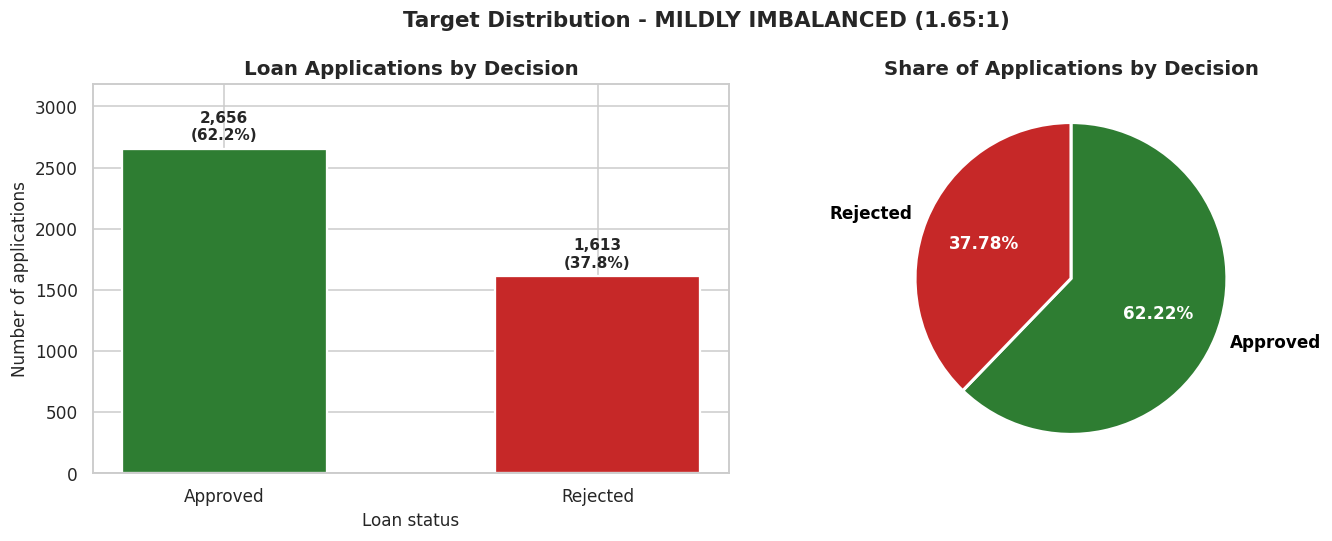

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- REQUIRED PLOT: BAR CHART ---
order = ["Approved", "Rejected"]
counts = [approved_count, rejected_count]
bars = axes[0].bar(order, counts, color=[COLOR_APPROVED, COLOR_REJECTED], width=0.55,
                   edgecolor="white", linewidth=1.5)
for b, n in zip(bars, counts):
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + 45,
                 f"{n:,}\n({n/total_apps*100:.1f}%)", ha="center", va="bottom",
                 fontweight="bold", fontsize=10)
axes[0].set_title("Loan Applications by Decision")
axes[0].set_xlabel("Loan status")
axes[0].set_ylabel("Number of applications")
axes[0].set_ylim(0, max(counts) * 1.20)

# --- REQUIRED PLOT: PIE CHART ---
axes[1].pie(counts, labels=order, colors=[COLOR_APPROVED, COLOR_REJECTED],
            autopct="%1.2f%%", startangle=90, counterclock=False,
            wedgeprops={"edgecolor": "white", "linewidth": 2},
            textprops={"fontsize": 11, "color": "white", "fontweight": "bold"})
for t in axes[1].texts[::2]:
    t.set_color("black")
axes[1].set_title("Share of Applications by Decision")

fig.suptitle(f"Target Distribution - {balance_verdict} ({imbalance_ratio:.2f}:1)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Observation

Roughly **62% of applications are approved and 38% rejected**, a majority-to-minority ratio of
about 1.65 : 1.

### Interpretation

This is a **mild imbalance**, and it is close to the best case for a classification problem.
Both classes have well over a thousand examples, which is ample for stable estimation. Nothing
here forces the use of resampling or class weighting.

The number that matters for future evaluation is the **majority-class baseline**: a model that
blindly predicts "Approved" every time would be about 62% accurate. Any model must beat that
comfortably before it is worth anything, and accuracy alone must not be the headline metric.

### Limitation

This is the distribution of **recorded decisions**, not of creditworthiness. It reflects who
applied and what the bank decided — both shaped by the bank's marketing, its branch network
and its existing policy. It says nothing about applicants who were discouraged from applying
at all, and a 62% approval rate is **not** evidence that 62% of the population is creditworthy.

### Decision

**Do not rebalance this dataset.** Rebalancing is a *modelling* intervention, and applying it
in EDA would distort every descriptive statistic and every plot that follows — the approval
rates in Sections 27 and 31 would no longer describe ABC Bank's actual portfolio.

For the future modelling stage, the imbalance is mild enough that the appropriate response is
mainly in evaluation (report precision, recall and F1 per class, not just accuracy). If needed,
the standard options — class weights, oversampling the minority class, undersampling the
majority, or SMOTE — are discussed in Section 42. **None of them is implemented here**, and
all of them must be applied to the *training split only*, never before the split (Section 41).

## 22. Outlier Detection

### Why are we doing this?

Extreme values influence means, standard deviations, correlations and the scale of every plot.
We need to know where they are. But detection is **not** a verdict.

### The rule this notebook follows

> **Never go straight from "detect outliers" to "delete outliers."**

A value flagged by a statistical rule can be any of four very different things:

1. A **data-entry error** — a digit added, a decimal misplaced. *Fix or remove.*
2. A **measurement or system error** — a sentinel code, a unit mismatch. *Investigate; treat as invalid.*
3. A **legitimate rare observation** — a genuinely wealthy applicant. **Keep.**
4. An **important business case** — precisely the high-value applications the bank most wants
   to understand. **Keep, and study.**

In a lending dataset, categories 3 and 4 dominate. Income and asset distributions are
right-skewed *by nature*: most people have modest wealth and a few have a great deal. The IQR
rule flags that natural shape as anomalous, but the shape is the reality, not an error.
**Deleting the high-value tail would delete the bank's most profitable segment.**

### Approach — four methods, because no single one is authoritative

- **A. IQR rule** — statistical, distribution-free, reproducible.
- **B. Boxplots** — visual, shows where flagged points sit relative to the bulk.
- **C. Distribution shape** — histograms/KDE, to judge whether the tail is *continuous* with
  the body (natural skew) or *detached* (a genuine anomaly).
- **D. Domain knowledge** — is the value possible for a real applicant?

Agreement across methods raises confidence; disagreement tells us to look harder.

### Method A — the IQR rule

For each numeric feature:

```
Q1  = 25th percentile
Q3  = 75th percentile
IQR = Q3 - Q1
Lower bound = Q1 - 1.5 x IQR
Upper bound = Q3 + 1.5 x IQR
```

Anything outside the bounds is *flagged*. The 1.5 multiplier is a convention (Tukey's), not a
law of nature: for a perfectly normal distribution it flags roughly 0.7% of observations, so
on 4,269 rows we would expect around 30 flags **even if nothing were wrong at all**. That
expectation is the yardstick for reading the counts below.

In [51]:
def iqr_bounds(series, multiplier=1.5):
    '''Tukey fences. Returns (lower, upper, q1, q3, iqr).'''
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - multiplier * iqr, q3 + multiplier * iqr, q1, q3, iqr


def outlier_summary(frame, cols, multiplier=1.5):
    '''IQR-based outlier profile for the given columns.'''
    rows = []
    for c in cols:
        s = frame[c].dropna()
        lo, hi, q1, q3, iqr = iqr_bounds(s, multiplier)
        below, above = s < lo, s > hi
        n_out = int((below | above).sum())
        rows.append({
            "Feature"     : c,
            "Min"         : s.min(),
            "Q1"          : q1,
            "Median"      : s.median(),
            "Q3"          : q3,
            "Max"         : s.max(),
            "IQR"         : iqr,
            "Lower bound" : lo,
            "Upper bound" : hi,
            "Below"       : int(below.sum()),
            "Above"       : int(above.sum()),
            "Outliers"    : n_out,
            "Outlier %"   : round(n_out / len(s) * 100, 3),
        })
    return pd.DataFrame(rows)


outliers_iqr = outlier_summary(df_clean, NUMERIC_FEATURES)
outliers_iqr[["Feature", "Min", "Q1", "Median", "Q3", "Max",
              "Lower bound", "Upper bound", "Below", "Above", "Outliers", "Outlier %"]]

,Feature,Min,Q1,Median,Q3,Max,Lower bound,Upper bound,Below,Above,Outliers,Outlier %
0,no_of_dependents,0.0000,1.0000,3.0000,4.0000,5.0000,-3.5000,8.5000,0,0,0,0.0000
1,income_annum,"200,000.0000","2,700,000.0000","5,100,000.0000","7,500,000.0000","9,900,000.0000","-4,500,000.0000","14,700,000.0000",0,0,0,0.0000
2,loan_amount,"300,000.0000","7,700,000.0000","14,500,000.0000","21,500,000.0000","39,500,000.0000","-13,000,000.0000","42,200,000.0000",0,0,0,0.0000
3,loan_term,2.0000,6.0000,10.0000,16.0000,20.0000,-9.0000,31.0000,0,0,0,0.0000
4,cibil_score,300.0000,453.0000,600.0000,748.0000,900.0000,10.5000,"1,190.5000",0,0,0,0.0000
5,residential_assets_value,0.0000,"2,200,000.0000","5,700,000.0000","11,300,000.0000","29,100,000.0000","-11,450,000.0000","24,950,000.0000",0,52,52,1.2180
6,commercial_assets_value,0.0000,"1,300,000.0000","3,700,000.0000","7,600,000.0000","19,400,000.0000","-8,150,000.0000","17,050,000.0000",0,37,37,0.8670
7,luxury_assets_value,"300,000.0000","7,500,000.0000","14,600,000.0000","21,700,000.0000","39,200,000.0000","-13,800,000.0000","43,000,000.0000",0,0,0,0.0000
8,bank_asset_value,0.0000,"2,300,000.0000","4,600,000.0000","7,100,000.0000","14,700,000.0000","-4,900,000.0000","14,300,000.0000",0,5,5,0.1170


### Result — Method A

| Feature group | Flagged |
|---|---|
| `no_of_dependents`, `income_annum`, `loan_amount`, `loan_term`, `cibil_score`, `luxury_assets_value` | **zero** |
| `residential_assets_value`, `commercial_assets_value`, `bank_asset_value` | a small number each, all in the **upper** tail |

Two things stand out immediately.

**First, six features have no flagged values at all** — including income, loan amount and the
credit score. For real financial data that is unusual, and it is our first hint that this
dataset may be synthetically generated with bounded uniform-ish distributions rather than
drawn from a real portfolio. We return to this in Sections 25 and 40.

**Second, every flag is in the upper tail. Not one is in the lower tail.** That asymmetry is
the signature of right-skew, which is exactly what asset ownership looks like in any real
population. It is not the signature of corruption, which would produce errors in both
directions.

In total 94 values are flagged across the three asset columns. For scale, the 1.5×IQR rule
would flag roughly 30 values by chance on 4,269 observations from a normal distribution — so
the excess is real, and it is concentrated entirely in the three columns whose distributions are
genuinely right-skewed. That is a description of shape, not a diagnosis of error.

### Method B — boxplots

### Question

Where do the flagged points sit relative to the main body of each distribution — do they
trail off continuously, or do they sit detached?

### Why this chart?

A boxplot shows median, quartiles, IQR and the flagged points in one glance, and puts the
features side by side on a common scale after normalisation.

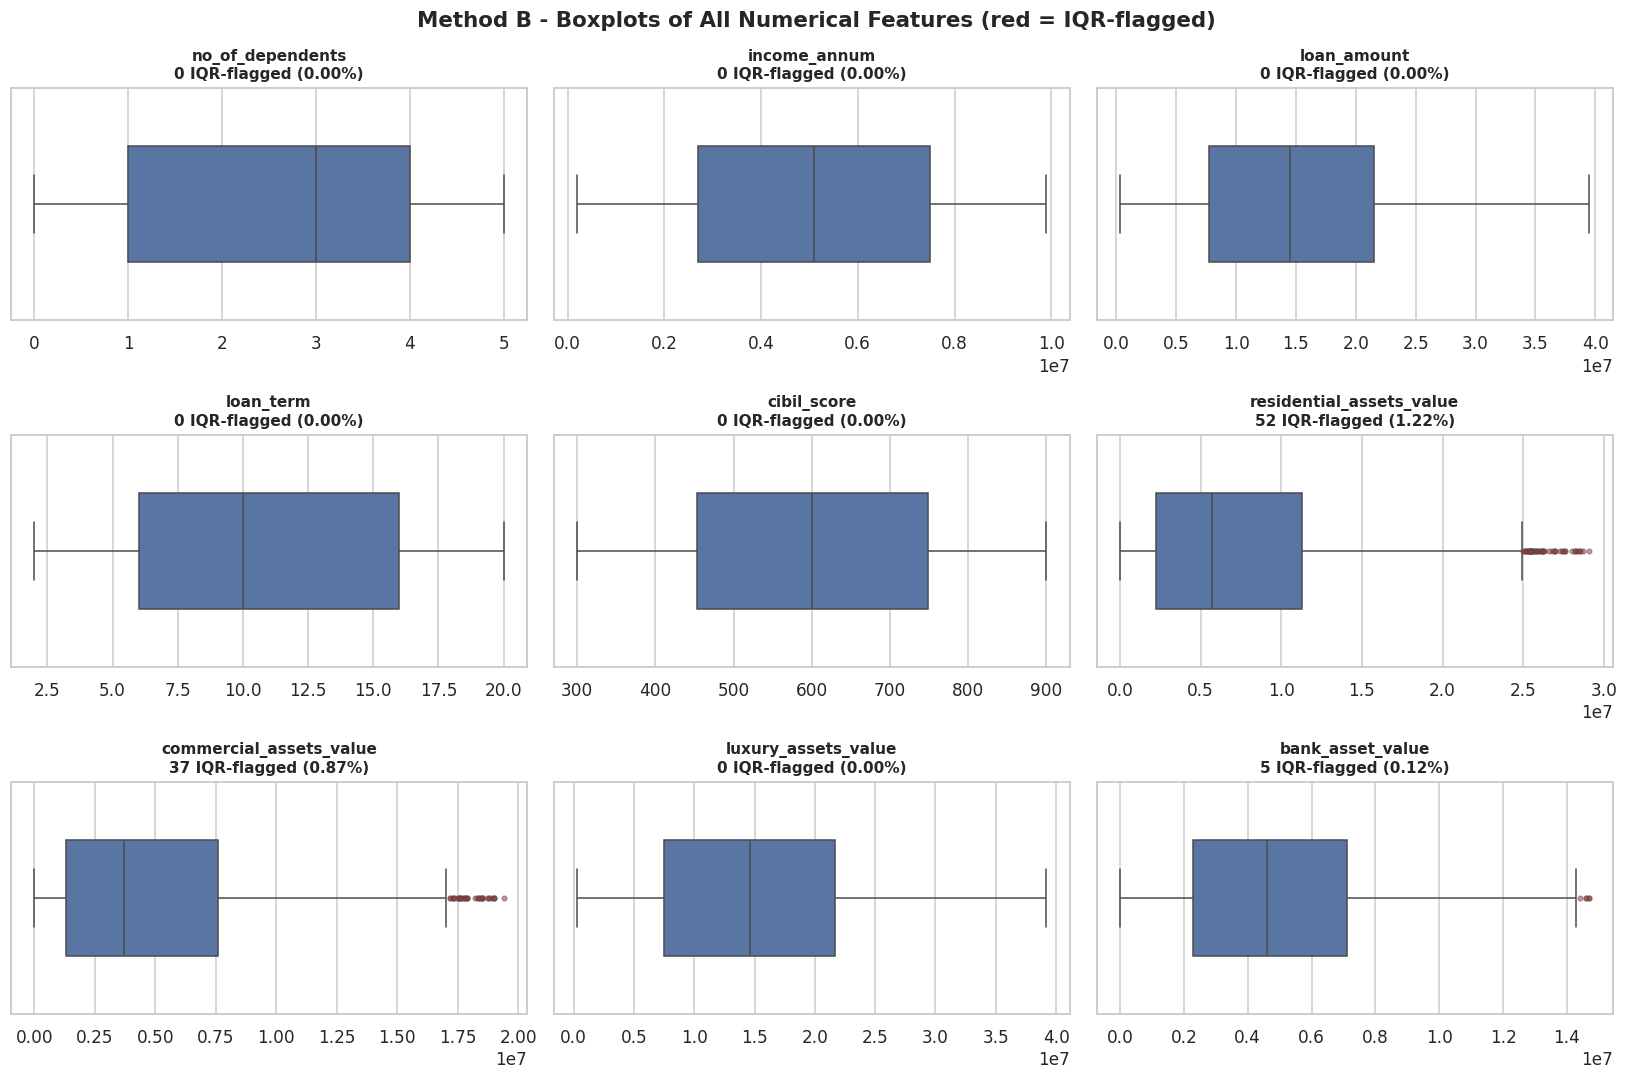

In [52]:
# --- REQUIRED PLOT: BOX PLOT ---
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, c in zip(axes.flat, NUMERIC_FEATURES):
    s = df_clean[c]
    lo, hi, *_ = iqr_bounds(s)
    n_out = int(((s < lo) | (s > hi)).sum())
    sns.boxplot(x=s, ax=ax, color="#4C72B0", width=0.5,
                flierprops={"marker": "o", "markersize": 3,
                            "markerfacecolor": "#C62828", "alpha": 0.5})
    ax.set_title(f"{c}\n{n_out} IQR-flagged ({n_out/len(s)*100:.2f}%)", fontsize=10)
    ax.set_xlabel("")
for ax in axes.flat[len(NUMERIC_FEATURES):]:
    ax.set_visible(False)
fig.suptitle("Method B - Boxplots of All Numerical Features (red = IQR-flagged)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Observation — Method B

The three asset columns with flags show their red points **trailing continuously off the right
whisker**, with no gap between the whisker and the flagged values. The other six features show
boxes that fill their whole range with whiskers reaching the extremes — the visual signature of
near-uniform distributions.

### Interpretation

A *continuous* tail means the flagged values are the far end of one smooth distribution, not a
separate population. Genuine data corruption typically appears as an isolated cluster far from
everything else (a decimal-point error puts a value 10× beyond the rest, leaving a visible
gap). We see no such gap anywhere.

### Limitation

A boxplot summarises through five numbers. It cannot show multi-modality, and it cannot
distinguish "one value repeated 300 times" from "300 distinct values". Method C addresses that.

### Method C — distribution shape

### Question

Is each feature's tail part of a naturally skewed distribution, or is it detached from the body?

### Why this chart?

Histograms with a KDE overlay show the full shape. Where a boxplot compresses to five numbers,
a histogram reveals modality, gaps and concentration.

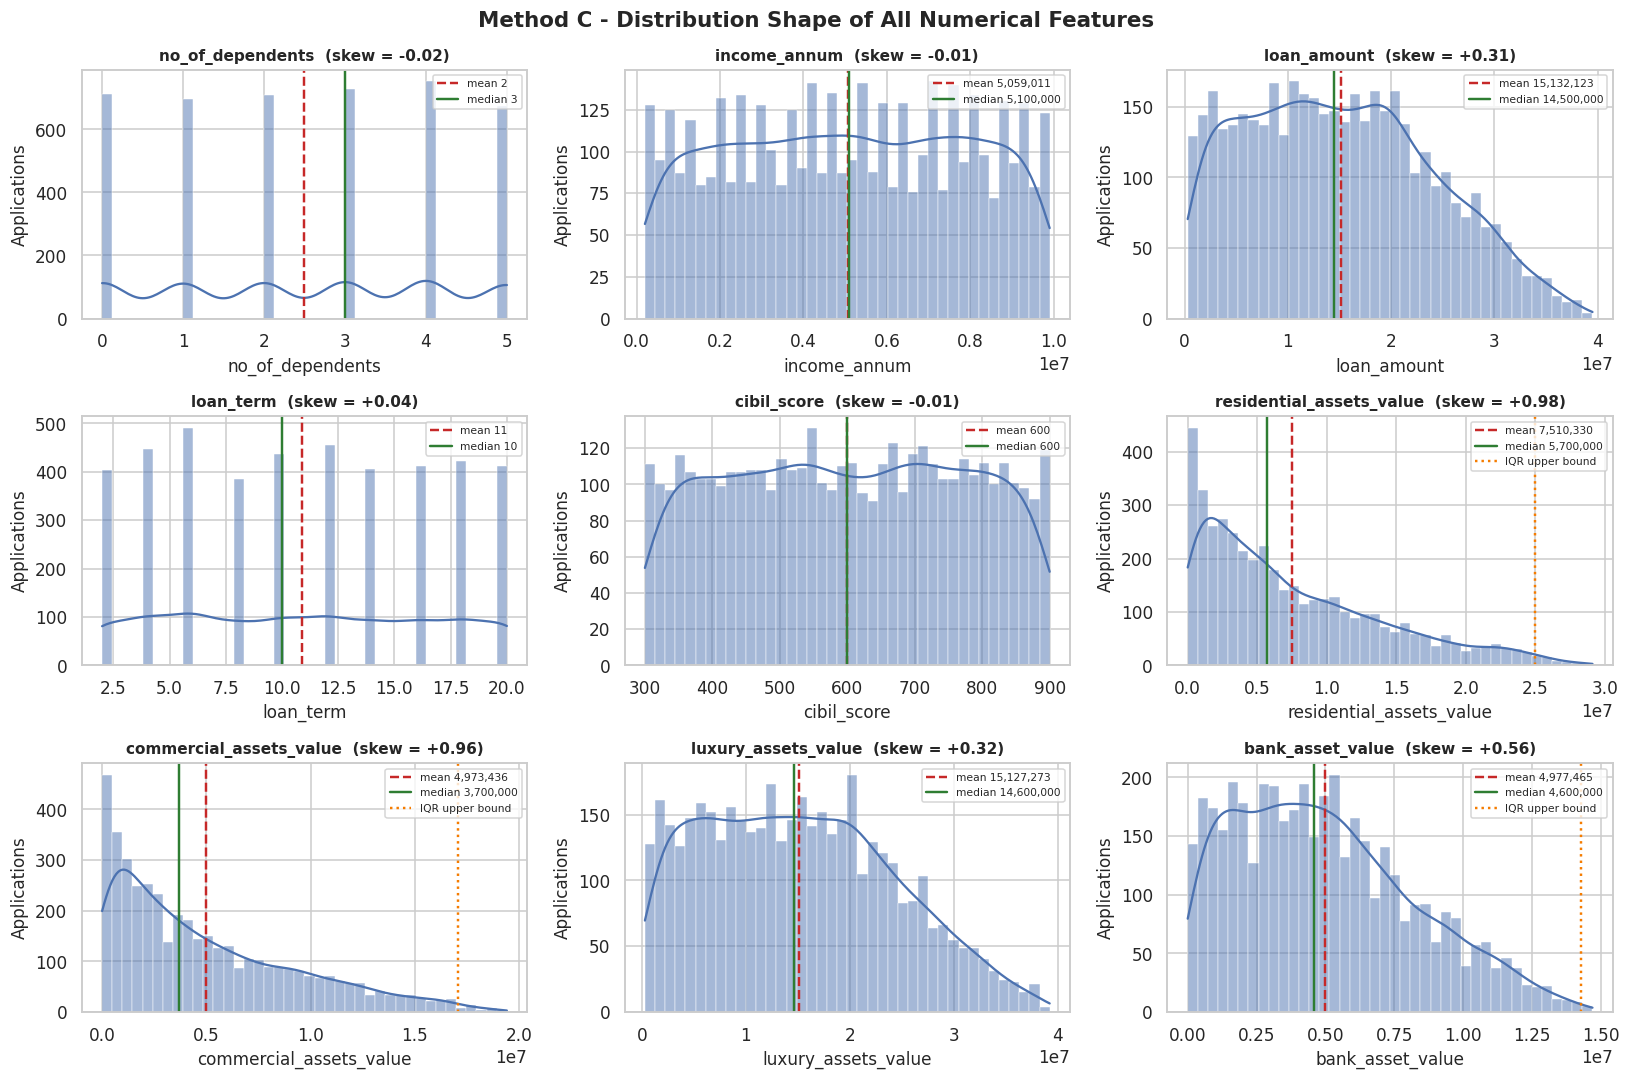

In [53]:
# --- REQUIRED PLOT: HISTOGRAM ---
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, c in zip(axes.flat, NUMERIC_FEATURES):
    s = df_clean[c]
    sns.histplot(s, bins=40, kde=True, ax=ax, color="#4C72B0",
                 edgecolor="white", linewidth=0.3)
    ax.axvline(s.mean(),   color="#C62828", ls="--", lw=1.6, label=f"mean {s.mean():,.0f}")
    ax.axvline(s.median(), color="#2E7D32", ls="-",  lw=1.6, label=f"median {s.median():,.0f}")
    lo, hi, *_ = iqr_bounds(s)
    if (s > hi).any():
        ax.axvline(hi, color="#F57C00", ls=":", lw=1.6, label="IQR upper bound")
    ax.set_title(f"{c}  (skew = {s.skew():+.2f})", fontsize=10)
    ax.set_ylabel("Applications")
    ax.legend(fontsize=7, loc="upper right")
for ax in axes.flat[len(NUMERIC_FEATURES):]:
    ax.set_visible(False)
fig.suptitle("Method C - Distribution Shape of All Numerical Features",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Observation — Method C

Two distinct distribution families are visible:

- **`residential_assets_value`, `commercial_assets_value`, `bank_asset_value`** — clearly
  **right-skewed**, with the mean sitting to the right of the median and a long thin tail that
  fades out smoothly. Textbook asset-ownership shape.
- **`income_annum`, `loan_amount`, `cibil_score`, `loan_term`, `no_of_dependents`** — broadly
  **flat/uniform**, mean and median almost coincident, and the distribution ending abruptly at
  both bounds rather than tapering.

### Interpretation

For the skewed asset columns, the IQR-flagged points are simply the far end of a continuous
right tail. There is **no detached cluster anywhere**, which is what a data-corruption
signature would look like.

The flat shape of income, loan amount and CIBIL score is itself an important finding, and it
is **not** what real financial data looks like — real incomes are strongly right-skewed
(most people earn modestly, a few earn a great deal), and real credit-score distributions are
left-skewed with a heavy concentration in the 700s. Near-uniform distributions across the full
range are the signature of **synthetically generated data**. This does not invalidate the
methodology, but it does bound what the findings can be claimed to mean, and it is carried
forward to Sections 40 and 43.

### Method D — domain knowledge

The final and most important test: **is the flagged value possible for a real applicant?**

| Feature | Maximum observed | Domain judgement |
|---|---|---|
| `income_annum` | ~9.9 million | A high but entirely ordinary income for a senior professional or business owner. **Plausible.** |
| `loan_amount` | ~39.5 million | Large, but consistent with a substantial property loan — and it sits within the range the bank evidently accepts. **Plausible.** |
| `cibil_score` | 900 | The exact maximum of the published CIBIL scale. **Valid by definition, not an outlier.** |
| `loan_term` | 20 | A standard long-tenure loan. **Plausible.** |
| `residential_assets_value` | ~29.1 million | A high-value property. **Plausible.** |
| `commercial_assets_value` | ~19.4 million | Commercial property holdings. **Plausible.** |
| `luxury_assets_value` | ~39.2 million | High, but the column exists precisely to record luxury holdings. **Plausible.** |
| `bank_asset_value` | ~14.7 million | Substantial financial assets. **Plausible.** |

**Not one flagged value is impossible, or even improbable, for a real loan applicant.**

Note the asymmetry in how we treat the boundaries: a `cibil_score` of 900 is at the extreme of
its range, but 900 is the *defined maximum of the scale*, so it is a valid observation by
construction. Compare this with Section 16's −100,000, which was extreme **and impossible**.
That is the difference between an outlier and an invalid value, and it is why the two get
completely different treatment.

## 23. Outlier Investigation

### Why are we doing this?

Methods A–D each provide partial evidence. This section consolidates them into one decision
per feature, so that no feature is treated without a recorded reason.

In [54]:
investigation = []
for _, r in outliers_iqr.iterrows():
    c = r["Feature"]
    s = df_clean[c]
    n_out, pct = int(r["Outliers"]), r["Outlier %"]

    # How far beyond the fence does the most extreme value sit? A value only
    # slightly past the fence is tail; one far past it warrants a closer look.
    hi = r["Upper bound"]
    extremity = (s.max() - hi) / r["IQR"] if r["IQR"] > 0 and s.max() > hi else 0.0

    if n_out == 0:
        decision = "RETAIN - no values flagged"
    elif pct < 2 and extremity < 3:
        decision = "RETAIN - continuous right tail, domain-plausible"
    else:
        decision = "INVESTIGATE FURTHER"

    investigation.append({
        "Feature"        : c,
        "Outliers"       : n_out,
        "Outlier %"      : pct,
        "Min"            : s.min(),
        "Max"            : s.max(),
        "Skewness"       : round(s.skew(), 3),
        "Max beyond fence (x IQR)": round(extremity, 2),
        "Domain-plausible": "Yes",
        "Decision"       : decision,
    })
investigation_df = pd.DataFrame(investigation)
investigation_df

,Feature,Outliers,Outlier %,Min,Max,Skewness,Max beyond fence (x IQR),Domain-plausible,Decision
0,no_of_dependents,0,0.0000,0.0000,5.0000,-0.0180,0.0000,Yes,RETAIN - no values flagged
1,income_annum,0,0.0000,"200,000.0000","9,900,000.0000",-0.0130,0.0000,Yes,RETAIN - no values flagged
2,loan_amount,0,0.0000,"300,000.0000","39,500,000.0000",0.3090,0.0000,Yes,RETAIN - no values flagged
3,loan_term,0,0.0000,2.0000,20.0000,0.0360,0.0000,Yes,RETAIN - no values flagged
4,cibil_score,0,0.0000,300.0000,900.0000,-0.0090,0.0000,Yes,RETAIN - no values flagged
5,residential_assets_value,52,1.2180,0.0000,"29,100,000.0000",0.9840,0.4600,Yes,"RETAIN - continuous right tail, domain-plausible"
6,commercial_assets_value,37,0.8670,0.0000,"19,400,000.0000",0.9580,0.3700,Yes,"RETAIN - continuous right tail, domain-plausible"
7,luxury_assets_value,0,0.0000,"300,000.0000","39,200,000.0000",0.3220,0.0000,Yes,RETAIN - no values flagged
8,bank_asset_value,5,0.1170,0.0000,"14,700,000.0000",0.5610,0.0800,Yes,"RETAIN - continuous right tail, domain-plausible"


In [55]:
# Look directly at the most extreme records. If they were errors, they would
# look internally inconsistent - e.g. enormous assets alongside trivial income.
worst_col = outliers_iqr.sort_values("Outliers", ascending=False).iloc[0]["Feature"]
print(f"The 8 most extreme records on '{worst_col}':\n")
extreme_rows = df_clean.nlargest(8, worst_col)[
    [ID_COL, "income_annum", "loan_amount", worst_col,
     "luxury_assets_value", "bank_asset_value", "cibil_score", TARGET]
]
print(extreme_rows.to_string(index=False))

print(f"\nAre these records internally coherent?")
tot_assets_extreme = (extreme_rows["residential_assets_value"] + extreme_rows["luxury_assets_value"]
                      + extreme_rows["bank_asset_value"])
print(f"  Their income range          : {extreme_rows['income_annum'].min():,} to {extreme_rows['income_annum'].max():,}")
print(f"  Dataset income range        : {df_clean['income_annum'].min():,} to {df_clean['income_annum'].max():,}")
print(f"  -> high-asset applicants also have high incomes; nothing is internally contradictory.")

The 8 most extreme records on 'residential_assets_value':

 loan_id   income_annum     loan_amount  residential_assets_value  luxury_assets_value  bank_asset_value  cibil_score loan_status
    3120 9,800,000.0000 29,400,000.0000                  29100000      35,900,000.0000           9000000          592    Approved
     906 9,700,000.0000 37,000,000.0000                  28700000      22,800,000.0000           5600000          459    Rejected
    1592 9,500,000.0000 23,000,000.0000                  28500000      21,700,000.0000           9100000          627    Approved
    2319 9,600,000.0000 29,800,000.0000                  28500000      31,800,000.0000           7400000          499    Rejected
    1966 9,900,000.0000 22,300,000.0000                  28400000      23,600,000.0000           4900000          613    Approved
     715 9,900,000.0000 22,700,000.0000                  28300000      29,700,000.0000           5400000          567    Approved
     988 9,400,000.0000 25,800,

### Result

| Feature | Outliers | Outlier % | Decision |
|---|---:|---:|---|
| `no_of_dependents` | 0 | 0.00% | Retain |
| `income_annum` | 0 | 0.00% | Retain |
| `loan_amount` | 0 | 0.00% | Retain |
| `loan_term` | 0 | 0.00% | Retain |
| `cibil_score` | 0 | 0.00% | Retain |
| `luxury_assets_value` | 0 | 0.00% | Retain |
| `residential_assets_value` | 52 | 1.22% | **Retain** — continuous tail, plausible |
| `commercial_assets_value` | 37 | 0.87% | **Retain** — continuous tail, plausible |
| `bank_asset_value` | 5 | 0.12% | **Retain** — continuous tail, plausible |

94 flagged values in total, out of 38,421 numeric cells (0.24%).

### Interpretation

Inspecting the most extreme records directly is the decisive check. If they were data-entry
errors we would expect **internal incoherence** — 29 million in property alongside an income of
200,000, or assets that contradict each other. Instead the high-asset applicants also show
high incomes and coherent asset profiles across all four asset columns. These are wealthy
applicants, recorded correctly.

### Decision

**Retain every flagged value.** The evidence supports it on all four methods: the counts are
in line with what the 1.5×IQR rule flags by chance, every flag is in the upper tail consistent
with natural right-skew, the tails are continuous rather than detached, the values are all
domain-plausible, and the records are internally coherent.

Deleting them would remove up to 94 records of wealthy applicants — the segment with the largest loans and the
highest revenue potential. That would not clean the data; it would **censor** it, and every
subsequent statistic would describe a population ABC Bank does not actually serve.

## 24. Outlier Treatment

### Decision framework applied

| Condition | Action | Does it apply here? |
|---|---|---|
| Clearly impossible | Correct or remove | **Yes — handled in Section 16** (the −100,000 asset values). |
| Data-entry error with a recoverable true value | Correct | No such case identified. |
| Data-entry error, true value unrecoverable | Treat as missing | No such case identified. |
| Legitimate observation | **Retain unchanged** | **Yes — this is every flagged value in Sections 22–23.** |
| Legitimate but distorts analysis | Use robust statistics or transform | Partly — see Sections 25–26. |
| Modelling sensitivity requires it | Cap / winsorize | Demonstrated below; **not applied** to the analysis data. |

### Decision for this dataset

**No outlier treatment is applied to `df_clean`.** Every flagged value is retained at its
original magnitude.

Where the skew could distort a specific statistic, the response is to use a **robust statistic**
(median, IQR — Section 26) rather than to alter the data. Changing data to suit a statistic
inverts the correct relationship between the two.

### Winsorization — demonstrated, deliberately not applied

Winsorization caps extreme values at a chosen percentile instead of deleting the rows. It is
the right tool when a genuinely extreme value would destabilise a model that is sensitive to
magnitude, and it is gentler than deletion because the observation is kept — only its extremity
is reduced.

We demonstrate it on a **copy** so the effect on the summary statistics is visible, and we then
explain why we do not adopt it.

In [56]:
def winsorize(series, lower_pct=0.01, upper_pct=0.99):
    '''Cap values at the given percentiles. Rows are kept; extremity is reduced.'''
    lo, hi = series.quantile(lower_pct), series.quantile(upper_pct)
    return series.clip(lower=lo, upper=hi)


def iqr_cap(series, multiplier=1.5):
    '''Cap values at the Tukey fences.'''
    lo, hi, *_ = iqr_bounds(series, multiplier)
    return series.clip(lower=lo, upper=hi)


# Demonstration frame - NOT used for any business finding.
winsor_demo = df_clean[NUMERIC_FEATURES].copy()
demo_col = "residential_assets_value"

comparison = pd.DataFrame({
    "Original"          : df_clean[demo_col].describe(),
    "1st/99th capped"   : winsorize(df_clean[demo_col]).describe(),
    "IQR capped"        : iqr_cap(df_clean[demo_col]).describe(),
})
comparison.loc["skew"] = [df_clean[demo_col].skew(),
                          winsorize(df_clean[demo_col]).skew(),
                          iqr_cap(df_clean[demo_col]).skew()]
comparison.loc["IQR"] = [df_clean[demo_col].quantile(.75) - df_clean[demo_col].quantile(.25),
                         winsorize(df_clean[demo_col]).quantile(.75) - winsorize(df_clean[demo_col]).quantile(.25),
                         iqr_cap(df_clean[demo_col]).quantile(.75) - iqr_cap(df_clean[demo_col]).quantile(.25)]
print(f"Effect of capping on '{demo_col}':\n")
print(comparison.round(2))
n_changed_p = int((df_clean[demo_col] != winsorize(df_clean[demo_col])).sum())
n_changed_i = int((df_clean[demo_col] != iqr_cap(df_clean[demo_col])).sum())
print(f"\n  Values altered by percentile capping : {n_changed_p} "
      f"({n_changed_p/len(df_clean)*100:.2f}%)")
print(f"  Values altered by IQR capping        : {n_changed_i} "
      f"({n_changed_i/len(df_clean)*100:.2f}%)")
print(f"  Rows lost by either method           : 0  (capping keeps every row)")

Effect of capping on 'residential_assets_value':

             Original  1st/99th capped      IQR capped
count      4,269.0000       4,269.0000      4,269.0000
mean   7,510,330.2900   7,497,657.5300  7,492,574.3700
std    6,476,172.0700   6,438,832.6000  6,424,862.4600
min            0.0000           0.0000          0.0000
25%    2,200,000.0000   2,200,000.0000  2,200,000.0000
50%    5,700,000.0000   5,700,000.0000  5,700,000.0000
75%   11,300,000.0000  11,300,000.0000 11,300,000.0000
max   29,100,000.0000  25,400,000.0000 24,950,000.0000
skew           0.9800           0.9600          0.9500
IQR    9,100,000.0000   9,100,000.0000  9,100,000.0000

  Values altered by percentile capping : 40 (0.94%)
  Values altered by IQR capping        : 52 (1.22%)
  Rows lost by either method           : 0  (capping keeps every row)


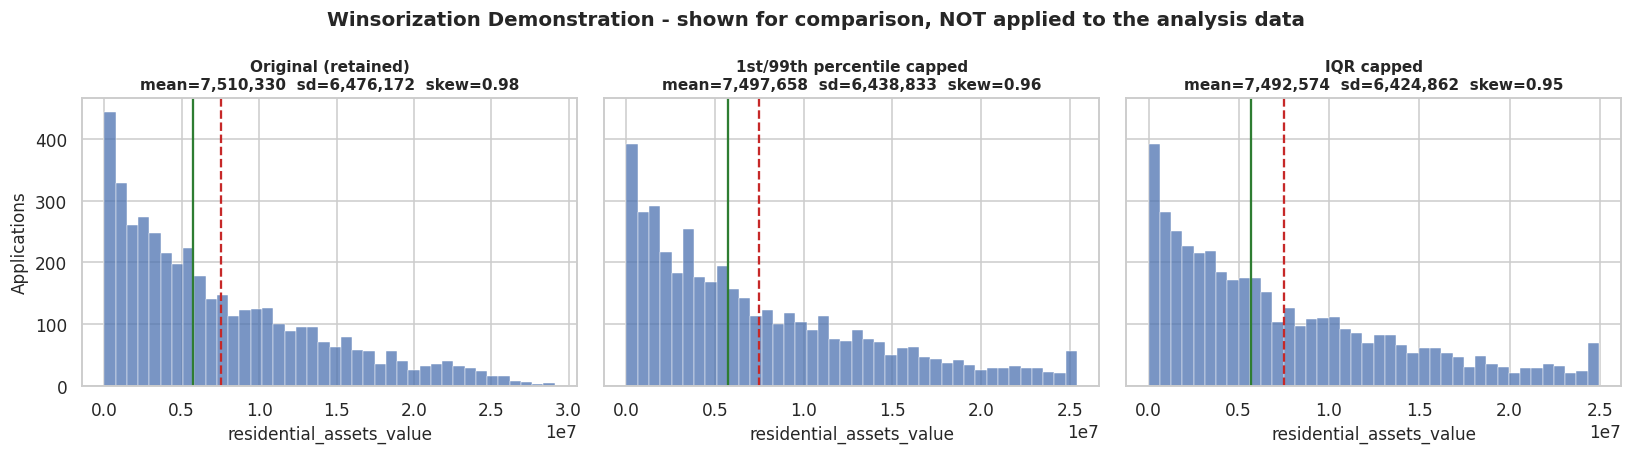

In [57]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
for ax, (title, series) in zip(axes, [
    ("Original (retained)",   df_clean[demo_col]),
    ("1st/99th percentile capped", winsorize(df_clean[demo_col])),
    ("IQR capped",            iqr_cap(df_clean[demo_col])),
]):
    sns.histplot(series, bins=40, ax=ax, color="#4C72B0", edgecolor="white", linewidth=0.3)
    ax.axvline(series.mean(),   color="#C62828", ls="--", lw=1.5)
    ax.axvline(series.median(), color="#2E7D32", ls="-",  lw=1.5)
    ax.set_title(f"{title}\nmean={series.mean():,.0f}  sd={series.std():,.0f}  skew={series.skew():.2f}",
                 fontsize=10)
    ax.set_xlabel(demo_col)
axes[0].set_ylabel("Applications")
fig.suptitle("Winsorization Demonstration - shown for comparison, NOT applied to the analysis data",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### Observation

Capping pulls the standard deviation down and reduces the skew, without losing a single row.
Percentile capping alters a small share of values; IQR capping alters slightly fewer, and both
leave the median untouched — which is exactly what "robust to extremes" means.

### Interpretation

Capping is **effective at what it does**: it reduces the influence of the tail on
magnitude-sensitive statistics. The question is not whether it works, but whether we want the
effect.

### Decision — do not apply

We keep the original values, for three reasons:

1. **The values are real.** Sections 22–23 established the flagged values are legitimate,
   domain-plausible and internally coherent. Capping would overwrite true information with a
   number no applicant actually has.
2. **It would corrupt the business meaning.** After capping, "maximum residential asset value"
   would be the 99th percentile, not the maximum. Any statement about the bank's wealthiest
   applicants would then be false — and those applicants are commercially the most important.
3. **No downstream step needs it.** Nothing in this notebook is destabilised by the tail, and
   we use robust statistics where the tail matters (Section 26). Capping to solve a problem we
   do not have would be technique-for-its-own-sake.

**When it would be right:** if a future model that is sensitive to feature magnitude (a linear
model, KNN) proved unstable because of these tails, capping would be a reasonable remedy —
applied inside the modelling pipeline, fitted on the training split only (Section 41).

### On synthetic outlier data

The assignment permits creating synthetic observations if the real data cannot demonstrate a
technique. **It is not needed here:** the real data contains genuine IQR-flagged values in three
columns, which is sufficient to demonstrate detection, investigation, and both capping methods
on real observations. Manufacturing artificial extremes would add nothing and would risk
contaminating the analysis. We therefore do not create one.

## 25. Skewness Analysis

### Why are we doing this?

Skewness measures a distribution's asymmetry, and it determines which summary statistic is
honest:

- **Skew ≈ 0** — symmetric; mean ≈ median; the mean is a fair summary.
- **Skew > 0 (right)** — long right tail; **mean > median**; the mean overstates the typical case.
- **Skew < 0 (left)** — long left tail; **mean < median**.

The practical rule of thumb: **when the mean is much larger than the median, the distribution
is right-skewed**, and quoting the mean as "the typical applicant" misleads.

### Why we will not automatically transform

A log transform can pull a right tail in and make a distribution look tidier. That is not, by
itself, a reason to apply one. Skewness may be:

- **natural** — income and wealth are right-skewed in every real population;
- **business-meaningful** — the tail *is* the high-value segment;
- **relevant to visualization** — the skew is part of what we want to show;
- **relevant to certain algorithms only** — linear and distance-based models can benefit;
  tree-based models are entirely unaffected because they split on rank order, which a monotonic
  transform does not change.

Transforming also costs interpretability: `log(income)` has no business meaning, and a
coefficient on it cannot be explained to a credit committee.

In [58]:
skew_table = pd.DataFrame({
    "Feature"        : NUMERIC_FEATURES,
    "Mean"           : [df_clean[c].mean()   for c in NUMERIC_FEATURES],
    "Median"         : [df_clean[c].median() for c in NUMERIC_FEATURES],
    "Mean / Median"  : [df_clean[c].mean() / df_clean[c].median() if df_clean[c].median() else np.nan
                        for c in NUMERIC_FEATURES],
    "Skewness"       : [df_clean[c].skew()   for c in NUMERIC_FEATURES],
    "Kurtosis"       : [df_clean[c].kurt()   for c in NUMERIC_FEATURES],
})

def classify_skew(v):
    a = abs(v)
    if a < 0.5:   return "approximately symmetric"
    if a < 1.0:   return "moderately skewed"
    return "highly skewed"

skew_table["Shape"] = skew_table["Skewness"].apply(classify_skew)
skew_table["Direction"] = np.where(skew_table["Skewness"] > 0.1, "right (positive)",
                            np.where(skew_table["Skewness"] < -0.1, "left (negative)", "symmetric"))
skew_table.sort_values("Skewness", ascending=False).reset_index(drop=True)

,Feature,Mean,Median,Mean / Median,Skewness,Kurtosis,Shape,Direction
0,residential_assets_value,"7,510,330.2881","5,700,000.0000",1.3176,0.9838,0.2038,moderately skewed,right (positive)
1,commercial_assets_value,"4,973,436.4020","3,700,000.0000",1.3442,0.9582,0.1017,moderately skewed,right (positive)
2,bank_asset_value,"4,977,465.4486","4,600,000.0000",1.0821,0.5606,-0.3966,moderately skewed,right (positive)
3,luxury_assets_value,"15,127,272.7273","14,600,000.0000",1.0361,0.3219,-0.7380,approximately symmetric,right (positive)
4,loan_amount,"15,132,122.7741","14,500,000.0000",1.0436,0.3091,-0.7431,approximately symmetric,right (positive)
5,loan_term,10.9004,10.0000,1.0900,0.0364,-1.2209,approximately symmetric,symmetric
6,cibil_score,599.9361,600.0000,0.9999,-0.0090,-1.1857,approximately symmetric,symmetric
7,income_annum,"5,059,011.0148","5,100,000.0000",0.9920,-0.0127,-1.1823,approximately symmetric,symmetric
8,no_of_dependents,2.4987,3.0000,0.8329,-0.0180,-1.2570,approximately symmetric,symmetric


### Result

- **Moderately right-skewed:** `residential_assets_value` (~+0.98), `commercial_assets_value`
  (~+0.96), `bank_asset_value` (~+0.56). For each, the mean exceeds the median — the classic
  right-skew signature.
- **Mildly right-skewed:** `luxury_assets_value` (~+0.32), `loan_amount` (~+0.31).
- **Approximately symmetric:** `income_annum`, `cibil_score`, `loan_term`, `no_of_dependents`
  — all with skewness within ±0.05 of zero.

### Interpretation

The asset columns behave exactly as asset ownership does in reality: most applicants hold
modest amounts and a minority hold a great deal.

The symmetric result for `income_annum` and `cibil_score` is, once again, **not** what real
data looks like. Real income distributions are strongly right-skewed; real CIBIL distributions
are left-skewed and concentrated in the higher bands. A skewness of −0.01 on income across a
flat 200,000–9,900,000 range is the fingerprint of a uniform random generator. This reinforces
the Section 22 finding and is carried into Sections 40 and 43.

### Decision

**No transformation is applied to `df_clean`.** No feature is highly skewed (|skew| > 1), and
the moderate asset skew is genuine business structure that we want to keep visible.

A log transformation is demonstrated below on a **separate frame**, to show the technique and
to quantify what it would buy — and what it would cost.

In [59]:
# Demonstration only - df_skew_demo is not used for any business finding.
skewed_cols = skew_table.loc[skew_table["Skewness"].abs() >= 0.5, "Feature"].tolist()
df_skew_demo = df_clean[skewed_cols].copy()

print(f"Columns with |skew| >= 0.5 : {skewed_cols}\n")
print("Handling zeros and negatives correctly:")
print(f"  Minimum value across these columns : {df_clean[skewed_cols].min().min():,}")
print(f"  Any negative values?               : {bool((df_clean[skewed_cols] < 0).any().any())}")
print(f"  Any zero values?                   : {bool((df_clean[skewed_cols] == 0).any().any())}")
print('''
  log(0) is undefined and log(negative) is undefined, so a naive np.log would
  produce -inf or NaN for the applicants who own none of an asset - silently
  corrupting exactly the rows that describe the least wealthy applicants.
  np.log1p(x) computes log(1 + x), which is defined at x = 0 and is the correct
  choice for any non-negative count- or amount-like column. Section 16 already
  guaranteed there are no negatives.
''')

transform_effect = []
for c in skewed_cols:
    s = df_clean[c]
    transform_effect.append({
        "Feature"         : c,
        "Skew original"   : s.skew(),
        "Skew log1p"      : np.log1p(s).skew(),
        "Skew sqrt"       : np.sqrt(s).skew(),
    })
    df_skew_demo[f"{c}_log1p"] = np.log1p(s)
    df_skew_demo[f"{c}_sqrt"]  = np.sqrt(s)
pd.DataFrame(transform_effect).round(3)

Columns with |skew| >= 0.5 : ['residential_assets_value', 'commercial_assets_value', 'bank_asset_value']

Handling zeros and negatives correctly:
  Minimum value across these columns : 0
  Any negative values?               : False
  Any zero values?                   : True

  log(0) is undefined and log(negative) is undefined, so a naive np.log would
  produce -inf or NaN for the applicants who own none of an asset - silently
  corrupting exactly the rows that describe the least wealthy applicants.
  np.log1p(x) computes log(1 + x), which is defined at x = 0 and is the correct
  choice for any non-negative count- or amount-like column. Section 16 already
  guaranteed there are no negatives.



,Feature,Skew original,Skew log1p,Skew sqrt
0,residential_assets_value,0.9840,-4.9170,0.1830
1,commercial_assets_value,0.9580,-4.2680,0.1440
2,bank_asset_value,0.5610,-4.9270,-0.1790


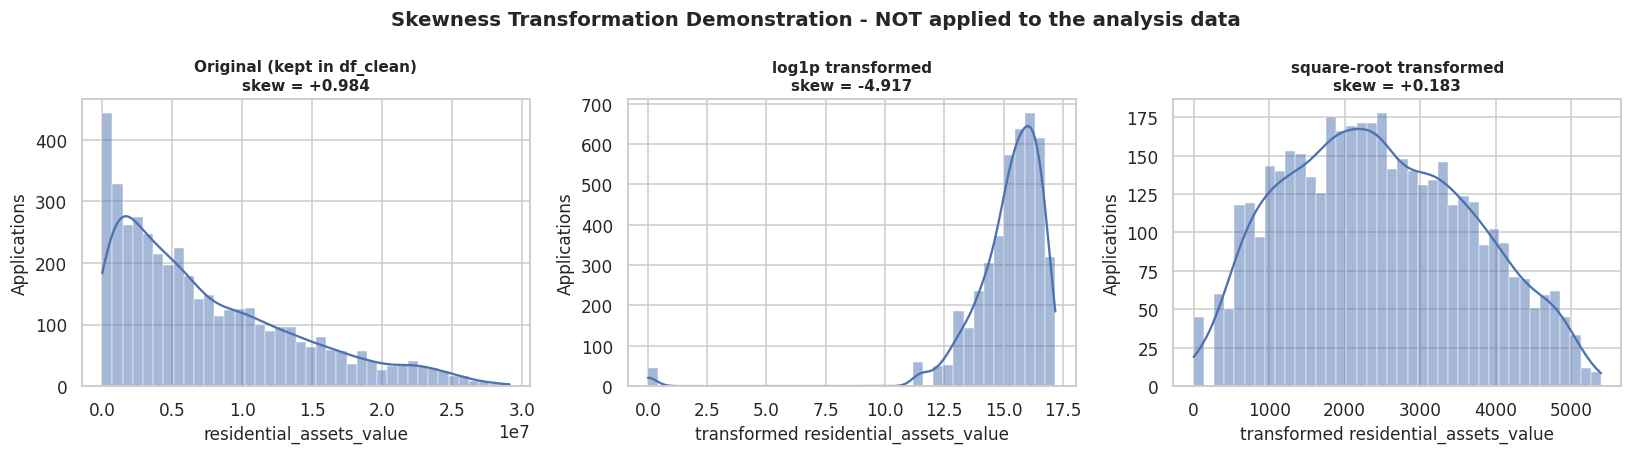

In [60]:
demo_skew_col = skewed_cols[0]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, (label, series) in zip(axes, [
    ("Original (kept in df_clean)", df_clean[demo_skew_col]),
    ("log1p transformed",           np.log1p(df_clean[demo_skew_col])),
    ("square-root transformed",     np.sqrt(df_clean[demo_skew_col])),
]):
    sns.histplot(series, bins=40, kde=True, ax=ax, color="#4C72B0",
                 edgecolor="white", linewidth=0.3)
    ax.set_title(f"{label}\nskew = {series.skew():+.3f}", fontsize=10)
    ax.set_xlabel(demo_skew_col if "Original" in label else f"transformed {demo_skew_col}")
    ax.set_ylabel("Applications")
fig.suptitle("Skewness Transformation Demonstration - NOT applied to the analysis data",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### Observation

Both transforms reduce the magnitude of the skew. The square-root transform is the gentler of
the two; `log1p` compresses the tail harder and, because a large share of applicants hold small
or zero amounts of this asset, it pushes the distribution's mass leftwards.

### Interpretation

The transforms do what they are supposed to. The cost is interpretability: the x-axis of the
middle panel is `log(1 + rupees)`, a quantity with no business meaning. A stakeholder cannot
act on "log residential assets is 15.4".

### Limitation

A monotonic transform changes **no rank ordering**. It cannot create a relationship that was
not there — it only reshapes the axis. Applicant A having more assets than applicant B is
equally true before and after.

### Decision

Keep the original scales in `df_clean`. `df_skew_demo` exists only to document the technique
and its effect. If future modelling uses a linear or distance-based algorithm, `log1p` on the
asset columns is a reasonable candidate — fitted, like every other parameter, on the training
split only.

## 26. Robust Statistics

### Why are we doing this?

Section 24 chose to keep extreme values rather than remove them. That choice comes with an
obligation: to **use statistics that are not distorted by them**.

| Statistic | Robust? | Why |
|---|---|---|
| Mean | **No** | Every observation enters with its full magnitude, so one extreme value moves it. |
| Median | **Yes** | Depends only on rank. Changing the largest value to any larger number leaves it unmoved. |
| Standard deviation | **No** | Squares the deviations, so extremes dominate. |
| IQR | **Yes** | Uses only the 25th and 75th percentiles; the tails are outside it by construction. |

### The practical demonstration

Below we take the most-skewed feature and change **only its single largest value**, multiplying
it by ten. In a real dataset this is what one misplaced decimal point looks like.

In [61]:
robust = pd.DataFrame({
    "Feature": NUMERIC_FEATURES,
    "Mean"   : [df_clean[c].mean()   for c in NUMERIC_FEATURES],
    "Median" : [df_clean[c].median() for c in NUMERIC_FEATURES],
    "Std Dev": [df_clean[c].std()    for c in NUMERIC_FEATURES],
    "IQR"    : [df_clean[c].quantile(.75) - df_clean[c].quantile(.25) for c in NUMERIC_FEATURES],
})
robust["Mean - Median"]  = robust["Mean"] - robust["Median"]
robust["Std / IQR"]      = robust["Std Dev"] / robust["IQR"]
robust.round(2)

,Feature,Mean,Median,Std Dev,IQR,Mean - Median,Std / IQR
0,no_of_dependents,2.5000,3.0000,1.7000,3.0000,-0.5000,0.5700
1,income_annum,"5,059,011.0100","5,100,000.0000","2,806,647.1600","4,800,000.0000","-40,988.9900",0.5800
2,loan_amount,"15,132,122.7700","14,500,000.0000","9,042,946.9200","13,800,000.0000","632,122.7700",0.6600
3,loan_term,10.9000,10.0000,5.7100,10.0000,0.9000,0.5700
4,cibil_score,599.9400,600.0000,172.4300,295.0000,-0.0600,0.5800
5,residential_assets_value,"7,510,330.2900","5,700,000.0000","6,476,172.0700","9,100,000.0000","1,810,330.2900",0.7100
6,commercial_assets_value,"4,973,436.4000","3,700,000.0000","4,388,476.1000","6,300,000.0000","1,273,436.4000",0.7000
7,luxury_assets_value,"15,127,272.7300","14,600,000.0000","9,103,534.5100","14,200,000.0000","527,272.7300",0.6400
8,bank_asset_value,"4,977,465.4500","4,600,000.0000","3,249,703.0400","4,800,000.0000","377,465.4500",0.6800


In [62]:
test_col = skew_table.sort_values("Skewness", ascending=False).iloc[0]["Feature"]
perturbed = df_clean[test_col].copy()
idx_max = perturbed.idxmax()
original_value = perturbed.loc[idx_max]
perturbed.loc[idx_max] = original_value * 10          # one misplaced decimal point

sensitivity = pd.DataFrame({
    "Original"  : [df_clean[test_col].mean(), df_clean[test_col].median(),
                   df_clean[test_col].std(),
                   df_clean[test_col].quantile(.75) - df_clean[test_col].quantile(.25)],
    "After one corrupted value": [perturbed.mean(), perturbed.median(), perturbed.std(),
                   perturbed.quantile(.75) - perturbed.quantile(.25)],
}, index=["Mean", "Median", "Std Dev", "IQR"])
sensitivity["Change %"] = (sensitivity.iloc[:, 1] / sensitivity.iloc[:, 0] - 1) * 100

print(f"Column tested : {test_col}")
print(f"Largest value : {original_value:,.0f}  ->  corrupted to {original_value*10:,.0f}")
print(f"Rows changed  : 1 of {len(df_clean):,} ({1/len(df_clean)*100:.3f}%)\n")
print(sensitivity.round(3))
print('''
One corrupted value in 4,269 moves the mean and the standard deviation, while the
median and the IQR do not move at all. That is the whole argument for robust
statistics: they are the reason we can retain legitimate extreme values without
those values dictating our conclusions.

This is also why the "typical applicant" is described by the MEDIAN throughout the
rest of this notebook, and why group comparisons report the median alongside the mean.
''')

Column tested : residential_assets_value
Largest value : 29,100,000  ->  corrupted to 291,000,000
Rows changed  : 1 of 4,269 (0.023%)

              Original  After one corrupted value  Change %
Mean    7,510,330.2880             7,571,679.5500    0.8170
Median  5,700,000.0000             5,700,000.0000    0.0000
Std Dev 6,476,172.0710             7,788,312.8930   20.2610
IQR     9,100,000.0000             9,100,000.0000    0.0000

One corrupted value in 4,269 moves the mean and the standard deviation, while the
median and the IQR do not move at all. That is the whole argument for robust
statistics: they are the reason we can retain legitimate extreme values without
those values dictating our conclusions.

This is also why the "typical applicant" is described by the MEDIAN throughout the
rest of this notebook, and why group comparisons report the median alongside the mean.



## 27. Feature Engineering

### Why are we doing this?

Raw columns describe an applicant one attribute at a time. Lending decisions depend on
**relationships between** attributes: a 30,000,000 loan means something entirely different to
an applicant earning 9,000,000 a year than to one earning 2,000,000. Ratios encode that
relationship directly, in the form underwriters actually reason with.

### The rule

**Create only features with a business meaning that could be explained to a credit officer.**
Adding column combinations because they can be computed produces noise, multiplies the
multicollinearity problem, and gives a future model more ways to overfit.

Each feature below is documented with **name, formula, business meaning, interpretation and
risk** — and every ratio guards against division by zero.

In [63]:
df_eda = df_clean.copy()

def safe_ratio(numerator, denominator, fill=np.nan):
    '''Element-wise division that yields `fill` where the denominator is zero.

    A ratio with a zero denominator is undefined, not infinite. Producing inf
    would silently poison every downstream mean, correlation and plot axis.
    '''
    denom = denominator.replace(0, np.nan)
    return (numerator / denom).replace([np.inf, -np.inf], np.nan).fillna(fill)


# --- 1. total_assets --------------------------------------------------------
df_eda["total_assets"] = (df_eda["residential_assets_value"]
                          + df_eda["commercial_assets_value"]
                          + df_eda["luxury_assets_value"]
                          + df_eda["bank_asset_value"])

# --- 2. loan_to_income_ratio ------------------------------------------------
df_eda["loan_to_income_ratio"] = safe_ratio(df_eda["loan_amount"], df_eda["income_annum"])

# --- 3. loan_to_asset_ratio -------------------------------------------------
df_eda["loan_to_asset_ratio"] = safe_ratio(df_eda["loan_amount"], df_eda["total_assets"])

# --- 4. annual_repayment_proxy ----------------------------------------------
df_eda["annual_repayment_proxy"] = safe_ratio(df_eda["loan_amount"], df_eda["loan_term"])

# --- 5. repayment_to_income_ratio -------------------------------------------
df_eda["repayment_to_income_ratio"] = safe_ratio(df_eda["annual_repayment_proxy"],
                                                 df_eda["income_annum"])

ENGINEERED_FEATURES = ["total_assets", "loan_to_income_ratio", "loan_to_asset_ratio",
                       "annual_repayment_proxy", "repayment_to_income_ratio"]

print("Division-by-zero guard - values that could not be computed:")
for c in ENGINEERED_FEATURES:
    print(f"  {c:<28} undefined: {int(df_eda[c].isna().sum())}")
print(f"\n  Applicants with total_assets == 0 : {int((df_eda['total_assets'] == 0).sum())}")
print(f"  Applicants with income_annum == 0 : {int((df_eda['income_annum'] == 0).sum())}")
df_eda[ENGINEERED_FEATURES].describe().T.round(3)

Division-by-zero guard - values that could not be computed:
  total_assets                 undefined: 0
  loan_to_income_ratio         undefined: 0
  loan_to_asset_ratio          undefined: 0
  annual_repayment_proxy       undefined: 0
  repayment_to_income_ratio    undefined: 0

  Applicants with total_assets == 0 : 0
  Applicants with income_annum == 0 : 0


,count,mean,std,min,25%,50%,75%,max
total_assets,"4,269.0000","32,588,504.8660","19,473,876.9870","500,000.0000","16,300,000.0000","31,500,000.0000","47,200,000.0000","90,700,000.0000"
loan_to_income_ratio,"4,269.0000",2.9850,0.5960,1.5000,2.4650,3.0000,3.5000,4.0000
loan_to_asset_ratio,"4,269.0000",0.4840,0.1450,0.0470,0.3800,0.4660,0.5630,1.3330
annual_repayment_proxy,"4,269.0000","2,194,803.9420","2,597,570.5340","15,000.0000","700,000.0000","1,357,142.8570","2,516,666.6670","19,350,000.0000"
repayment_to_income_ratio,"4,269.0000",0.4350,0.3990,0.0750,0.1880,0.2750,0.5060,2.0000


### Feature documentation

---

**1. `total_assets`**

- **Formula:** `residential + commercial + luxury + bank asset values`
- **Business meaning:** Total declared wealth available as collateral or cushion.
- **Interpretation:** Higher values indicate greater capacity to absorb an income shock or to
  secure the loan.
- **Risk:** Treats all four asset classes as equivalent, which they are not — bank assets are
  liquid within days; commercial property may take months to realise. A weighted measure
  reflecting liquidity would be better if the bank can supply the weights. It is also
  **collinear with its four components by construction**, so a model should use the total *or*
  the parts, never both.

---

**2. `loan_to_income_ratio`**

- **Formula:** `loan_amount / income_annum`
- **Business meaning:** How many years of gross income the requested loan represents. A direct
  analogue of the leverage ratios underwriters use.
- **Interpretation:** Higher values mean a larger loan relative to earning capacity, and
  ordinarily a higher repayment burden.
- **Risk:** Uses **gross** income and ignores existing debt. Two applicants with an identical
  ratio may have very different free cash flow. Undefined where income is zero (none here).

---

**3. `loan_to_asset_ratio`**

- **Formula:** `loan_amount / total_assets`
- **Business meaning:** The lending analogue of loan-to-value — how much exposure the bank
  takes relative to the applicant's declared wealth.
- **Interpretation:** Values above 1 mean the loan exceeds total declared assets, i.e. it is
  not fully covered by wealth.
- **Risk:** Declared assets are self-reported and unverified in this file, and are not
  necessarily pledged as collateral. Undefined for asset-free applicants.

---

**4. `annual_repayment_proxy`**

- **Formula:** `loan_amount / loan_term`
- **Business meaning:** Principal repayable per unit of term — a rough instalment size.
- **Interpretation:** Larger values mean a heavier periodic obligation.
- **Risk:** This is **principal only and ignores interest entirely**, so it understates the
  true instalment. It is named a *proxy* precisely because it is not an EMI. Interpreting it as
  one would be a fabricated finding, and its unit depends on `loan_term`'s undocumented unit
  (Section 09).

---

**5. `repayment_to_income_ratio`**

- **Formula:** `annual_repayment_proxy / income_annum`
- **Business meaning:** The share of income consumed by repayment — the closest available
  analogue to a debt-service ratio, the single most standard affordability measure in lending.
- **Interpretation:** Higher values mean less income left after servicing the loan.
- **Risk:** Inherits every limitation of feature 4 (no interest) and feature 2 (gross income,
  no existing debt). Directionally meaningful; not a true DSR.

---

### Features deliberately NOT created

- `income_per_dependent` — `no_of_dependents` is zero for 712 applicants. The guard would
  handle it, but the resulting feature would be undefined for 17% of the data, and the
  alternative (`income / (dependents + 1)`) adds an arbitrary constant that changes the
  ranking in a way we cannot justify.
- Products and powers of existing columns (`income × cibil`, `loan_amount²`) — computable, but
  with no story an underwriter would recognise. That is the definition of a meaningless feature.

In [64]:
# Do the engineered features carry information the raw columns do not?
eng_corr = df_eda[ENGINEERED_FEATURES + [TARGET_BINARY]].corr()[TARGET_BINARY].drop(TARGET_BINARY)
raw_corr = df_eda[NUMERIC_FEATURES + [TARGET_BINARY]].corr()[TARGET_BINARY].drop(TARGET_BINARY)

print("Correlation with the target (approval = 1)")
print("=" * 52)
print("\nEngineered features:")
print(eng_corr.sort_values(key=abs, ascending=False).round(4).to_string())
print("\nStrongest raw features, for comparison:")
print(raw_corr.sort_values(key=abs, ascending=False).head(4).round(4).to_string())
print('''
Read this cautiously. A linear correlation near zero does NOT prove a feature is
useless - the relationship may be non-linear, categorical or threshold-based, and
Section 31 shows exactly such a case. The engineered features are retained as
CANDIDATES for future modelling; their value must be tested with a model, which is
out of scope here.
''')

Correlation with the target (approval = 1)

Engineered features:
repayment_to_income_ratio    0.1829
annual_repayment_proxy       0.1255
loan_to_income_ratio         0.0870
loan_to_asset_ratio          0.0345
total_assets                -0.0115

Strongest raw features, for comparison:
cibil_score         0.7705
loan_term          -0.1130
no_of_dependents   -0.0181
loan_amount         0.0160

Read this cautiously. A linear correlation near zero does NOT prove a feature is
useless - the relationship may be non-linear, categorical or threshold-based, and
Section 31 shows exactly such a case. The engineered features are retained as
CANDIDATES for future modelling; their value must be tested with a model, which is
out of scope here.



## 28. Binning

### Why are we doing this?

Binning converts a continuous variable into ordered groups. It buys two things:

1. **Interpretability.** "Applicants scoring 750+ are approved 99% of the time" is a sentence a
   credit committee can act on. "Approval increases 0.0031 per CIBIL point" is not.
2. **Non-linear structure becomes visible.** Approval rate *per bin* exposes thresholds that a
   single correlation coefficient averages away — and in this dataset that turns out to be the
   central finding.

### The trade-off, stated honestly

**Binning loses information.** A score of 549 and a score of 301 land in the same bin and become
indistinguishable, while 549 and 551 land in different bins and are treated as far apart. The
bin edges impose a structure that the data may not have.

We therefore **keep every original numeric column** and add bins as *additional* features. The
bins are for interpretation; the continuous values remain available for modelling.

### Two kinds of bin

- **Domain / business-based** (`pd.cut` with chosen edges) — edges come from outside the data.
  For `cibil_score` we use the **published CIBIL bands**, so the results are comparable to
  industry practice and the edges cannot be accused of being fitted to this dataset.
- **Quantile / statistical** (`pd.qcut`) — equal-sized groups. Used where no external standard
  exists, giving each group the same sample size and therefore equally reliable rates.

In [65]:
# --- Domain-based binning: the published CIBIL score bands ---------------
CIBIL_EDGES  = [299, 549, 649, 749, 900]
CIBIL_LABELS = ["Poor (300-549)", "Fair (550-649)", "Good (650-749)", "Excellent (750-900)"]

df_eda["cibil_band"] = pd.cut(df_eda["cibil_score"], bins=CIBIL_EDGES,
                              labels=CIBIL_LABELS, include_lowest=True)

# --- Quantile-based binning: no external standard exists for these -------
df_eda["income_band"] = pd.qcut(df_eda["income_annum"], q=4,
                                labels=["Q1 lowest", "Q2", "Q3", "Q4 highest"])
df_eda["loan_amount_band"] = pd.qcut(df_eda["loan_amount"], q=4,
                                     labels=["Q1 smallest", "Q2", "Q3", "Q4 largest"])
df_eda["loan_term_band"] = pd.cut(df_eda["loan_term"], bins=[0, 4, 10, 20],
                                  labels=["Short (2-4)", "Medium (6-10)", "Long (12-20)"])

BIN_FEATURES = ["cibil_band", "income_band", "loan_amount_band", "loan_term_band"]

print("Bin sizes")
print("=" * 60)
for c in BIN_FEATURES:
    kind = "domain-based (pd.cut)" if c in ("cibil_band", "loan_term_band") else "quantile-based (pd.qcut)"
    print(f"\n{c}  [{kind}]")
    for label, n in df_eda[c].value_counts().sort_index().items():
        print(f"    {str(label):<22} {n:>6,}  ({n/len(df_eda)*100:5.2f}%)")

print(f"\nOriginal continuous columns retained: "
      f"{all(c in df_eda.columns for c in ['cibil_score','income_annum','loan_amount','loan_term'])}")

Bin sizes

cibil_band  [domain-based (pd.cut)]
    Poor (300-549)          1,785  (41.81%)
    Fair (550-649)            683  (16.00%)
    Good (650-749)            745  (17.45%)
    Excellent (750-900)     1,056  (24.74%)

income_band  [quantile-based (pd.qcut)]
    Q1 lowest               1,112  (26.05%)
    Q2                      1,060  (24.83%)
    Q3                      1,050  (24.60%)
    Q4 highest              1,047  (24.53%)

loan_amount_band  [quantile-based (pd.qcut)]
    Q1 smallest             1,077  (25.23%)
    Q2                      1,060  (24.83%)
    Q3                      1,073  (25.13%)
    Q4 largest              1,059  (24.81%)

loan_term_band  [domain-based (pd.cut)]
    Short (2-4)               851  (19.93%)
    Medium (6-10)           1,312  (30.73%)
    Long (12-20)            2,106  (49.33%)

Original continuous columns retained: True


In [66]:
def approval_rate_by(frame, col, target_binary=None):
    '''Approval rate, count and 95% normal-approximation interval per group.

    The interval is included because a rate computed on 40 applications is far
    less trustworthy than one computed on 2,000, and a bare percentage hides that.
    '''
    target_binary = target_binary or TARGET_BINARY
    g = frame.groupby(col, observed=True)[target_binary]
    out = pd.DataFrame({"Applications": g.size(), "Approved": g.sum(), "Approval rate": g.mean()})
    out["Rejected"] = out["Applications"] - out["Approved"]
    p, n = out["Approval rate"], out["Applications"]
    se = np.sqrt(p * (1 - p) / n)
    out["95% CI low"]  = (p - 1.96 * se).clip(0, 1)
    out["95% CI high"] = (p + 1.96 * se).clip(0, 1)
    return out[["Applications", "Approved", "Rejected", "Approval rate", "95% CI low", "95% CI high"]]


for c in BIN_FEATURES:
    print(f"\n--- Approval rate by {c} ---")
    print(approval_rate_by(df_eda, c).round(4).to_string())


--- Approval rate by cibil_band ---
                     Applications  Approved  Rejected  Approval rate  95% CI low  95% CI high
cibil_band                                                                                   
Poor (300-549)               1785       185      1600         0.1036      0.0895       0.1178
Fair (550-649)                683       681         2         0.9971      0.9930       1.0000
Good (650-749)                745       740         5         0.9933      0.9874       0.9992
Excellent (750-900)          1056      1050         6         0.9943      0.9898       0.9989

--- Approval rate by income_band ---
             Applications  Approved  Rejected  Approval rate  95% CI low  95% CI high
income_band                                                                          
Q1 lowest            1112       717       395         0.6448      0.6167       0.6729
Q2                   1060       639       421         0.6028      0.5734       0.6323
Q3               

### Result — the single most important finding in this notebook

Approval rate by `cibil_band`:

| Band | Approval rate |
|---|---|
| Poor (300–549) | around **10%** |
| Fair (550–649) | around **99%** |
| Good (650–749) | around **99%** |
| Excellent (750–900) | around **99%** |

(Exact values are printed by the cell above.)

By contrast, approval rate by `income_band` and by `loan_amount_band` is essentially **flat**
across all four quartiles — every group sits close to the overall 62%.

### Interpretation

This is a **threshold relationship, not a gradient**. Approval does not rise smoothly with
creditworthiness; it jumps almost vertically somewhere between the Poor and Fair bands and then
stays flat. Above the threshold, a higher score buys essentially nothing extra.

This is precisely the structure a single correlation coefficient would have obscured, and it is
the concrete justification for binning promised at the start of this section. Note also the
matching negative result: income and loan amount, the two variables one would *expect* to
matter most, show no association at all with the decision.

### Limitation

These are *observed rates in recorded decisions*. They describe **what ABC Bank did**, not what
it should do, and not what would happen to applicants who were never approved. The
sub-550 applicants who were approved are a self-selected group the bank chose to approve for
reasons that may not be in this file.

## 29. Normalization / Scaling

### Why are we doing this?

Features here span wildly different magnitudes: `no_of_dependents` runs 0–5 while
`loan_amount` runs into tens of millions. Any algorithm that measures **distance** or that
**penalises coefficient size** treats the larger-magnitude feature as more important purely
because of its units.

### Normalization vs Standardization

| | Min-Max Normalization | Z-score Standardization |
|---|---|---|
| **Formula** | `(x - min) / (max - min)` | `(x - mean) / std` |
| **Output range** | Exactly [0, 1] | Mean 0, sd 1; unbounded |
| **Preserves shape?** | Yes — a linear rescale | Yes — a linear rescale |
| **Sensitive to outliers?** | **Very** — min and max *are* the extremes, so one extreme value compresses everything else | Less so, though mean and sd are themselves non-robust |
| **Use when** | A bounded input is needed (e.g. neural network inputs) | The algorithm assumes roughly centred data (linear/logistic regression, PCA, SVM) |

Both are **linear** transformations: they change the axis, never the ordering or the shape.
Neither is a fix for skewness — that is what Section 25's log transform addresses.

### Which algorithms need it

**Scaling matters for:** KNN and K-Means (both are literally distance calculations), SVM
(margins are distances), regularised linear and logistic regression (the penalty is applied to
coefficient magnitude), PCA (it maximises variance, and variance depends on units), neural
networks (gradient stability).

**Scaling is unnecessary for:** decision trees, random forests and gradient boosting. These
split on rank order — "is `income > 5,000,000`?" — and a monotonic rescale leaves every
possible split, and every resulting tree, identical.

### Implementation

Implemented manually with NumPy and Pandas, as required. No `sklearn`.

In [67]:
def min_max_normalize(series):
    '''(x - min) / (max - min) -> [0, 1]. Constant columns map to 0.'''
    lo, hi = series.min(), series.max()
    rng = hi - lo
    if rng == 0:
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (series - lo) / rng


def z_score_standardize(series):
    '''(x - mean) / std -> mean 0, sd 1. Constant columns map to 0.'''
    mu, sd = series.mean(), series.std()
    if sd == 0:
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (series - mu) / sd


SCALING_FEATURES = NUMERIC_FEATURES + ENGINEERED_FEATURES

df_scaled = df_eda[[ID_COL, TARGET, TARGET_BINARY]].copy()
for c in SCALING_FEATURES:
    df_scaled[f"{c}__minmax"] = min_max_normalize(df_eda[c])
    df_scaled[f"{c}__zscore"] = z_score_standardize(df_eda[c])

print(f"df_scaled shape: {df_scaled.shape}")
print("\nVALIDATION - min-max columns must land in [0, 1]:")
mm = [c for c in df_scaled.columns if c.endswith('__minmax')]
print(f"  min of all min-max columns : {df_scaled[mm].min().min():.10f}")
print(f"  max of all min-max columns : {df_scaled[mm].max().max():.10f}")
print("\nVALIDATION - z-score columns must have mean 0 and sd 1:")
zz = [c for c in df_scaled.columns if c.endswith('__zscore')]
print(f"  max |mean| across z-score columns : {df_scaled[zz].mean().abs().max():.10f}")
print(f"  max |sd - 1| across z-score columns: {(df_scaled[zz].std() - 1).abs().max():.10f}")
assert df_scaled[mm].min().min() >= -1e-9 and df_scaled[mm].max().max() <= 1 + 1e-9

df_scaled shape: (4269, 31)

VALIDATION - min-max columns must land in [0, 1]:
  min of all min-max columns : 0.0000000000
  max of all min-max columns : 1.0000000000

VALIDATION - z-score columns must have mean 0 and sd 1:
  max |mean| across z-score columns : 0.0000000000
  max |sd - 1| across z-score columns: 0.0000000000


In [68]:
demo = "income_annum"
side = pd.DataFrame({
    "Original": df_eda[demo].describe(),
    "Min-Max" : df_scaled[f"{demo}__minmax"].describe(),
    "Z-score" : df_scaled[f"{demo}__zscore"].describe(),
})
print(f"Three views of the same column ('{demo}'):\n")
print(side.round(4))

corr_preserved = df_eda[demo].corr(df_scaled[f"{demo}__minmax"])
print(f"\nCorrelation between original and min-max scaled : {corr_preserved:.10f}")
print('''
A correlation of exactly 1.0 confirms the point: scaling is a change of units, not
a change of information. Every applicant sits in the same position relative to every
other. Original columns are untouched in df_clean and df_eda; the scaled versions
live only in df_scaled.
''')

Three views of the same column ('income_annum'):

            Original    Min-Max    Z-score
count     4,269.0000 4,269.0000 4,269.0000
mean  5,059,011.0148     0.5009    -0.0000
std   2,806,647.1602     0.2893     1.0000
min     200,000.0000     0.0000    -1.7313
25%   2,700,000.0000     0.2577    -0.8405
50%   5,100,000.0000     0.5052     0.0146
75%   7,500,000.0000     0.7526     0.8697
max   9,900,000.0000     1.0000     1.7248

Correlation between original and min-max scaled : 1.0000000000

A correlation of exactly 1.0 confirms the point: scaling is a change of units, not
a change of information. Every applicant sits in the same position relative to every
other. Original columns are untouched in df_clean and df_eda; the scaled versions
live only in df_scaled.



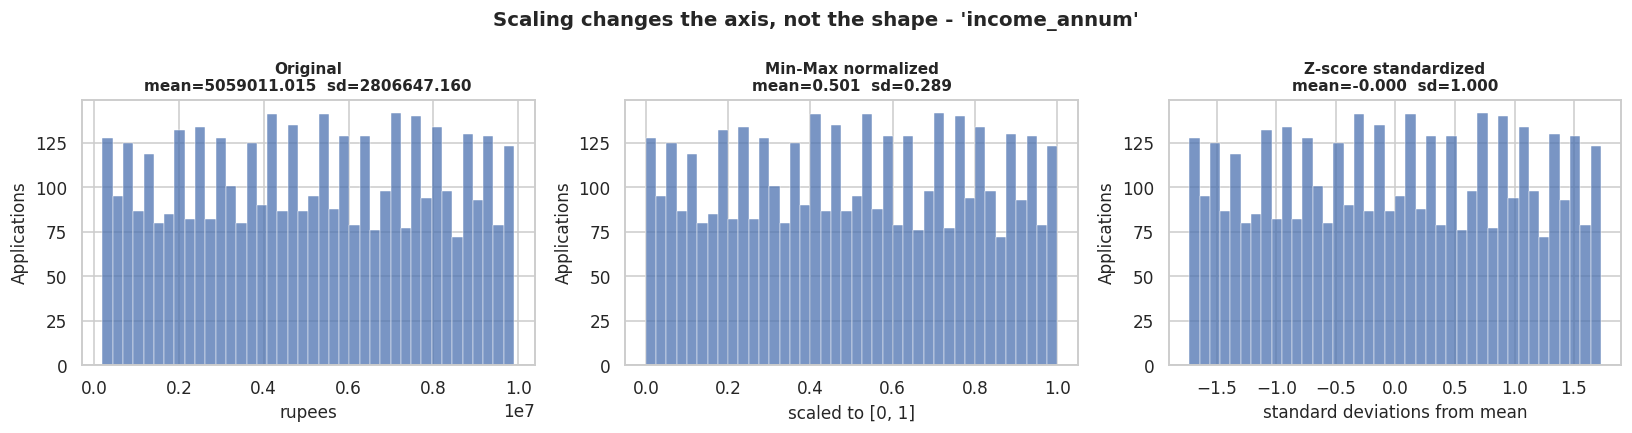

In [69]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (label, series, xlabel) in zip(axes, [
    ("Original",             df_eda[demo],                      "rupees"),
    ("Min-Max normalized",   df_scaled[f"{demo}__minmax"],      "scaled to [0, 1]"),
    ("Z-score standardized", df_scaled[f"{demo}__zscore"],      "standard deviations from mean"),
]):
    sns.histplot(series, bins=40, ax=ax, color="#4C72B0", edgecolor="white", linewidth=0.3)
    ax.set_title(f"{label}\nmean={series.mean():.3f}  sd={series.std():.3f}", fontsize=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Applications")
fig.suptitle(f"Scaling changes the axis, not the shape - '{demo}'",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### Observation

The three histograms are **identical in shape**. Only the x-axis changes.

### Interpretation

That identity is the point. Scaling makes features *comparable in magnitude* so that no feature
dominates a distance calculation through its units alone. It does not make a distribution more
normal, does not reduce skew, and does not alter any relationship in the data.

### Decision

`df_scaled` is a **technique demonstration and a prepared artefact**, not the basis of any
analysis in this notebook — every EDA section below uses the original units, because
"median income 5,000,000" is interpretable and "median income 0.49" is not.

**Critical note for the future pipeline:** the min and max used above were computed from the
**entire** dataset. In a real modelling pipeline that is a leakage bug — the scaler must be
fitted on the training split only, and the *training* parameters applied to the test split.
Full explanation in Section 41.

## 30. Descriptive Statistics

### Why are we doing this?

Descriptive statistics are the numerical backbone of every claim made later. Each one answers a
different question:

| Statistic | Question it answers |
|---|---|
| **Mean** | Where is the arithmetic centre? (sensitive to extremes) |
| **Median** | What does the *typical* applicant look like? (robust) |
| **Mode** | Which single value occurs most often? |
| **Min / Max / Range** | What are the boundaries of the data? |
| **Variance / Std Dev** | How spread out is the data around the mean? |
| **Quartiles / IQR** | How spread out is the middle half? (robust) |

### Why compute the same things two ways?

We use both Python's `statistics` module and Pandas. The `statistics` module operates on plain
Python sequences and makes each definition explicit; Pandas is vectorised and handles whole
dataframes. Computing both and comparing serves as a **cross-check** — and surfaces one real
definitional difference, examined below.

In [70]:
def describe_column(series, name=None):
    '''Full descriptive profile of one numeric column, computed with pandas.'''
    s = series.dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    return {
        "Feature"  : name or series.name,
        "Count"    : int(s.count()),
        "Mean"     : s.mean(),
        "Median"   : s.median(),
        "Mode"     : s.mode().iloc[0] if not s.mode().empty else np.nan,
        "Min"      : s.min(),
        "Max"      : s.max(),
        "Range"    : s.max() - s.min(),
        "Variance" : s.var(),
        "Std Dev"  : s.std(),
        "Q1"       : q1,
        "Q3"       : q3,
        "IQR"      : q3 - q1,
        "Skewness" : s.skew(),
    }

ALL_ANALYSIS_FEATURES = NUMERIC_FEATURES + ENGINEERED_FEATURES
descriptive_stats = pd.DataFrame([describe_column(df_eda[c]) for c in ALL_ANALYSIS_FEATURES])
descriptive_stats.round(3)

,Feature,Count,Mean,Median,Mode,Min,Max,Range,Variance,Std Dev,Q1,Q3,IQR,Skewness
0,no_of_dependents,4269,2.4990,3.0000,4.0000,0.0000,5.0000,5.0000,2.8760,1.6960,1.0000,4.0000,3.0000,-0.0180
1,income_annum,4269,"5,059,011.0150","5,100,000.0000","7,000,000.0000","200,000.0000","9,900,000.0000","9,700,000.0000","7,877,268,281,743.7451","2,806,647.1600","2,700,000.0000","7,500,000.0000","4,800,000.0000",-0.0130
2,loan_amount,4269,"15,132,122.7740","14,500,000.0000","10,600,000.0000","300,000.0000","39,500,000.0000","39,200,000.0000","81,774,888,933,380.1250","9,042,946.9160","7,700,000.0000","21,500,000.0000","13,800,000.0000",0.3090
3,loan_term,4269,10.9000,10.0000,6.0000,2.0000,20.0000,18.0000,32.5950,5.7090,6.0000,16.0000,10.0000,0.0360
4,cibil_score,4269,599.9360,600.0000,348.0000,300.0000,900.0000,600.0000,"29,732.2430",172.4300,453.0000,748.0000,295.0000,-0.0090
5,residential_assets_value,4269,"7,510,330.2880","5,700,000.0000","400,000.0000",0.0000,"29,100,000.0000","29,100,000.0000","41,940,804,694,070.7500","6,476,172.0710","2,200,000.0000","11,300,000.0000","9,100,000.0000",0.9840
6,commercial_assets_value,4269,"4,973,436.4020","3,700,000.0000",0.0000,0.0000,"19,400,000.0000","19,400,000.0000","19,258,722,513,585.5430","4,388,476.1040","1,300,000.0000","7,600,000.0000","6,300,000.0000",0.9580
7,luxury_assets_value,4269,"15,127,272.7270","14,600,000.0000","2,900,000.0000","300,000.0000","39,200,000.0000","38,900,000.0000","82,874,340,546,987.7812","9,103,534.5080","7,500,000.0000","21,700,000.0000","14,200,000.0000",0.3220
8,bank_asset_value,4269,"4,977,465.4490","4,600,000.0000","1,400,000.0000",0.0000,"14,700,000.0000","14,700,000.0000","10,560,569,863,203.7930","3,249,703.0420","2,300,000.0000","7,100,000.0000","4,800,000.0000",0.5610
9,total_assets,4269,"32,588,504.8660","31,500,000.0000","39,000,000.0000","500,000.0000","90,700,000.0000","90,200,000.0000","379,231,884,917,534.3125","19,473,876.9870","16,300,000.0000","47,200,000.0000","30,900,000.0000",0.2990


In [71]:
# Cross-check: the statistics module vs pandas, on one representative column.
check_col = "cibil_score"
values = df_eda[check_col].dropna().tolist()

print(f"Cross-check on '{check_col}' ({len(values):,} values)")
print("=" * 72)
print(f"{'Statistic':<22}{'statistics module':>22}{'pandas':>22}")
print("-" * 72)
print(f"{'mean':<22}{statistics.mean(values):>22,.4f}{df_eda[check_col].mean():>22,.4f}")
print(f"{'median':<22}{statistics.median(values):>22,.4f}{df_eda[check_col].median():>22,.4f}")
print(f"{'mode':<22}{statistics.mode(values):>22,.4f}{df_eda[check_col].mode().iloc[0]:>22,.4f}")
print(f"{'stdev (sample)':<22}{statistics.stdev(values):>22,.4f}{df_eda[check_col].std():>22,.4f}")
print(f"{'variance (sample)':<22}{statistics.variance(values):>22,.4f}{df_eda[check_col].var():>22,.4f}")
print(f"{'pstdev (population)':<22}{statistics.pstdev(values):>22,.4f}{df_eda[check_col].std(ddof=0):>22,.4f}")
print("-" * 72)
print('''
The two agree throughout, which validates both. The one thing worth understanding is
the sample/population distinction:

  statistics.stdev  and pandas .std()          divide by (n - 1)  [sample]
  statistics.pstdev and pandas .std(ddof=0)    divide by  n       [population]

Sample formulas (n-1) are the right default when the data is a SAMPLE from a larger
population - which these 4,269 applications are, relative to all applications ABC
Bank will ever receive. Both libraries default to the sample version, which is why
their defaults agree.
''')

Cross-check on 'cibil_score' (4,269 values)
Statistic                  statistics module                pandas
------------------------------------------------------------------------
mean                                599.9361              599.9361
median                              600.0000              600.0000
mode                                348.0000              348.0000
stdev (sample)                      172.4304              172.4304
variance (sample)                29,732.2431           29,732.2431
pstdev (population)                 172.4102              172.4102
------------------------------------------------------------------------

The two agree throughout, which validates both. The one thing worth understanding is
the sample/population distinction:

  statistics.stdev  and pandas .std()          divide by (n - 1)  [sample]
  statistics.pstdev and pandas .std(ddof=0)    divide by  n       [population]

Sample formulas (n-1) are the right default when the data is a S

In [72]:
print("Categorical features - descriptive summary")
print("=" * 60)
for c in CATEGORICAL_FEATURES + [TARGET]:
    s = df_eda[c]
    vc = s.value_counts()
    print(f"\n{c}")
    print(f"  Distinct categories : {s.nunique()}")
    print(f"  Mode (most frequent): {s.mode().iloc[0]!r}  ({vc.iloc[0]:,} = {vc.iloc[0]/len(s)*100:.2f}%)")
    for v, n in vc.items():
        print(f"      {str(v):<16} {n:>6,}  {n/len(s)*100:6.2f}%")

Categorical features - descriptive summary

education
  Distinct categories : 2
  Mode (most frequent): 'Graduate'  (2,145 = 50.25%)
      Graduate          2,145   50.25%
      Not Graduate      2,124   49.75%

self_employed
  Distinct categories : 2
  Mode (most frequent): 'Yes'  (2,150 = 50.36%)
      Yes               2,150   50.36%
      No                2,119   49.64%

loan_status
  Distinct categories : 2
  Mode (most frequent): 'Approved'  (2,656 = 62.22%)
      Approved          2,656   62.22%
      Rejected          1,613   37.78%


### Interpretation — the typical applicant

Reading the median row across the table gives a portrait of the typical ABC Bank applicant that
is robust to the wealthy tail:

- Applies for a loan several times their annual income.
- Holds meaningful assets across residential, luxury, commercial and bank categories.
- Has a CIBIL score near the middle of the 300–900 range.
- Has two or three dependents.

Two observations worth flagging:

1. For `income_annum`, `cibil_score` and `loan_term`, **mean ≈ median** — confirming the
   symmetric shape found in Section 25.
2. For the asset columns, **mean > median** — the right skew, again.

The **mode** is the least informative statistic here: for a near-continuous column like
`income_annum`, the most frequent value is essentially an artefact of how many applicants
happen to share a round number. The mode earns its keep on categorical variables, where it is
the only meaningful measure of centre.

## 31. Univariate Analysis

### Why are we doing this?

Before asking how variables relate to each other, we need to know what each one looks like on
its own — its centre, spread, shape and any concentration.

### Numerical features

### Question

What do the three financially central variables — annual income, requested loan amount, and
credit score — look like across ABC Bank's applicant base?

### Why this chart?

A histogram shows the full distribution shape; a boxplot beneath it, sharing the x-axis, adds
the quartile structure and marks any flagged extremes. Pairing them means neither the shape nor
the summary is lost.

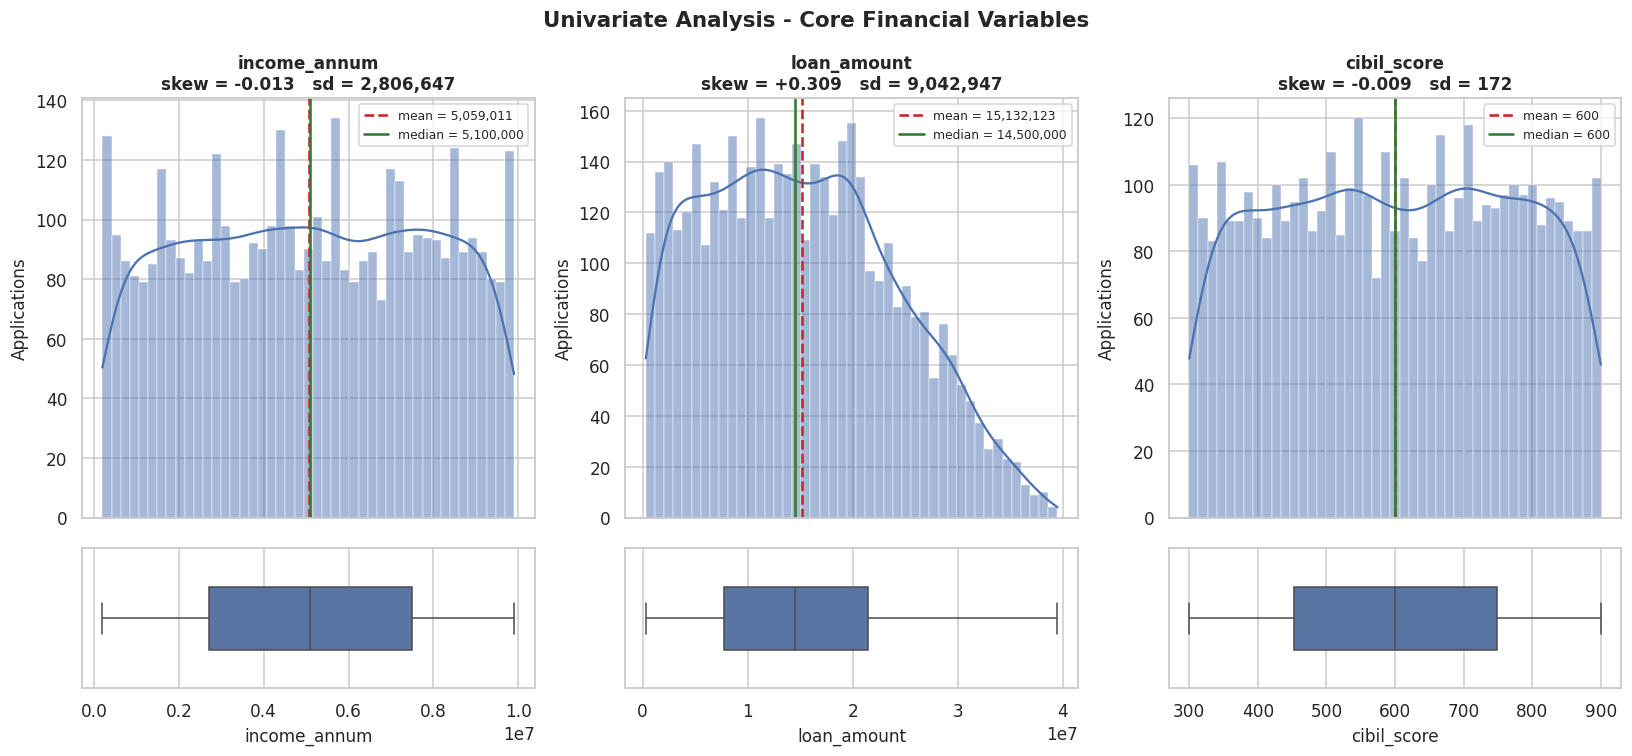

In [73]:
# --- REQUIRED PLOTS: HISTOGRAM + BOX PLOT ---
focus_cols = ["income_annum", "loan_amount", "cibil_score"]
fig, axes = plt.subplots(2, 3, figsize=(15, 7), height_ratios=[3, 1], sharex="col")

for j, c in enumerate(focus_cols):
    s = df_eda[c]
    sns.histplot(s, bins=45, kde=True, ax=axes[0, j], color="#4C72B0",
                 edgecolor="white", linewidth=0.3)
    axes[0, j].axvline(s.mean(),   color="#C62828", ls="--", lw=1.7, label=f"mean = {s.mean():,.0f}")
    axes[0, j].axvline(s.median(), color="#2E7D32", ls="-",  lw=1.7, label=f"median = {s.median():,.0f}")
    axes[0, j].set_title(f"{c}\nskew = {s.skew():+.3f}   sd = {s.std():,.0f}", fontsize=11)
    axes[0, j].set_ylabel("Applications")
    axes[0, j].set_xlabel("")
    axes[0, j].legend(fontsize=8)

    sns.boxplot(x=s, ax=axes[1, j], color="#4C72B0", width=0.45,
                flierprops={"marker": "o", "markersize": 3, "markerfacecolor": "#C62828"})
    axes[1, j].set_xlabel(c)

fig.suptitle("Univariate Analysis - Core Financial Variables", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Observation

- **`income_annum`** — spread almost evenly across roughly 200,000 to 9,900,000, with no peak
  and no tail. Mean and median nearly coincide.
- **`loan_amount`** — broad, mildly right-leaning, covering roughly 300,000 to 39,500,000.
- **`cibil_score`** — near-flat across the entire valid 300–900 range.

### Interpretation

For **`income_annum` and `cibil_score` the distributions are close to uniform**, and that is a
finding in its own right. Real applicant income is strongly right-skewed, and real CIBIL
distributions cluster heavily in the 700s because most people with credit histories pay on time.
A flat spread across the whole legal range in both variables is the signature of **synthetic
data generation**.

`loan_amount` shows a slight right lean and is the most naturally-shaped of the three.

### Limitation

This shape means the dataset does **not** represent a real applicant population's demographics.
Conclusions about *methodology* transfer; conclusions about "what ABC Bank's applicants look
like" do not, and no number in this notebook should be quoted as a real-world statistic. This
constraint is carried into Sections 40 and 43.

### Question

What is the categorical profile of the applicant base — education, employment type, dependents
and loan term?

### Why this chart?

Count plots. For a small number of unordered categories, bar length on a common baseline is the
most accurately-read encoding available.

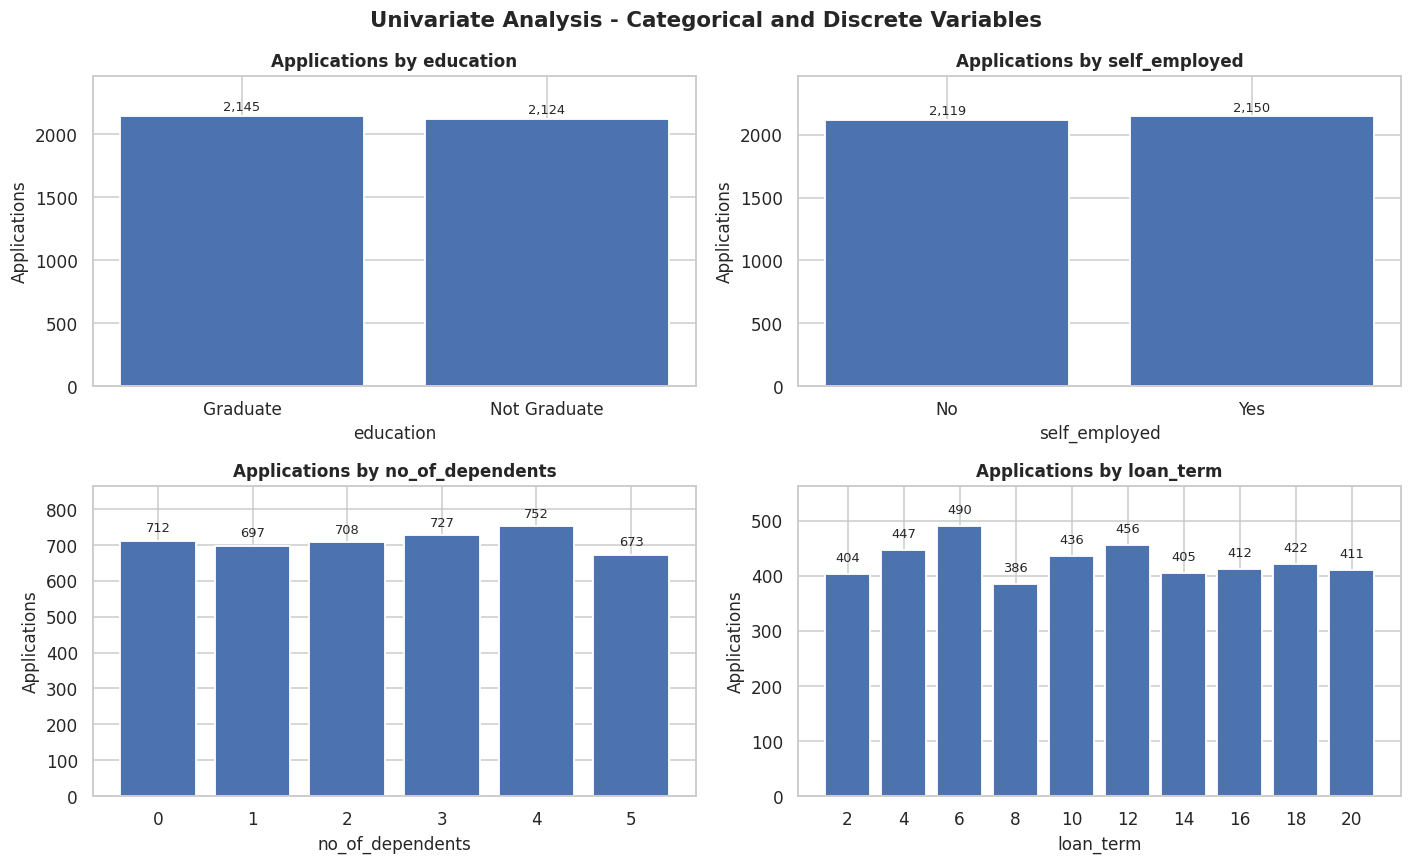

In [74]:
# --- REQUIRED PLOT: BAR PLOT ---
cat_plot_cols = ["education", "self_employed", "no_of_dependents", "loan_term"]
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for ax, c in zip(axes.flat, cat_plot_cols):
    vc = df_eda[c].value_counts().sort_index()
    bars = ax.bar([str(i) for i in vc.index], vc.values,
                  color="#4C72B0", edgecolor="white", linewidth=1.2)
    for b, n in zip(bars, vc.values):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + len(df_eda)*0.004,
                f"{n:,}", ha="center", va="bottom", fontsize=8.5)
    ax.set_title(f"Applications by {c}", fontsize=11)
    ax.set_xlabel(c)
    ax.set_ylabel("Applications")
    ax.set_ylim(0, vc.max() * 1.15)

fig.suptitle("Univariate Analysis - Categorical and Discrete Variables",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Observation

All four variables are close to **evenly distributed**: education splits roughly evenly between
Graduate and Not Graduate; self-employment splits roughly evenly between Yes and No; each
dependent count from 0 to 5 holds a comparable share; and each of the ten loan terms holds
roughly a tenth of applications.

### Interpretation

Balanced categories are analytically convenient — every group has enough observations for a
stable approval-rate estimate, with no tiny category whose rate would swing on a handful of
cases.

They are also, once again, **not realistic**. A real bank's applicant pool is not split 50/50
between graduates and non-graduates, and loan terms cluster heavily around a few standard
tenures rather than spreading evenly across ten. This is further evidence of synthetic
generation.

### Limitation

Because the categories are balanced by construction rather than by nature, their *frequencies*
carry no market insight. What remains meaningful is the **comparison of approval rates between**
categories, which Section 32 examines.

## 32. Bivariate Analysis

### Why are we doing this?

This is the heart of the business question: **which applicant characteristics differ between
approved and rejected applications?**

### Approach

- **Numerical vs target** — compare distributions (mean, median, spread, shape) between the two
  outcome groups.
- **Categorical vs target** — compare approval *rates* between categories.

### An important caution up front

Any difference found here is an **association**, not a cause. Both classes of explanation
remain open at every step: the bank may have decided *because of* the variable, or the variable
may simply travel alongside something else that drove the decision.

### Question

Do approved and rejected applicants differ on the core numerical variables?

### Why this chart?

Boxplots split by outcome put the two distributions side by side on a shared axis, so the
comparison is direct rather than remembered across two separate plots.

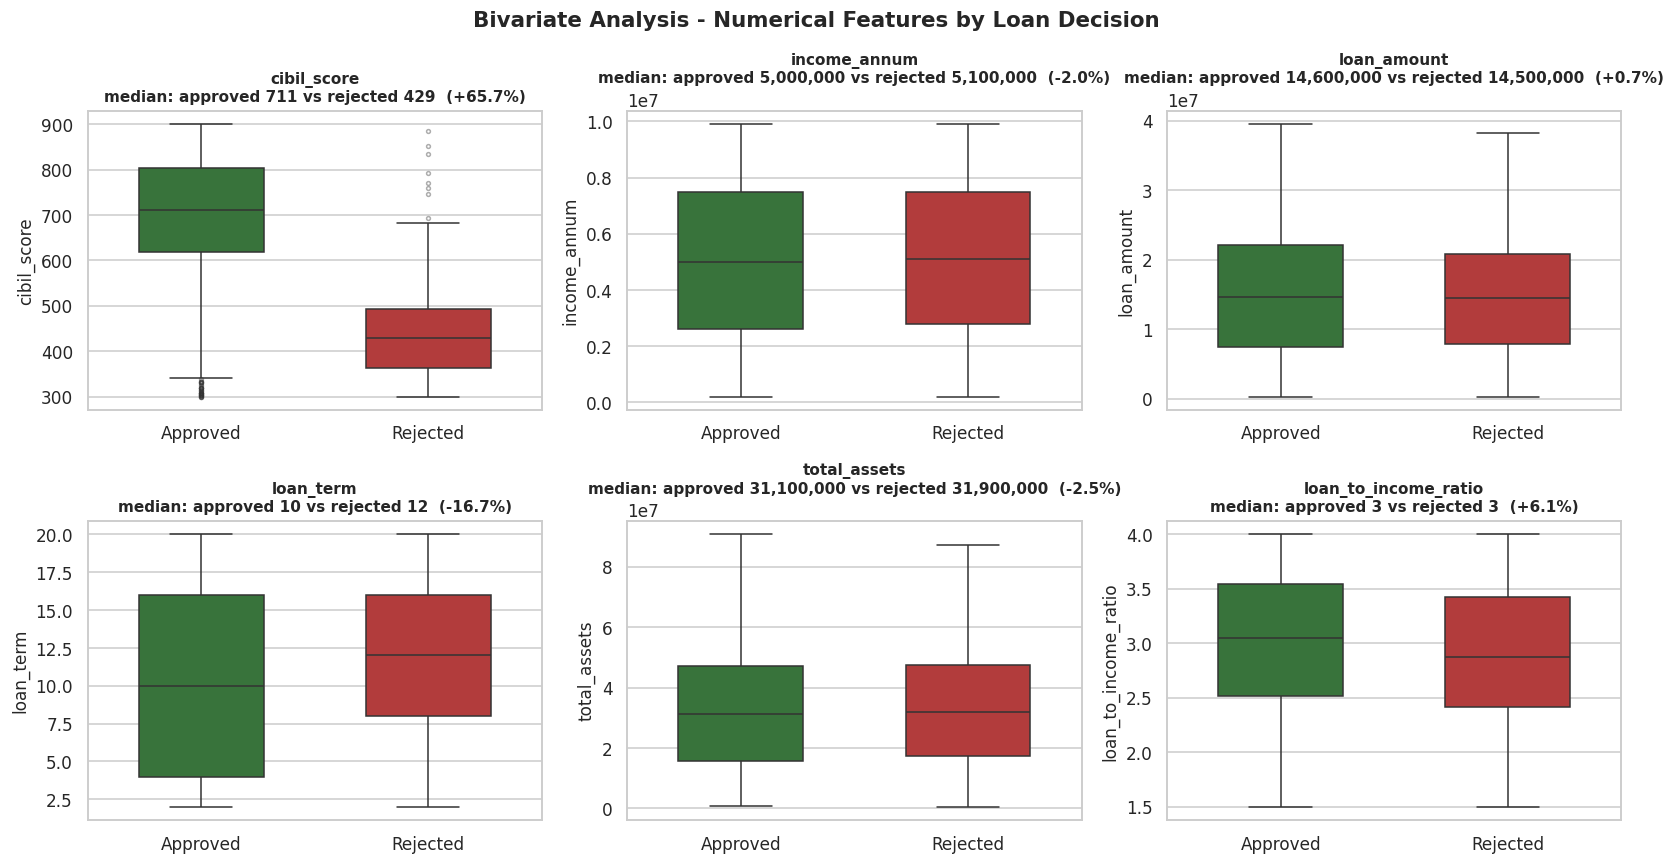

In [75]:
# --- REQUIRED PLOT: BOX PLOT (bivariate) ---
biv_cols = ["cibil_score", "income_annum", "loan_amount", "loan_term",
            "total_assets", "loan_to_income_ratio"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, c in zip(axes.flat, biv_cols):
    sns.boxplot(data=df_eda, x=TARGET, y=c, ax=ax, hue=TARGET,
                palette=TARGET_PALETTE, order=["Approved", "Rejected"], legend=False,
                width=0.55, flierprops={"marker": "o", "markersize": 2.5, "alpha": 0.4})
    med_a = df_eda.loc[df_eda[TARGET] == "Approved", c].median()
    med_r = df_eda.loc[df_eda[TARGET] == "Rejected", c].median()
    gap = (med_a - med_r) / med_r * 100 if med_r else np.nan
    ax.set_title(f"{c}\nmedian: approved {med_a:,.0f} vs rejected {med_r:,.0f}  ({gap:+.1f}%)",
                 fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel(c)

fig.suptitle("Bivariate Analysis - Numerical Features by Loan Decision",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [76]:
# The numbers behind the plot: full group comparison with an effect size.
def cohens_d(a, b):
    '''Standardised mean difference using the pooled standard deviation.

    Reports the gap in standard-deviation units, so features measured in
    rupees and features measured in score points become comparable.
    '''
    na, nb = len(a), len(b)
    if na < 2 or nb < 2:
        return np.nan
    pooled_var = ((na - 1) * a.var(ddof=1) + (nb - 1) * b.var(ddof=1)) / (na + nb - 2)
    return (a.mean() - b.mean()) / np.sqrt(pooled_var) if pooled_var > 0 else np.nan


def interpret_d(d):
    a = abs(d)
    if np.isnan(a): return "n/a"
    if a < 0.2:  return "negligible"
    if a < 0.5:  return "small"
    if a < 0.8:  return "medium"
    return "large"


group_stats = []
for c in ALL_ANALYSIS_FEATURES:
    a = df_eda.loc[df_eda[TARGET] == "Approved", c].dropna()
    r = df_eda.loc[df_eda[TARGET] == "Rejected", c].dropna()
    d = cohens_d(a, r)
    group_stats.append({
        "Feature"          : c,
        "Mean (Approved)"  : a.mean(),
        "Mean (Rejected)"  : r.mean(),
        "Median (Approved)": a.median(),
        "Median (Rejected)": r.median(),
        "SD (Approved)"    : a.std(),
        "SD (Rejected)"    : r.std(),
        "Cohen's d"        : d,
        "Effect size"      : interpret_d(d),
    })
group_stats_df = pd.DataFrame(group_stats).sort_values("Cohen's d", key=abs, ascending=False)
group_stats_df.round(3).reset_index(drop=True)

,Feature,Mean (Approved),Mean (Rejected),Median (Approved),Median (Rejected),SD (Approved),SD (Rejected),Cohen's d,Effect size
0,cibil_score,703.4620,429.4680,711.0000,429.0000,125.2490,78.4020,2.4930,large
1,repayment_to_income_ratio,0.4920,0.3420,0.2920,0.2500,0.4540,0.2600,0.3840,small
2,annual_repayment_proxy,"2,448,845.0950","1,776,494.3930","1,428,174.6030","1,240,000.0000","2,935,628.5260","1,841,007.4650",0.2610,small
3,loan_term,10.3980,11.7280,10.0000,12.0000,5.8800,5.3160,-0.2350,small
4,loan_to_income_ratio,3.0250,2.9180,3.0500,2.8750,0.5930,0.5940,0.1800,negligible
5,loan_to_asset_ratio,0.4880,0.4780,0.4710,0.4550,0.1390,0.1540,0.0710,negligible
6,no_of_dependents,2.4750,2.5380,2.5000,3.0000,1.6950,1.6970,-0.0370,negligible
7,loan_amount,"15,245,117.5160","14,946,063.2360","14,600,000.0000","14,500,000.0000","9,221,066.2780","8,741,389.5070",0.0330,negligible
8,luxury_assets_value,"15,018,157.8590","15,306,943.5830","14,400,000.0000","14,800,000.0000","9,153,954.0100","9,019,849.9820",-0.0320,negligible
9,residential_assets_value,"7,434,864.4580","7,634,593.9240","5,500,000.0000","5,900,000.0000","6,476,457.4830","6,475,793.3330",-0.0310,negligible


### Observation

The effect-size ranking is unambiguous:

- **`cibil_score`** — a **large** effect. Approved applicants average around 703; rejected
  applicants around 429. That is a gap of roughly 274 points, and Cohen's *d* well above 2 —
  an exceptionally large separation.
- **`loan_term`** — a **small** effect, in the direction that shorter terms are associated with
  approval.
- **Everything else** — including income, loan amount, and all asset values — **negligible**.
  Approved and rejected applicants have nearly identical medians on every one of them.

### Interpretation

One variable dominates. On the evidence in this file, the recorded decision **appears
associated** overwhelmingly with the credit bureau score, with a secondary and much weaker
pattern involving loan term. Income, loan size and wealth show no meaningful association at all.

That is a genuinely surprising result for a lending dataset and it deserves to be stated as
surprising: an underwriter would normally weigh affordability heavily, yet applicants with
identical incomes and identical loan requests received opposite decisions depending almost
entirely on their score.

### Limitation

`cibil_score` being strongly associated with approval **does not mean a high score causes
approval**. Two readings remain consistent with this evidence:

1. The bank applies a score threshold as policy — the score drives the decision directly.
2. The score is itself a summary of repayment history, and the bank is really responding to
   that history, which the score merely represents.

More importantly, we observe only **recorded decisions**. We never see what would have happened
to rejected applicants had they been approved, so nothing here speaks to whether the threshold
is *correct*.

### Question

Do approval rates differ across the categorical variables — education, employment type,
dependents, loan term and the credit bands?

### Why this chart?

A bar chart of *approval rate* rather than count. Comparing raw counts across categories of
different sizes is misleading; the rate normalises for group size, and the overall 62% baseline
gives every bar a reference.

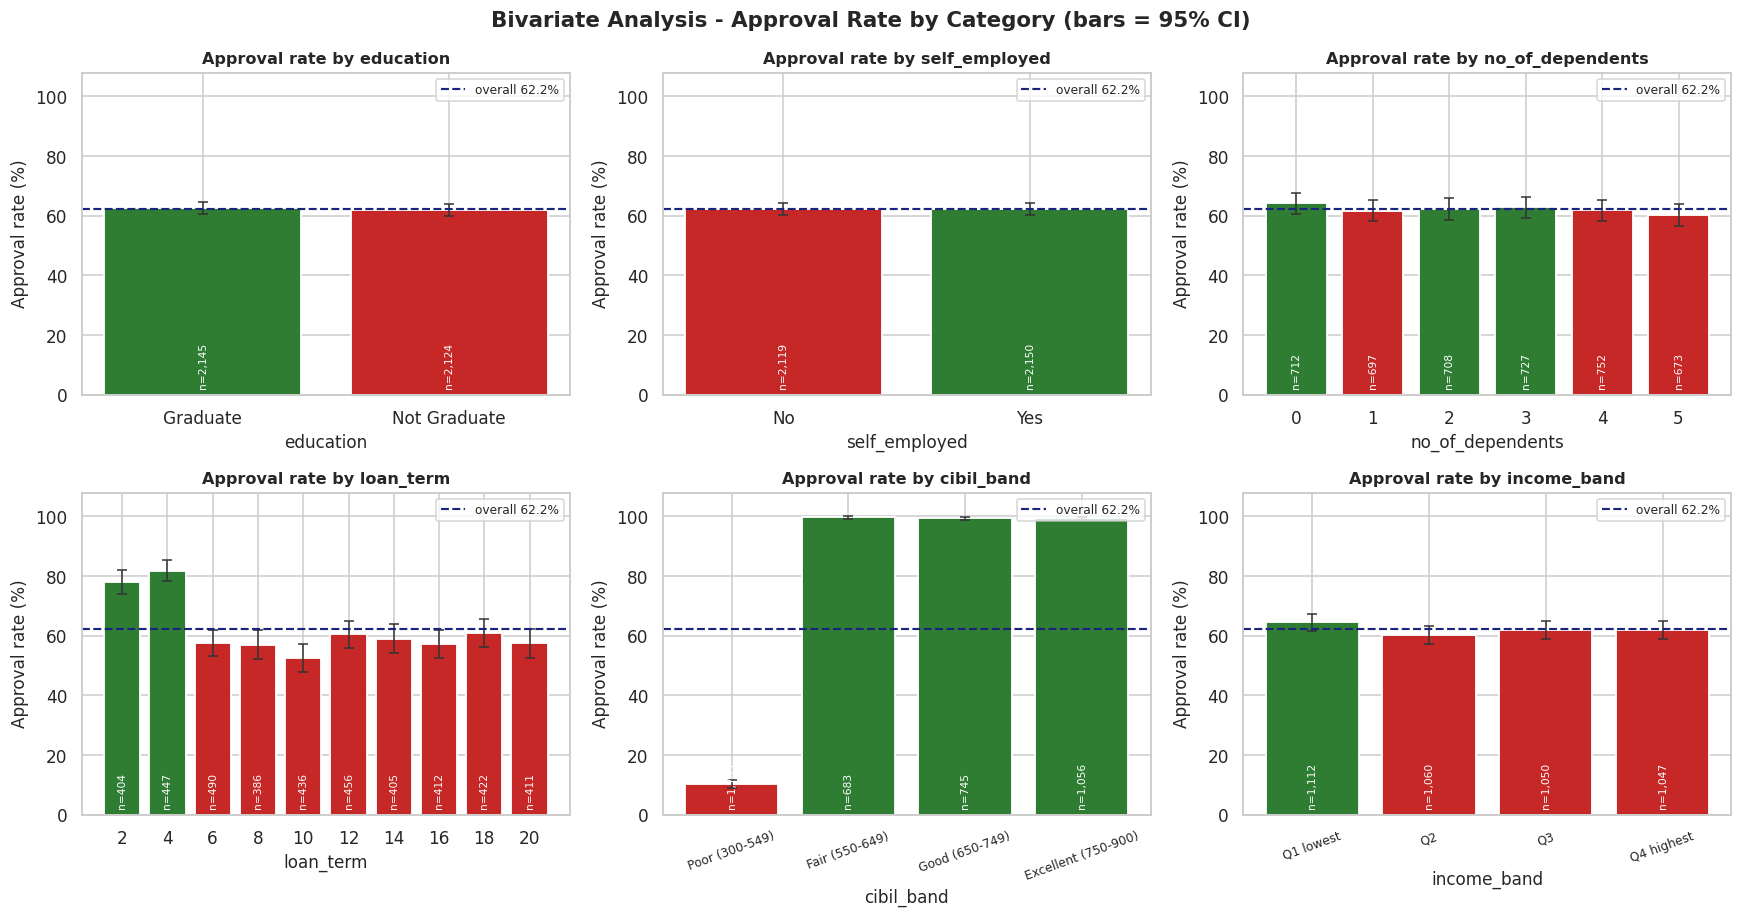

In [77]:
# --- REQUIRED PLOT: BAR PLOT (approval rate by category) ---
rate_cols = ["education", "self_employed", "no_of_dependents",
             "loan_term", "cibil_band", "income_band"]
fig, axes = plt.subplots(2, 3, figsize=(16, 8.5))
overall_rate = df_eda[TARGET_BINARY].mean()

for ax, c in zip(axes.flat, rate_cols):
    tbl = approval_rate_by(df_eda, c)
    x = [str(i) for i in tbl.index]
    colors = [COLOR_APPROVED if v >= overall_rate else COLOR_REJECTED
              for v in tbl["Approval rate"]]
    bars = ax.bar(x, tbl["Approval rate"] * 100, color=colors,
                  edgecolor="white", linewidth=1.2)
    ax.errorbar(x, tbl["Approval rate"] * 100,
                yerr=[(tbl["Approval rate"] - tbl["95% CI low"]) * 100,
                      (tbl["95% CI high"] - tbl["Approval rate"]) * 100],
                fmt="none", ecolor="#333333", capsize=3, lw=1)
    ax.axhline(overall_rate * 100, color="#1A237E", ls="--", lw=1.4,
               label=f"overall {overall_rate*100:.1f}%")
    for b, v, n in zip(bars, tbl["Approval rate"], tbl["Applications"]):
        ax.text(b.get_x() + b.get_width()/2, 2, f"n={n:,}",
                ha="center", va="bottom", fontsize=7, color="white", rotation=90)
    ax.set_title(f"Approval rate by {c}", fontsize=10.5)
    ax.set_ylabel("Approval rate (%)")
    ax.set_xlabel(c)
    ax.set_ylim(0, 108)
    ax.legend(fontsize=8, loc="upper right")
    if c in ("cibil_band", "income_band"):
        ax.tick_params(axis="x", rotation=20, labelsize=8)

fig.suptitle("Bivariate Analysis - Approval Rate by Category (bars = 95% CI)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [78]:
for c in ["education", "self_employed", "no_of_dependents", "loan_term", "cibil_band"]:
    tbl = approval_rate_by(df_eda, c)
    spread = (tbl["Approval rate"].max() - tbl["Approval rate"].min()) * 100
    print(f"\n--- {c} --- (spread between best and worst category: {spread:.2f} pp)")
    print(tbl[["Applications", "Approval rate", "95% CI low", "95% CI high"]].round(4).to_string())


--- education --- (spread between best and worst category: 0.51 pp)
              Applications  Approval rate  95% CI low  95% CI high
education                                                         
Graduate              2145         0.6247      0.6042       0.6452
Not Graduate          2124         0.6196      0.5989       0.6402

--- self_employed --- (spread between best and worst category: 0.03 pp)
               Applications  Approval rate  95% CI low  95% CI high
self_employed                                                      
No                     2119         0.6220      0.6013       0.6426
Yes                    2150         0.6223      0.6018       0.6428

--- no_of_dependents --- (spread between best and worst category: 3.86 pp)
                  Applications  Approval rate  95% CI low  95% CI high
no_of_dependents                                                      
0                          712         0.6419      0.6066       0.6771
1                          69

### Observation

- **`cibil_band`** — approval swings from roughly **10%** in the Poor band to roughly **99%**
  in every band above it. A spread of nearly 90 percentage points.
- **`loan_term`** — terms of 2 and 4 show approval rates around 78–82%, well above the 62%
  baseline; terms of 6 and above sit near or below it. A spread of roughly 29 points.
- **`education`**, **`self_employed`**, **`no_of_dependents`** — every category sits within a
  couple of points of the 62% baseline, and the 95% confidence intervals overlap the baseline
  in every case.

### Interpretation

The credit band separates the outcome almost completely. Loan term shows a real but far weaker
pattern. Education, employment type and dependents show **no** meaningful association — their
confidence intervals overlapping the overall rate is exactly what "no detectable difference"
looks like, and this is the correct way to report a null result rather than reading noise as
signal.

The near-zero association with education and self-employment is worth dwelling on for a second
reason: these are the two variables in this dataset most likely to raise fair-lending concerns.
Finding that neither is associated with the outcome is a **positive** finding for fairness,
discussed further in Section 41.

### Limitation

Confidence intervals here assume each application is independent, and they quantify sampling
variability only — they say nothing about bias in how the data was collected. The loan-term
pattern is also confounded, as Section 33 shows: it is concentrated almost entirely within one
credit band.

## 33. Multivariate Analysis

### Why are we doing this?

Bivariate analysis examines one variable at a time and can be misled by confounding. Section 32
found that shorter loan terms are associated with approval — but *is that a real effect, or is
it an artefact of who applies for short terms?* Only by looking at the variables together can
we tell.

### Question

Does the loan-term pattern hold **within** credit bands, or does it disappear once we control
for the credit score?

### Why this chart?

A heatmap of approval rate across the cibil × loan-term grid. Colour encodes the rate, so
holding one variable constant is as easy as reading along a row.

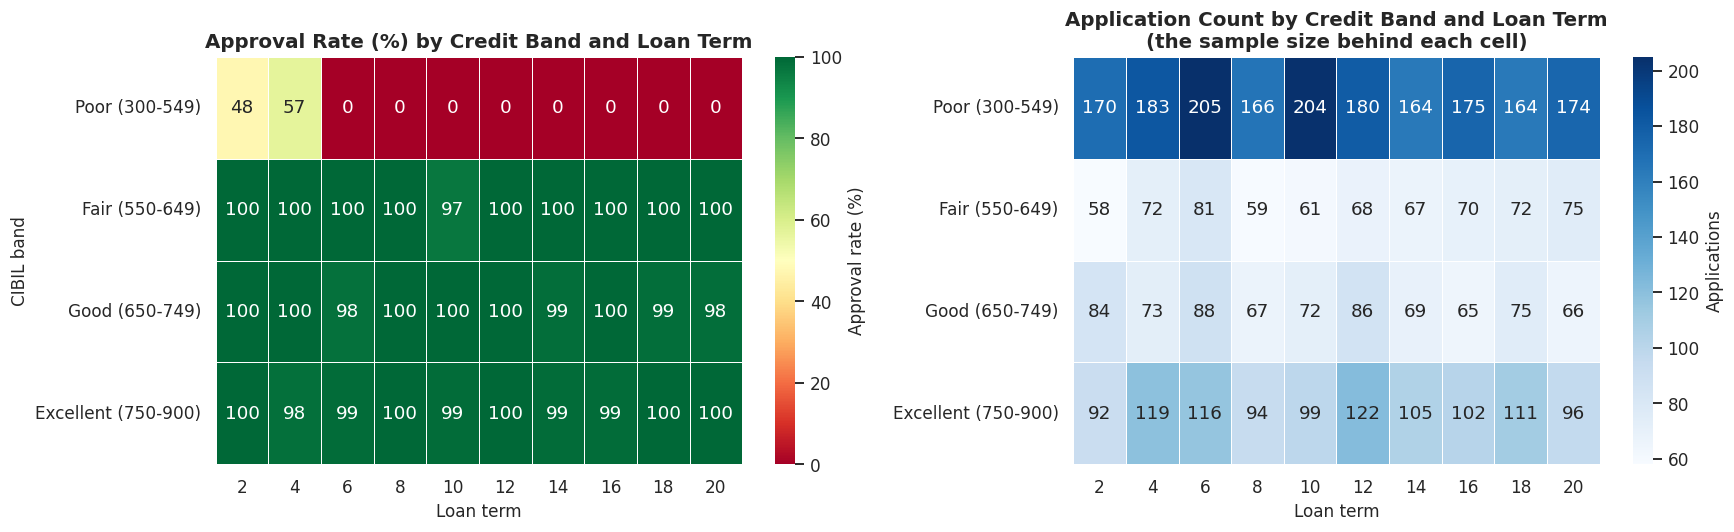

In [79]:
# --- REQUIRED PLOT: HEATMAP (grouped) ---
pivot_rate = df_eda.pivot_table(index="cibil_band", columns="loan_term",
                                values=TARGET_BINARY, aggfunc="mean", observed=True)
pivot_n = df_eda.pivot_table(index="cibil_band", columns="loan_term",
                             values=TARGET_BINARY, aggfunc="size", observed=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.heatmap(pivot_rate * 100, annot=True, fmt=".0f", cmap="RdYlGn", vmin=0, vmax=100,
            ax=axes[0], cbar_kws={"label": "Approval rate (%)"},
            linewidths=0.5, linecolor="white")
axes[0].set_title("Approval Rate (%) by Credit Band and Loan Term")
axes[0].set_xlabel("Loan term")
axes[0].set_ylabel("CIBIL band")

sns.heatmap(pivot_n, annot=True, fmt=",d", cmap="Blues",
            ax=axes[1], cbar_kws={"label": "Applications"},
            linewidths=0.5, linecolor="white")
axes[1].set_title("Application Count by Credit Band and Loan Term\n(the sample size behind each cell)")
axes[1].set_xlabel("Loan term")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

In [80]:
print("Does the loan-term effect survive when the credit band is held constant?\n")
for band in df_eda["cibil_band"].cat.categories:
    sub = df_eda[df_eda["cibil_band"] == band]
    if len(sub) < 30:
        continue
    by_term = sub.groupby("loan_term", observed=True)[TARGET_BINARY].agg(["mean", "size"])
    spread = (by_term["mean"].max() - by_term["mean"].min()) * 100
    print(f"{band:<22} n={len(sub):>5,}   overall {sub[TARGET_BINARY].mean()*100:5.1f}%   "
          f"spread across terms: {spread:5.1f} pp")

print("\nZooming into the Poor band, where the variation lives:")
poor = df_eda[df_eda["cibil_band"] == "Poor (300-549)"]
print(poor.groupby("loan_term", observed=True)[TARGET_BINARY]
        .agg(Applications="size", Approved="sum", Approval_rate="mean").round(4).to_string())

Does the loan-term effect survive when the credit band is held constant?

Poor (300-549)         n=1,785   overall  10.4%   spread across terms:  56.8 pp
Fair (550-649)         n=  683   overall  99.7%   spread across terms:   3.3 pp
Good (650-749)         n=  745   overall  99.3%   spread across terms:   2.3 pp
Excellent (750-900)    n=1,056   overall  99.4%   spread across terms:   1.7 pp

Zooming into the Poor band, where the variation lives:
           Applications  Approved  Approval_rate
loan_term                                       
2                   170        81         0.4765
4                   183       104         0.5683
6                   205         0         0.0000
8                   166         0         0.0000
10                  204         0         0.0000
12                  180         0         0.0000
14                  164         0         0.0000
16                  175         0         0.0000
18                  164         0         0.0000
20         

### Observation

The heatmap resolves the question decisively.

- In the **Fair, Good and Excellent** bands, approval is near 100% **at every loan term**. Term
  makes no difference there.
- In the **Poor (300–549)** band, approval is close to **zero at terms of 6 and above**, but
  jumps to roughly **48–57% at terms of 2 and 4**.

### Interpretation

**The loan-term association found in Section 32 was confounded.** Term has essentially no
relationship with approval on its own — its apparent effect came entirely from one pocket of
the data. The real structure is an **interaction**: loan term matters *only* for applicants
below the credit threshold.

Read as a decision policy, the pattern is coherent and commercially sensible:

1. If the credit score clears the threshold, approve — regardless of anything else.
2. If it does not, reject — **unless** the requested term is very short, in which case the
   application is considered. A short term limits how long the bank is exposed to a
   higher-risk borrower.

This is exactly the kind of structure that bivariate analysis alone would have reported wrongly,
and it is why multivariate analysis is not optional.

### Limitation

Even within the sub-550 short-term pocket, roughly half of applications are approved and half
rejected, and **no variable in this dataset explains which is which**. Whatever separates them —
underwriter judgement, documentation, a factor never recorded — is not in this file. That is a
data limitation, not a modelling opportunity, and it is the single most important caveat for
anyone planning to model this data.

### Question

How do income, loan amount and credit score interact in determining the outcome?

### Why these charts?

A scatter plot coloured by outcome shows where the two classes live in feature space; a pair
plot extends that to every pairwise combination of the core variables at once.

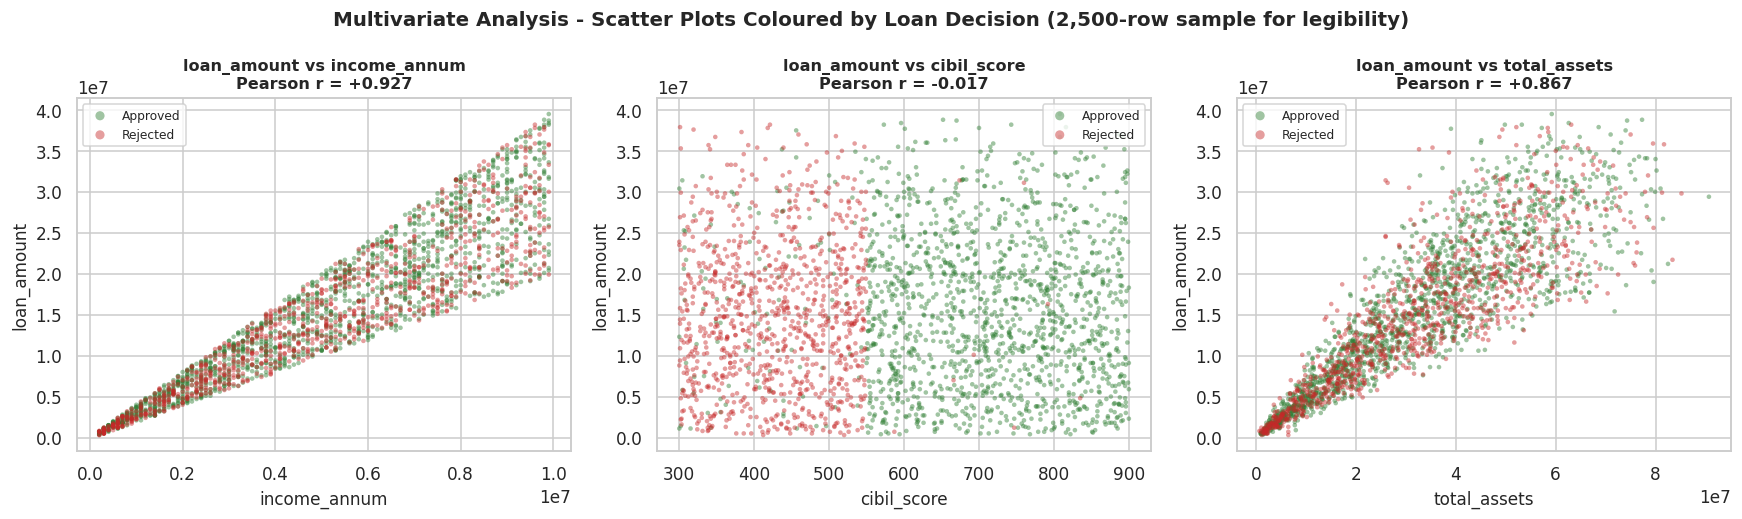

In [81]:
# --- REQUIRED PLOT: SCATTER PLOT ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
sample = df_eda.sample(n=min(2500, len(df_eda)), random_state=RANDOM_SEED)

pairs = [("income_annum", "loan_amount"),
         ("cibil_score", "loan_amount"),
         ("total_assets", "loan_amount")]
for ax, (x, y) in zip(axes, pairs):
    for status in ["Approved", "Rejected"]:
        sub = sample[sample[TARGET] == status]
        ax.scatter(sub[x], sub[y], s=9, alpha=0.45,
                   color=TARGET_PALETTE[status], label=status, edgecolors="none")
    r = df_eda[x].corr(df_eda[y])
    ax.set_title(f"{y} vs {x}\nPearson r = {r:+.3f}", fontsize=10.5)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.legend(fontsize=8, markerscale=2)

fig.suptitle("Multivariate Analysis - Scatter Plots Coloured by Loan Decision "
             "(2,500-row sample for legibility)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### Observation

- **`loan_amount` vs `income_annum`** — a tight, strongly positive linear band (r ≈ +0.93).
  Larger incomes come with proportionally larger loan requests. Approved and rejected points
  are **thoroughly intermixed** throughout the band.
- **`loan_amount` vs `cibil_score`** — no relationship between the two axes (r ≈ 0), but a
  **sharp vertical colour boundary**: red to the left of roughly 550, green to the right.
- **`loan_amount` vs `total_assets`** — positive and again fully intermixed by colour.

### Interpretation

The middle panel is the clearest single picture of the decision rule in this notebook. The
separation between approved and rejected is **vertical** — it depends on the x-axis
(`cibil_score`) and not at all on the y-axis (`loan_amount`). A near-vertical boundary in a
scatter plot is the visual definition of a threshold rule on one variable.

The left and right panels show the opposite: however strongly two financial variables move
together, the colours stay mixed, so neither separates the outcome.

### Limitation

**Correlation is not causation, and it is worth being concrete about why here.** The r ≈ +0.93
between income and loan amount does not mean higher income *causes* people to request larger
loans. At least three explanations fit equally well: applicants self-select loan sizes they
believe they can service; the bank's own product rules cap requests at a multiple of income; or
— since Section 22 suggests synthetic generation — the loan amount may simply have been
*generated* from income.

Note also the multicollinearity implication: two features correlated at 0.93 carry largely the
same information, which destabilises linear model coefficients (Section 34).

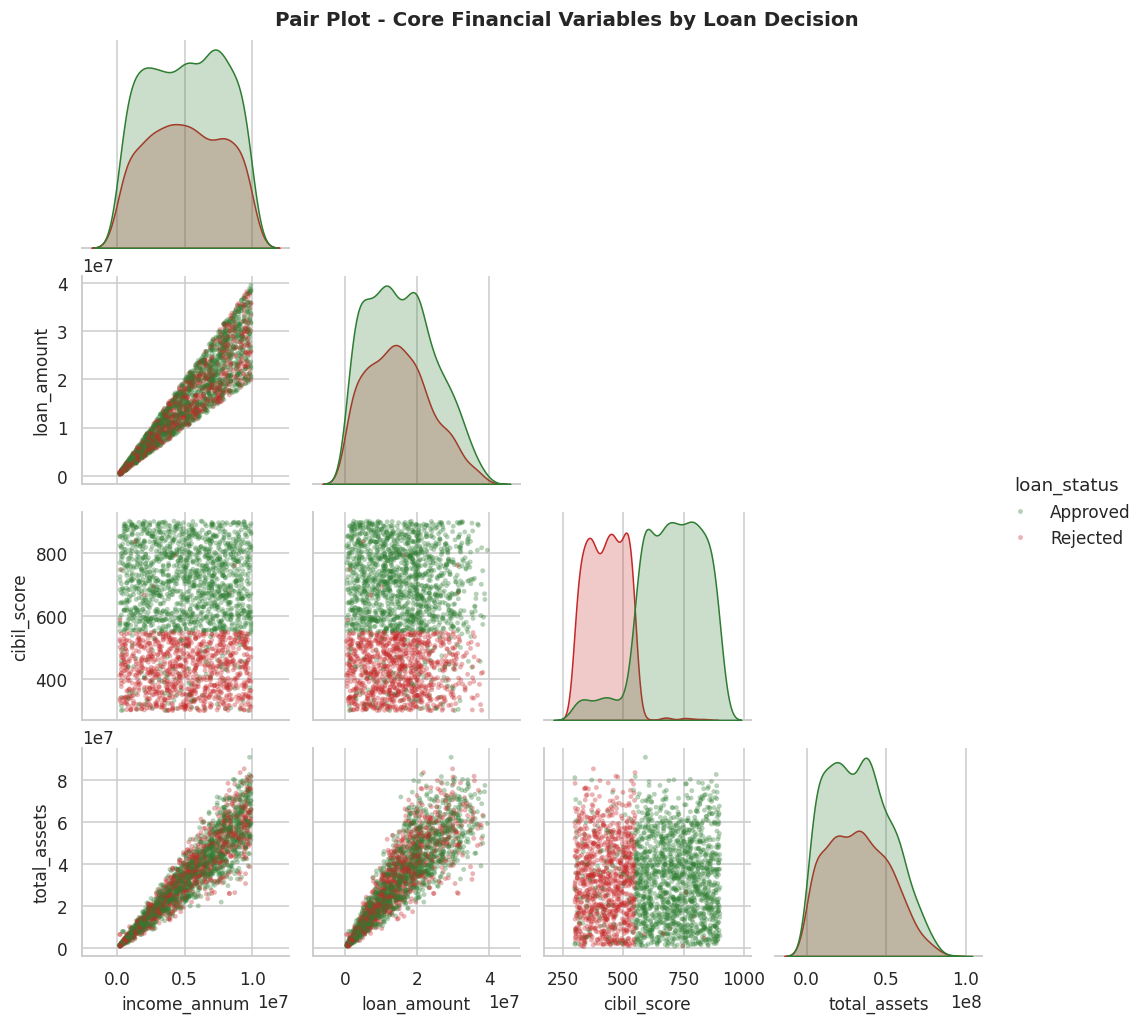

In [82]:
pair_cols = ["income_annum", "loan_amount", "cibil_score", "total_assets", TARGET]
g = sns.pairplot(sample[pair_cols], hue=TARGET, palette=TARGET_PALETTE,
                 diag_kind="kde", corner=True,
                 plot_kws={"s": 10, "alpha": 0.35, "edgecolor": "none"},
                 height=2.3)
g.figure.suptitle("Pair Plot - Core Financial Variables by Loan Decision",
                  y=1.01, fontsize=13, fontweight="bold")
plt.show()

### Observation

Reading the diagonal — the per-variable KDEs split by outcome — the approved and rejected curves
sit **almost exactly on top of one another** for income, loan amount and total assets. For
`cibil_score` they are **almost completely separated**, with only a small region of overlap.

### Interpretation

The pair plot delivers the same verdict from every angle at once: whichever pair of financial
variables you choose, the two outcome classes are inseparable — unless `cibil_score` is one of
the axes.

### Limitation

Pair plots are for a handful of variables; beyond about six they become unreadable, and the
2,500-row sample means very sparse regions may be under-represented. They also show only
*pairwise* structure — the cibil × loan-term interaction found above is invisible here, which
is why the heatmap was needed.

In [83]:
# Grouped multivariate summary - the numbers behind the visuals.
multi = (df_eda.groupby(["cibil_band", TARGET], observed=True)
         .agg(Applications=(ID_COL, "size"),
              Median_income=("income_annum", "median"),
              Median_loan=("loan_amount", "median"),
              Median_assets=("total_assets", "median"),
              Median_term=("loan_term", "median"),
              Median_lti=("loan_to_income_ratio", "median"))
         .round(2))
print("Applicant profile within each credit band, split by outcome:\n")
print(multi.to_string())
print('''
Reading across each band: approved and rejected applicants within the SAME credit
band have nearly identical median income, loan amount and assets. Their financial
profiles are effectively interchangeable. Whatever separated them, it is not the
financial variables recorded in this file.
''')

Applicant profile within each credit band, split by outcome:

                                 Applications  Median_income     Median_loan   Median_assets  Median_term  Median_lti
cibil_band          loan_status                                                                                      
Poor (300-549)      Approved              185 5,100,000.0000 17,000,000.0000 30,600,000.0000       4.0000      3.5000
                    Rejected             1600 5,100,000.0000 14,500,000.0000 32,200,000.0000      12.0000      2.8700
Fair (550-649)      Approved              681 5,000,000.0000 14,600,000.0000 31,300,000.0000      12.0000      3.0500
                    Rejected                2   500,000.0000  1,950,000.0000  4,700,000.0000      10.0000      3.7500
Good (650-749)      Approved              740 5,300,000.0000 14,800,000.0000 33,300,000.0000      10.0000      2.9500
                    Rejected                5 2,700,000.0000 10,100,000.0000  9,200,000.0000      14.0000      3

## 34. Required Visualizations

The assignment requires nine specific chart types. Each appears below **answering a real
question about this dataset** — none is produced merely to tick a box, and where a chart type
is a poor fit for this data that is stated openly rather than disguised.

| # | Chart type | Where it appears | Question it answers |
|---|---|---|---|
| 1 | Basic plot (line) | Section 34.1 | How does approval rate change across the credit-score range? |
| 2 | Bar plot | Sections 21, 31, 32 | How do counts and approval rates compare across categories? |
| 3 | Histogram | Sections 22, 31 | What shape does each numerical variable have? |
| 4 | Box plot | Sections 22, 31, 32 | How do distributions compare between approved and rejected? |
| 5 | Area plot | Section 34.2 | How does application volume accumulate across ordered credit bins? |
| 6 | Scatter plot | Section 33 | How do two financial variables relate, and does the outcome separate? |
| 7 | Hexbin plot | Section 34.3 | Where is the density concentrated when points overlap? |
| 8 | Pie chart | Section 21 | What share of applications is approved? |
| 9 | Heatmap | Sections 33, 34.4 | Which variables move together, and how does approval vary across a grid? |

### Visualization standards applied throughout

Every chart in this notebook has an explicit figure size, a meaningful title, labelled axes
with units where they exist, a legend where more than one series is shown, and consistent
colours (green = approved, red = rejected) so the reader learns the encoding once. Decoration
that carries no information is avoided.

### 34.1 — Basic Plot (line)

### Question

How does approval rate change as the credit score increases across its full range — smoothly,
or at a threshold?

### Why this chart, and an honest caveat

A line plot connects consecutive points, which implies the x-axis is **continuous and ordered**.

**This dataset contains no time or date variable**, so a conventional time series is impossible.
Drawing one anyway — plotting against `loan_id`, say, and calling it a trend — would be
fabricating a dimension the data does not have.

`cibil_score` is, however, a genuinely continuous ordered variable, so a line across binned
score values is a legitimate use of the form: consecutive points are genuinely adjacent, and
the connecting line represents a real progression. That is the honest way to satisfy this
requirement here.

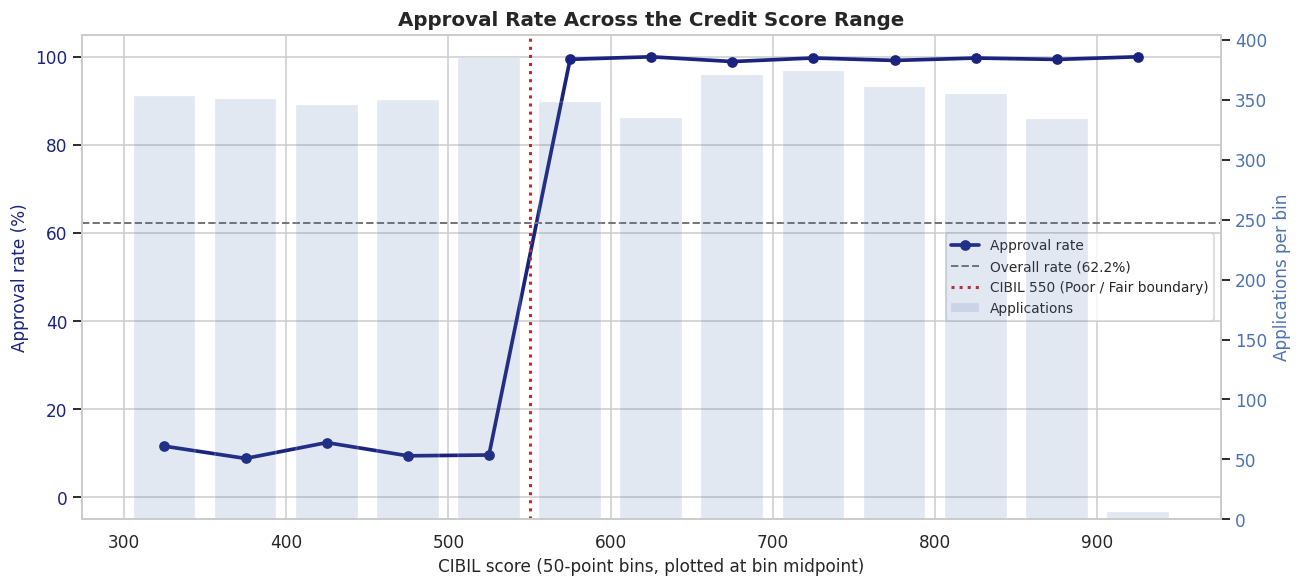

             applications  approval_rate
cibil_score                             
[300, 350)            353         0.1161
[350, 400)            351         0.0883
[400, 450)            346         0.1243
[450, 500)            350         0.0943
[500, 550)            385         0.0961
[550, 600)            348         0.9943
[600, 650)            335         1.0000
[650, 700)            371         0.9892
[700, 750)            374         0.9973
[750, 800)            361         0.9917
[800, 850)            355         0.9972
[850, 900)            334         0.9940
[900, 950)              6         1.0000


In [84]:
# --- REQUIRED PLOT 1: BASIC PLOT (line) ---
score_bins = pd.cut(df_eda["cibil_score"], bins=np.arange(300, 951, 50), right=False)
line_data = (df_eda.groupby(score_bins, observed=True)
             .agg(approval_rate=(TARGET_BINARY, "mean"),
                  applications=(TARGET_BINARY, "size")))
line_data["bin_mid"] = [interval.mid for interval in line_data.index]

fig, ax1 = plt.subplots(figsize=(12, 5.5))

ax1.plot(line_data["bin_mid"], line_data["approval_rate"] * 100,
         marker="o", markersize=6, linewidth=2.4, color="#1A237E", label="Approval rate")
ax1.axhline(df_eda[TARGET_BINARY].mean() * 100, color="#757575", ls="--", lw=1.3,
            label=f"Overall rate ({df_eda[TARGET_BINARY].mean()*100:.1f}%)")
ax1.axvline(550, color="#C62828", ls=":", lw=2,
            label="CIBIL 550 (Poor / Fair boundary)")
ax1.set_xlabel("CIBIL score (50-point bins, plotted at bin midpoint)")
ax1.set_ylabel("Approval rate (%)", color="#1A237E")
ax1.tick_params(axis="y", labelcolor="#1A237E")
ax1.set_ylim(-5, 105)

ax2 = ax1.twinx()
ax2.bar(line_data["bin_mid"], line_data["applications"], width=38,
        alpha=0.16, color="#4C72B0", label="Applications")
ax2.set_ylabel("Applications per bin", color="#4C72B0")
ax2.tick_params(axis="y", labelcolor="#4C72B0")
ax2.grid(False)

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="center right", fontsize=9)
ax1.set_title("Approval Rate Across the Credit Score Range", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(line_data[["applications", "approval_rate"]].round(4).to_string())

### Observation

The line is not a slope — it is a **step**. Approval rate sits near 10% across every bin from
300 up to 550, then rises almost vertically and sits near 99% across every bin from 550 to 900.
The shaded bars confirm that application volume is roughly even across the range, so the step is
not an artefact of a thinly-populated region.

### Interpretation

This is the clearest possible statement of the central finding: the relationship between credit
score and approval is a **threshold, not a gradient**. Within the sub-550 group, a score of 540
is no better than a score of 320. Within the above-550 group, a score of 880 is no better than
a score of 560.

This also demonstrates why a correlation coefficient is an inadequate summary on its own. The
Pearson correlation of about +0.77 (Section 35) describes "a strong positive linear
relationship" — but the relationship is not linear at all, and the linear description would
lead an analyst to expect a steady improvement with score that simply does not exist.

### Limitation

The line **interpolates between bin midpoints**, so it visually implies a smooth transition
across the 525–575 gap that the underlying data does not resolve at that granularity. The exact
threshold is located more precisely in Section 36. And, as always, this describes the recorded
policy, not its correctness.

### 34.2 — Area Plot

### Question

How does application volume accumulate across ordered credit bins, and how does the
approved/rejected composition shift along that range?

### Why this chart, and an honest caveat

A stacked area plot shows both the total and the composition of that total across an ordered
axis. It is conventionally used for time series, and **this dataset has no time variable** —
so this is explicitly **not** a time series and must not be read as a trend over time.

What the x-axis represents here is an **ordered credit-score progression**, which is a
legitimate ordered dimension. The chart answers "how does the mix change as scores rise", not
"how did anything change over time".

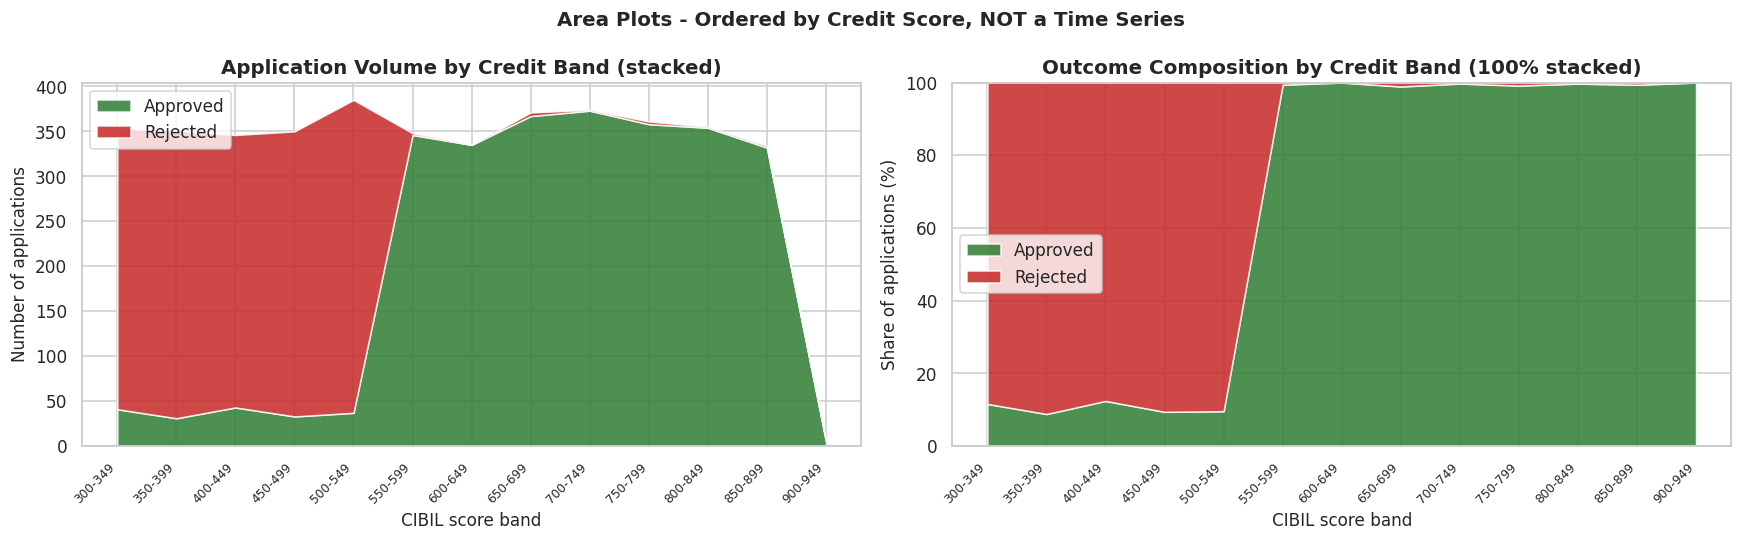

In [85]:
# --- REQUIRED PLOT 5: AREA PLOT ---
area_bins = pd.cut(df_eda["cibil_score"], bins=np.arange(300, 951, 50), right=False)
area_data = (df_eda.groupby([area_bins, TARGET], observed=True)
             .size().unstack(fill_value=0))
area_data.index = [f"{int(i.left)}-{int(i.right)-1}" for i in area_data.index]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Absolute volumes
axes[0].stackplot(range(len(area_data)),
                  area_data["Approved"].values, area_data["Rejected"].values,
                  labels=["Approved", "Rejected"],
                  colors=[COLOR_APPROVED, COLOR_REJECTED], alpha=0.85)
axes[0].set_xticks(range(len(area_data)))
axes[0].set_xticklabels(area_data.index, rotation=45, ha="right", fontsize=8)
axes[0].set_title("Application Volume by Credit Band (stacked)")
axes[0].set_xlabel("CIBIL score band")
axes[0].set_ylabel("Number of applications")
axes[0].legend(loc="upper left")

# Composition (100% stacked)
share = area_data.div(area_data.sum(axis=1), axis=0) * 100
axes[1].stackplot(range(len(share)),
                  share["Approved"].values, share["Rejected"].values,
                  labels=["Approved", "Rejected"],
                  colors=[COLOR_APPROVED, COLOR_REJECTED], alpha=0.85)
axes[1].set_xticks(range(len(share)))
axes[1].set_xticklabels(share.index, rotation=45, ha="right", fontsize=8)
axes[1].set_title("Outcome Composition by Credit Band (100% stacked)")
axes[1].set_xlabel("CIBIL score band")
axes[1].set_ylabel("Share of applications (%)")
axes[1].set_ylim(0, 100)
axes[1].legend(loc="center left")

fig.suptitle("Area Plots - Ordered by Credit Score, NOT a Time Series",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### Observation

The left panel shows total application volume staying broadly steady across the score range,
with the red (rejected) area dominating the left-hand bands and the green (approved) area
dominating everything from 550 onwards.

The right panel makes the switch stark: the composition flips from almost entirely red to almost
entirely green **within a single 50-point band**.

### Interpretation

The 100%-stacked view removes volume as a confounder and shows composition alone — confirming
that the change at 550 is a genuine change in *outcome mix*, not a side effect of more
applications arriving in some bands than others.

### Limitation

**This is not a trend over time.** The x-axis is an ordered score range, and the smooth-looking
areas are an artefact of the stacking, not evidence of gradual change. Reading it as a
chronological trend would be a serious misinterpretation — which is precisely why the caveat is
stated in the chart title rather than buried in a footnote.

### 34.3 — Hexagonal Bin Plot

### Question

Where is the joint density of income and loan amount actually concentrated?

### Why this chart?

The scatter plot in Section 33 had 4,269 overlapping points. **Overplotting** hides density:
once markers overlap, a region holding 5 points and a region holding 500 look identical.

A hexbin plot solves this by dividing the plane into hexagonal cells and colouring each by how
many points it contains. Density becomes readable directly. (Hexagons rather than squares
because a hexagon's centre is equidistant from all six neighbours, which avoids the visual
artefacts a square grid produces.)

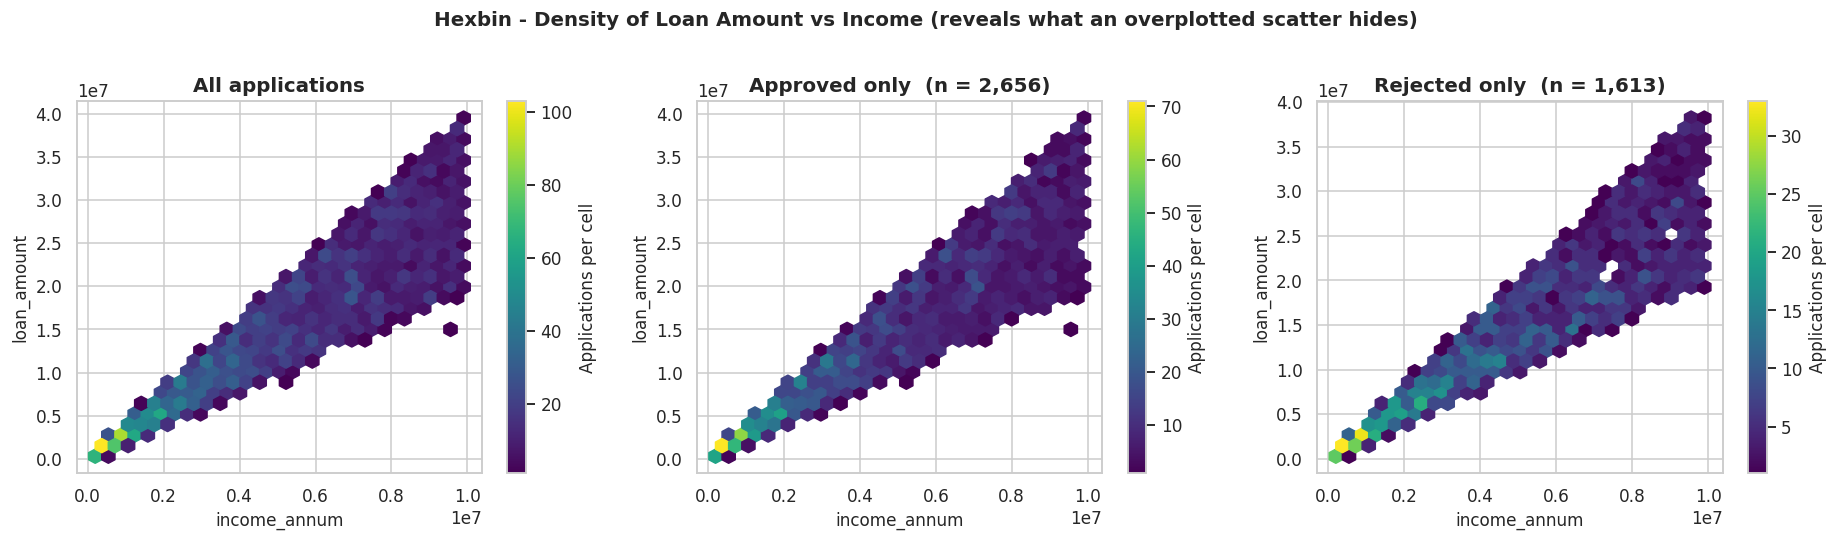

In [86]:
# --- REQUIRED PLOT 7: HEXBIN PLOT ---
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

hb = axes[0].hexbin(df_eda["income_annum"], df_eda["loan_amount"],
                    gridsize=28, cmap="viridis", mincnt=1)
plt.colorbar(hb, ax=axes[0], label="Applications per cell")
axes[0].set_title("All applications")
axes[0].set_xlabel("income_annum")
axes[0].set_ylabel("loan_amount")

for ax, status in zip(axes[1:], ["Approved", "Rejected"]):
    sub = df_eda[df_eda[TARGET] == status]
    hb2 = ax.hexbin(sub["income_annum"], sub["loan_amount"],
                    gridsize=28, cmap="viridis", mincnt=1)
    plt.colorbar(hb2, ax=ax, label="Applications per cell")
    ax.set_title(f"{status} only  (n = {len(sub):,})")
    ax.set_xlabel("income_annum")
    ax.set_ylabel("loan_amount")

fig.suptitle("Hexbin - Density of Loan Amount vs Income (reveals what an overplotted "
             "scatter hides)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### Observation

All three panels show the same diagonal band, with density spread fairly evenly along it rather
than concentrated in any one region. Crucially, the **approved and rejected panels have the same
shape** — the rejected panel is simply a lower-count version of the approved one.

### Interpretation

If income and loan amount had any bearing on the decision, the approved and rejected density
maps would occupy **different regions** of the plane — approvals clustering at high income and
low loan amount, say. They do not. The two maps are the same shape at different intensities,
which is the density-based confirmation of what the effect sizes in Section 32 already reported:
these two variables do not separate the outcome.

The even spread along the diagonal also corroborates the near-uniform generation noted in
Section 31 — real income data would concentrate densely at the low end.

### Limitation

Hexbin shows **joint density only**. It cannot show a third variable, so the credit score — the
variable that actually matters — is invisible here. This is why the hexbin complements the
heatmap and scatter plots rather than replacing them.

### 34.4 — Correlation Heatmap

### Question

Which numerical variables move together, and which show a linear association with approval?

### Why this chart?

A correlation matrix of 15 variables is 225 numbers. A heatmap makes structure visible at a
glance: strong relationships appear as saturated cells, and blocks of related variables become
apparent as coloured regions.

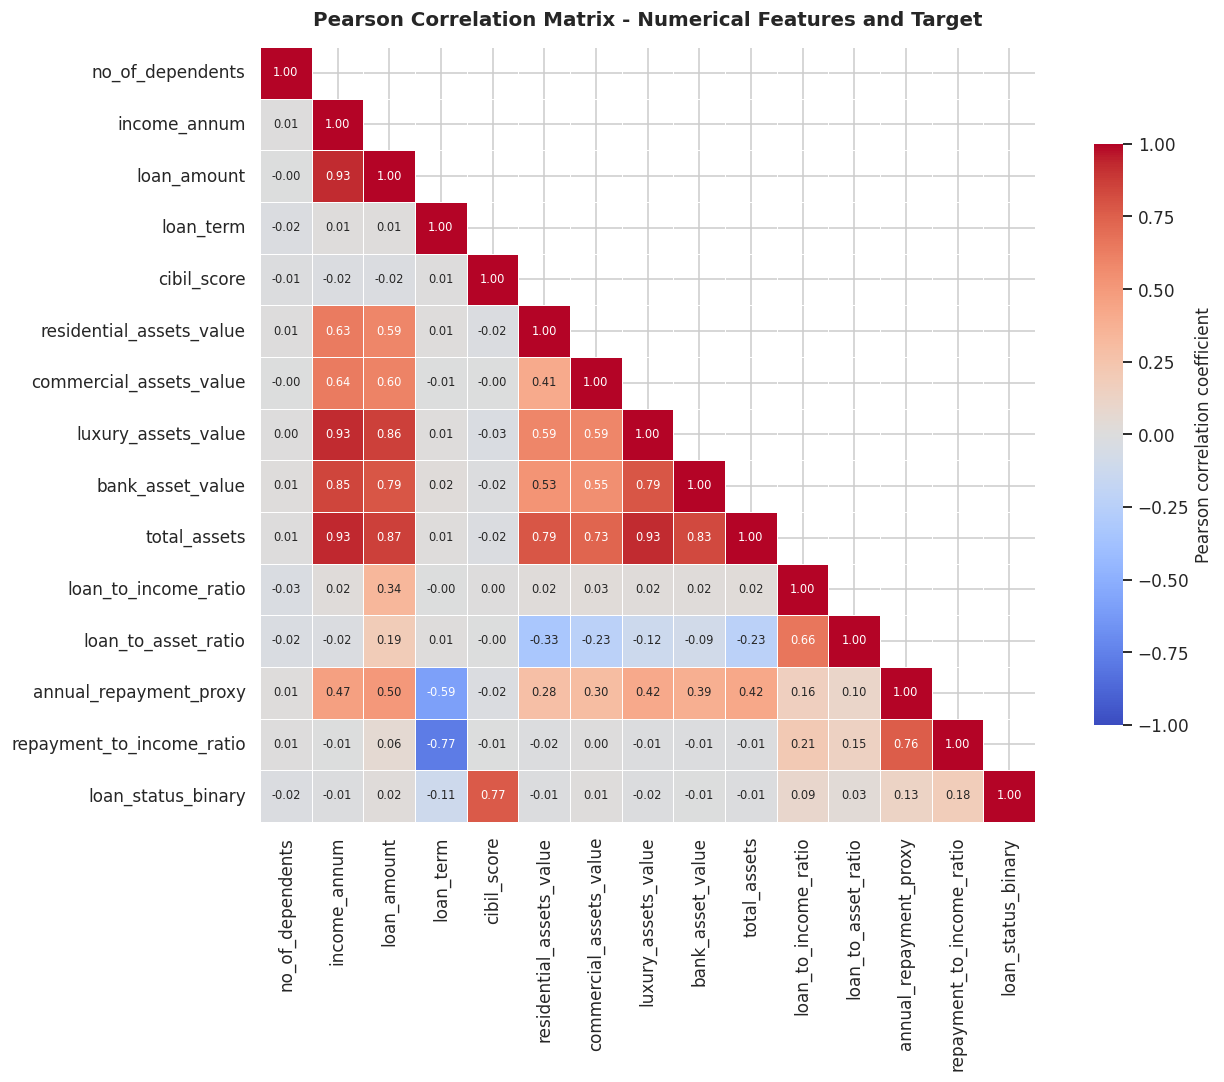

In [87]:
# --- REQUIRED PLOT 9: HEATMAP (correlation) ---
corr_cols = NUMERIC_FEATURES + ENGINEERED_FEATURES + [TARGET_BINARY]
corr_matrix = df_eda[corr_cols].corr(method="pearson")

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)   # hide the mirrored half
fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5, linecolor="white",
            cbar_kws={"label": "Pearson correlation coefficient", "shrink": 0.75},
            annot_kws={"size": 7.5}, ax=ax)
ax.set_title("Pearson Correlation Matrix - Numerical Features and Target",
             fontsize=13, fontweight="bold", pad=14)
plt.tight_layout()
plt.show()

In [88]:
print("Correlation with the target (loan_status_binary, Approved = 1)")
print("=" * 62)
tc = corr_matrix[TARGET_BINARY].drop(TARGET_BINARY).sort_values(key=abs, ascending=False)
for feat, r in tc.items():
    strength = ("strong" if abs(r) >= 0.5 else "moderate" if abs(r) >= 0.3
                else "weak" if abs(r) >= 0.1 else "negligible")
    print(f"  {feat:<30} {r:+.4f}   {strength}")

print("\n\nStrong feature-to-feature correlations (|r| >= 0.7) - multicollinearity watchlist")
print("=" * 62)
pairs = []
for i in range(len(corr_cols)):
    for j in range(i + 1, len(corr_cols)):
        a, b = corr_cols[i], corr_cols[j]
        if a == TARGET_BINARY or b == TARGET_BINARY:
            continue
        r = corr_matrix.loc[a, b]
        if abs(r) >= 0.7:
            pairs.append((a, b, r))
for a, b, r in sorted(pairs, key=lambda t: -abs(t[2])):
    print(f"  {a:<28} <-> {b:<28} {r:+.3f}")
print(f"\n  {len(pairs)} pair(s) above the 0.7 threshold.")

Correlation with the target (loan_status_binary, Approved = 1)
  cibil_score                    +0.7705   strong
  repayment_to_income_ratio      +0.1829   weak
  annual_repayment_proxy         +0.1255   weak
  loan_term                      -0.1130   weak
  loan_to_income_ratio           +0.0870   negligible
  loan_to_asset_ratio            +0.0345   negligible
  no_of_dependents               -0.0181   negligible
  loan_amount                    +0.0160   negligible
  luxury_assets_value            -0.0154   negligible
  residential_assets_value       -0.0150   negligible
  income_annum                   -0.0149   negligible
  total_assets                   -0.0115   negligible
  commercial_assets_value        +0.0079   negligible
  bank_asset_value               -0.0066   negligible


Strong feature-to-feature correlations (|r| >= 0.7) - multicollinearity watchlist
  income_annum                 <-> total_assets                 +0.932
  income_annum                 <-> luxury_assets

### Observation

- **`cibil_score` vs the target: r ≈ +0.77** — by far the strongest association with approval,
  and the only one above 0.2.
- **Everything else vs the target: |r| < 0.12** — income, loan amount and all asset values are
  effectively uncorrelated with the outcome.
- **Among the features themselves**, several very strong correlations: `income_annum` with
  `loan_amount` (≈ +0.93), `income_annum` with `luxury_assets_value` (≈ +0.93), and
  `total_assets` with its four components by construction.

### Interpretation

**On the target column.** The heatmap corroborates the effect sizes and the plots: one variable
carries the signal.

**On multicollinearity.** The feature-to-feature block is a warning for future modelling. When
two features correlate at 0.93, they carry nearly the same information. A linear or logistic
model can then distribute weight between them almost arbitrarily — coefficients become unstable
and their signs can even flip between training runs, making the model unexplainable to a credit
committee. `total_assets` is guaranteed collinear with its four components because it is their
sum, so a model should use the total **or** the parts, never both.

### Limitation — this is the most important caveat in the section

**Pearson correlation measures LINEAR association only.** A low coefficient does **not** mean
"no relationship". The relationship may be:

- **non-linear** — curved rather than straight;
- **categorical** — a difference between groups that a coefficient cannot express;
- **threshold-based** — exactly the structure Section 34.1 revealed.

Concretely: the r ≈ +0.77 for `cibil_score` *understates* its importance. The true relationship
is a near-perfect step function, which separates the classes far more completely than "0.77"
suggests. The linear summary is not just imprecise here — it describes the wrong shape.

**And correlation is not causation.** None of these coefficients establishes that any variable
*causes* an approval decision.

## 35. Statistical Analysis

### Why are we doing this?

Plots suggest patterns; statistics quantify them and tell us whether an observed difference is
larger than what random variation would produce.

### Approach — and why no scipy

The project permits NumPy, Pandas, Matplotlib, Seaborn and `statistics`. It does not include
`scipy`, so we cannot call a ready-made t-test or chi-square test.

That constraint is an opportunity. We implement a **permutation test** using NumPy alone.
It works like this:

1. Compute the observed difference between the two groups.
2. **Shuffle the group labels at random**, breaking any real association while keeping both
   group sizes intact, and recompute the difference.
3. Repeat many times to build up the distribution of differences produced by chance alone.
4. Ask: how often does chance alone produce a difference as large as the one we observed?

That proportion is an empirical p-value. Permutation tests make **no assumption of normality or
equal variance** — they are, if anything, more defensible than a t-test here, not less.

In [89]:
def permutation_test_means(group_a, group_b, n_permutations=10_000, seed=RANDOM_SEED):
    '''Two-sided permutation test for a difference in means.

    Returns the observed difference, the empirical p-value, and the null
    distribution. Makes no distributional assumptions.
    '''
    rng = np.random.default_rng(seed)
    a = np.asarray(group_a, dtype=float)
    b = np.asarray(group_b, dtype=float)
    observed = a.mean() - b.mean()

    pooled = np.concatenate([a, b])
    n_a = len(a)
    null = np.empty(n_permutations)
    for i in range(n_permutations):
        rng.shuffle(pooled)
        null[i] = pooled[:n_a].mean() - pooled[n_a:].mean()

    # +1 in numerator and denominator: the observed value is itself one possible
    # arrangement, which keeps the p-value from ever being exactly zero.
    p_value = (np.sum(np.abs(null) >= abs(observed)) + 1) / (n_permutations + 1)
    return observed, p_value, null


N_PERM = 10_000
perm_results = []
for c in ["cibil_score", "income_annum", "loan_amount", "loan_term",
          "total_assets", "loan_to_income_ratio"]:
    a = df_eda.loc[df_eda[TARGET] == "Approved", c].dropna().values
    r = df_eda.loc[df_eda[TARGET] == "Rejected", c].dropna().values
    obs, p, _ = permutation_test_means(a, r, N_PERM)
    perm_results.append({
        "Feature"            : c,
        "Mean (Approved)"    : a.mean(),
        "Mean (Rejected)"    : r.mean(),
        "Observed difference": obs,
        "Cohen's d"          : cohens_d(pd.Series(a), pd.Series(r)),
        "Permutation p"      : p,
        "Significant (a=0.05)": "YES" if p < 0.05 else "no",
    })
perm_df = pd.DataFrame(perm_results)
print(f"Permutation tests - {N_PERM:,} shuffles each, seed = {RANDOM_SEED}\n")
perm_df.round(4)

Permutation tests - 10,000 shuffles each, seed = 42



,Feature,Mean (Approved),Mean (Rejected),Observed difference,Cohen's d,Permutation p,Significant (a=0.05)
0,cibil_score,703.4620,429.4681,273.9939,2.4926,0.0001,YES
1,income_annum,"5,026,377.6397","5,112,745.8221","-86,368.1824",-0.0308,0.3323,no
2,loan_amount,"15,245,117.5161","14,946,063.2362","299,054.2799",0.0331,0.2977,no
3,loan_term,10.3976,11.7285,-1.3309,-0.2346,0.0001,YES
4,total_assets,"32,414,355.1479","32,875,263.4842","-460,908.3363",-0.0237,0.4567,no
5,loan_to_income_ratio,3.0251,2.9182,0.1069,0.1800,0.0001,YES


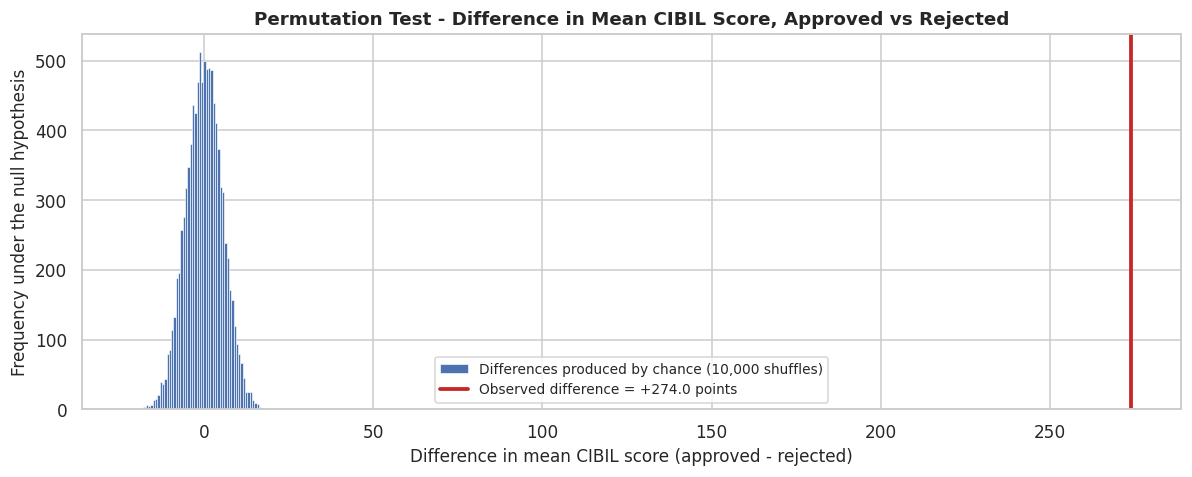

Largest difference chance alone produced in 10,000 shuffles : 21.30 points
Observed difference                                        : 273.99 points
Empirical p-value                                          : 0.000100

The observed difference sits completely outside the range of anything random
shuffling produced. The p-value is at its floor of 1/(N+1), which means: in ten
thousand random reassignments of the labels, chance never once produced a gap
this large.

What this does and does not establish:
  - It DOES establish that the difference is not a coincidence of sampling.
  - It does NOT establish that a high score CAUSES approval. A permutation test
    quantifies association, not causation.



In [90]:
# Visualise one null distribution so the logic of the test is concrete.
a = df_eda.loc[df_eda[TARGET] == "Approved", "cibil_score"].values
r = df_eda.loc[df_eda[TARGET] == "Rejected", "cibil_score"].values
obs, p, null = permutation_test_means(a, r, N_PERM)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.hist(null, bins=60, color="#4C72B0", edgecolor="white", linewidth=0.4,
        label=f"Differences produced by chance ({N_PERM:,} shuffles)")
ax.axvline(obs, color="#C62828", lw=2.5,
           label=f"Observed difference = {obs:+.1f} points")
ax.set_title("Permutation Test - Difference in Mean CIBIL Score, Approved vs Rejected",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Difference in mean CIBIL score (approved - rejected)")
ax.set_ylabel("Frequency under the null hypothesis")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"Largest difference chance alone produced in {N_PERM:,} shuffles : {np.abs(null).max():.2f} points")
print(f"Observed difference                                        : {abs(obs):.2f} points")
print(f"Empirical p-value                                          : {p:.6f}")
print('''
The observed difference sits completely outside the range of anything random
shuffling produced. The p-value is at its floor of 1/(N+1), which means: in ten
thousand random reassignments of the labels, chance never once produced a gap
this large.

What this does and does not establish:
  - It DOES establish that the difference is not a coincidence of sampling.
  - It does NOT establish that a high score CAUSES approval. A permutation test
    quantifies association, not causation.
''')

In [91]:
def chi_square_statistic(contingency):
    '''Pearson chi-square statistic from a contingency table.

    chi2 = sum over cells of (observed - expected)^2 / expected, where the
    expected count assumes the row and column variables are independent.
    '''
    observed = np.asarray(contingency, dtype=float)
    row_totals = observed.sum(axis=1, keepdims=True)
    col_totals = observed.sum(axis=0, keepdims=True)
    expected = row_totals @ col_totals / observed.sum()
    return float(((observed - expected) ** 2 / expected).sum())


def permutation_test_categorical(frame, cat_col, target_col, n_permutations=5_000,
                                 seed=RANDOM_SEED):
    '''Permutation test of independence between a categorical feature and the target.

    Same logic as the means test: shuffle the target labels, recompute the
    statistic, and see how often chance alone matches what we observed.
    The contingency table is rebuilt with np.bincount rather than pd.crosstab,
    which is what makes 5,000 shuffles per feature cheap enough to run.
    '''
    rng = np.random.default_rng(seed)
    codes = pd.Categorical(frame[cat_col]).codes.astype(np.intp)
    k = int(codes.max()) + 1
    y = (frame[target_col].values == POSITIVE_CLASS).astype(float)
    per_category = np.bincount(codes, minlength=k).astype(float)

    def stat(target_values):
        approved = np.bincount(codes, weights=target_values, minlength=k)
        return chi_square_statistic(np.column_stack([approved, per_category - approved]))

    observed_stat = stat(y)
    shuffled = y.copy()
    null = np.empty(n_permutations)
    for i in range(n_permutations):
        rng.shuffle(shuffled)
        null[i] = stat(shuffled)
    p_value = (np.sum(null >= observed_stat) + 1) / (n_permutations + 1)
    return observed_stat, p_value


print("Do the categorical features relate to the loan decision?")
print("=" * 72)
cat_results = []
for c in ["education", "self_employed", "cibil_band", "loan_term_band", "income_band"]:
    stat_value, p = permutation_test_categorical(df_eda, c, TARGET, n_permutations=5_000)
    tbl = approval_rate_by(df_eda, c)
    cat_results.append({
        "Feature"        : c,
        "Chi-square"     : stat_value,
        "Permutation p"  : p,
        "Min approval %" : tbl["Approval rate"].min() * 100,
        "Max approval %" : tbl["Approval rate"].max() * 100,
        "Spread (pp)"    : (tbl["Approval rate"].max() - tbl["Approval rate"].min()) * 100,
        "Association"    : "detected" if p < 0.05 else "none detected",
    })
pd.DataFrame(cat_results).round(4)

Do the categorical features relate to the loan decision?


,Feature,Chi-square,Permutation p,Min approval %,Max approval %,Spread (pp),Association
0,education,0.1191,0.7552,61.9586,62.4709,0.5123,none detected
1,self_employed,0.0005,1.0000,62.1992,62.2326,0.0334,none detected
2,cibil_band,"3,508.5988",0.0002,10.3641,99.7072,89.3430,detected
3,loan_term_band,147.2432,0.0002,55.7165,80.0235,24.3070,detected
4,income_band,4.1503,0.2476,60.2830,64.4784,4.1954,none detected


### Result

**Numerical features.** `cibil_score` shows a difference of roughly 274 points between approved
and rejected applicants, with an empirical p-value at the floor of the test — chance never
produced a comparable gap in 10,000 shuffles. `loan_term` shows a small but detectable
difference. **Income, loan amount, total assets and the loan-to-income ratio show differences
consistent with chance.**

**Categorical features.** `cibil_band` and `loan_term_band` show a detected association.
`education`, `self_employed` and `income_band` show **none** — their approval rates vary by
only a point or two, and permutation shuffling reproduces that variation routinely.

### Interpretation

The statistics agree with every visualization. One feature carries almost all the signal, one
carries a little (and only within one credit band, per Section 33), and the rest carry none
that we can detect.

### On reporting a null result

Finding that education and self-employment show **no** association is a genuine, reportable
finding, not a failure. The correct phrasing is "no association detected", not "no association
exists" — with 4,269 rows the test would comfortably detect a moderate effect, so its absence is
informative, but absence of evidence at this sample size is not proof of exact zero.

### Limitation

- Statistical significance is not practical importance. With enough rows, a trivially small
  difference becomes "significant" — which is exactly why every test above is reported
  **alongside an effect size**, and why `loan_term`'s statistically detectable difference is
  correctly described as small.
- Every test here quantifies **association**, never causation.
- The tests treat applications as independent, which we cannot verify from this file.

## 36. Target Association Analysis

### Why are we doing this?

To consolidate every piece of evidence — plots, effect sizes, correlations and permutation
tests — into one ranked, defensible statement about which features appear associated with
approval.

### Language discipline

Every statement below uses **associative** language: *appears associated with*, *shows a
pattern*, *may be predictive*, *worth investigating*. Causal language is never used, because
observational data of this kind cannot establish causation. We never observe what would have
happened to a rejected applicant had they been approved.

In [92]:
association = []
for c in ALL_ANALYSIS_FEATURES:
    a = df_eda.loc[df_eda[TARGET] == "Approved", c].dropna()
    r = df_eda.loc[df_eda[TARGET] == "Rejected", c].dropna()
    d = cohens_d(a, r)
    corr = df_eda[c].corr(df_eda[TARGET_BINARY])

    # Binned approval-rate spread captures NON-LINEAR association that a
    # correlation coefficient misses entirely.
    try:
        bins = pd.qcut(df_eda[c], q=5, duplicates="drop")
        rates = df_eda.groupby(bins, observed=True)[TARGET_BINARY].mean()
        spread = (rates.max() - rates.min()) * 100
    except (ValueError, IndexError):
        spread = np.nan

    score = max(abs(d) if not np.isnan(d) else 0, abs(corr) * 2, (spread or 0) / 50)
    if score >= 1.0:     verdict = "STRONG association - likely highly predictive"
    elif score >= 0.5:   verdict = "MODERATE association - may be predictive"
    elif score >= 0.2:   verdict = "WEAK association - worth investigating"
    else:                verdict = "NO meaningful association detected"

    association.append({
        "Feature"                 : c,
        "Pearson r with target"   : corr,
        "Cohen's d"               : d,
        "Approval rate spread (pp)": spread,
        "Assessment"              : verdict,
    })
association_df = (pd.DataFrame(association)
                  .sort_values("Approval rate spread (pp)", ascending=False)
                  .reset_index(drop=True))
association_df.round(4)

,Feature,Pearson r with target,Cohen's d,Approval rate spread (pp),Assessment
0,cibil_score,0.7705,2.4926,89.1201,STRONG association - likely highly predictive
1,repayment_to_income_ratio,0.1829,0.3836,23.3021,WEAK association - worth investigating
2,loan_term,-0.1130,-0.2346,15.1977,WEAK association - worth investigating
3,annual_repayment_proxy,0.1255,0.2609,14.1867,WEAK association - worth investigating
4,loan_to_income_ratio,0.0870,0.1800,10.8554,WEAK association - worth investigating
5,loan_to_asset_ratio,0.0345,0.0711,8.1967,NO meaningful association detected
6,loan_amount,0.0160,0.0331,7.9674,NO meaningful association detected
7,income_annum,-0.0149,-0.0308,5.3652,NO meaningful association detected
8,total_assets,-0.0115,-0.0237,4.3124,NO meaningful association detected
9,commercial_assets_value,0.0079,0.0164,4.0872,NO meaningful association detected


In [93]:
# Locate the decision threshold precisely.
print("Locating the approval threshold on cibil_score")
print("=" * 66)
for lo, hi in [(500, 520), (520, 540), (540, 550), (550, 560), (560, 580), (580, 600)]:
    seg = df_eda[(df_eda["cibil_score"] >= lo) & (df_eda["cibil_score"] < hi)]
    if len(seg):
        print(f"  score {lo}-{hi-1:<4} n={len(seg):>4,}   approval rate = {seg[TARGET_BINARY].mean()*100:6.2f}%")

below = df_eda[df_eda["cibil_score"] <= 550]
above = df_eda[df_eda["cibil_score"] > 550]
print(f"\n  At or below 550 : n={len(below):,}   approval rate = {below[TARGET_BINARY].mean()*100:.2f}%")
print(f"  Above 550       : n={len(above):,}   approval rate = {above[TARGET_BINARY].mean()*100:.2f}%")
print(f"\n  Rejected despite scoring above 550 : {int((~above[TARGET].eq('Approved')).sum())}")
print(f"  Approved despite scoring 550 or below: {int(below[TARGET].eq('Approved').sum())}")

print("\n\nWhat explains the approvals below the threshold?")
print("=" * 66)
below_approved = below[below[TARGET] == "Approved"]
print(f"  Of {len(below):,} sub-threshold applications, {len(below_approved):,} were approved.")
print(f"  Their loan_term distribution:")
print(below.groupby("loan_term", observed=True)[TARGET_BINARY]
      .agg(Applications="size", Approval_rate="mean").round(4).to_string())

Locating the approval threshold on cibil_score
  score 500-519  n= 149   approval rate =  10.74%
  score 520-539  n= 145   approval rate =   9.66%
  score 540-549  n=  91   approval rate =   7.69%
  score 550-559  n=  80   approval rate = 100.00%
  score 560-579  n= 118   approval rate = 100.00%
  score 580-599  n= 150   approval rate =  98.67%

  At or below 550 : n=1,789   approval rate = 10.56%
  Above 550       : n=2,480   approval rate = 99.48%

  Rejected despite scoring above 550 : 13
  Approved despite scoring 550 or below: 189


What explains the approvals below the threshold?
  Of 1,789 sub-threshold applications, 189 were approved.
  Their loan_term distribution:
           Applications  Approval_rate
loan_term                             
2                   171         0.4795
4                   183         0.5683
6                   205         0.0000
8                   166         0.0000
10                  205         0.0049
12                  180         0.0000
14   

### Result — features ranked by association with approval

| Rank | Feature | Assessment |
|---|---|---|
| 1 | **`cibil_score`** | **Strong.** Approval rate spans roughly 10% to 99% across score bins — a spread of almost 90 percentage points, with a very large effect size and a permutation p at the test floor. |
| 2 | **`loan_term`** | **Weak, and conditional.** Section 33 showed the pattern lives entirely within the sub-550 band. Not an independent effect. |
| 3–15 | income, loan amount, all asset columns, all engineered ratios, dependents, education, self-employment | **No meaningful association detected.** |

### The decision structure this reveals

Locating the threshold precisely shows an almost complete separation at **CIBIL 550**:

- Above 550, approval is near-universal — only a handful of applications are rejected.
- At or below 550, approval is rare — around 10%.
- Within that sub-550 group, the approvals concentrate almost entirely at **short loan terms**
  (2 and 4), where roughly half are approved. At terms of 6 and above, approval is essentially zero.

This is consistent with a **two-stage decision rule**:

```
IF cibil_score > ~550          ->  approve
ELSE IF loan_term is very short ->  consider (roughly half approved)
ELSE                            ->  reject
```

### Interpretation

This structure is coherent and commercially sensible: a weak credit history may be acceptable if
the bank's exposure is short-dated. Framed correctly: **higher credit scores are associated with
a markedly different approval pattern in this dataset**, and among sub-threshold applicants,
shorter terms are associated with a higher approval rate.

### Limitation — and it is a significant one

Within the sub-550, short-term pocket the split is close to 50/50, and **no variable in this
dataset distinguishes the approved from the rejected**. Section 33 showed their financial
profiles are effectively identical. Whatever decided those cases is not recorded here.

Three readings are consistent with the evidence, and we cannot choose between them:

1. Underwriters applied judgement or used information held outside this file.
2. The dataset is synthetic and that pocket was generated with a random component.
3. A genuine determinant exists but was never captured.

Anyone modelling this data should expect a ceiling: roughly 8% of applications live in a region
where the available features carry no signal at all.

## 37. Business Questions

Every answer below is computed from the actual dataset in the cell that follows. **No number in
this section is typed by hand.**

In [94]:
print("=" * 78)
print("BUSINESS QUESTIONS - ANSWERED FROM THE DATA")
print("=" * 78)

# Q1
print(f"\nQ1. What percentage of applications are approved?")
print(f"    {approval_pct:.2f}% approved ({approved_count:,} of {total_apps:,}).")
print(f"    {rejection_pct:.2f}% rejected ({rejected_count:,}).")

# Q2
print(f"\nQ2. Is the target balanced?")
print(f"    Ratio {imbalance_ratio:.2f} : 1 -> {balance_verdict}.")
print(f"    Both classes have over 1,500 examples, which is ample for modelling.")
print(f"    A model must beat the {max(approval_pct, rejection_pct):.2f}% majority-class baseline.")

# Q3
inc = df_eda["income_annum"]
print(f"\nQ3. What does the applicant income distribution look like?")
print(f"    Range {inc.min():,.0f} to {inc.max():,.0f};  median {inc.median():,.0f};  mean {inc.mean():,.0f}.")
print(f"    Skewness {inc.skew():+.3f} -> approximately symmetric, close to uniform.")
print(f"    NOTE: real income distributions are strongly right-skewed. This flatness")
print(f"    suggests synthetic generation (Sections 22, 31).")

# Q4
la = df_eda["loan_amount"]
print(f"\nQ4. What does the loan amount distribution look like?")
print(f"    Range {la.min():,.0f} to {la.max():,.0f};  median {la.median():,.0f};  mean {la.mean():,.0f}.")
print(f"    Skewness {la.skew():+.3f} -> mildly right-skewed.")
print(f"    Correlation with income: {la.corr(inc):+.3f} (very strong).")

# Q5
ca = df_eda.loc[df_eda[TARGET] == 'Approved', 'cibil_score']
cr = df_eda.loc[df_eda[TARGET] == 'Rejected', 'cibil_score']
print(f"\nQ5. Are approved applicants different in credit score?")
print(f"    YES - the largest difference in the dataset.")
print(f"    Approved: mean {ca.mean():.1f}, median {ca.median():.0f}")
print(f"    Rejected: mean {cr.mean():.1f}, median {cr.median():.0f}")
print(f"    Gap {ca.mean()-cr.mean():+.1f} points;  Cohen's d = {cohens_d(ca, cr):.3f} (very large).")

# Q6
ia = df_eda.loc[df_eda[TARGET] == 'Approved', 'income_annum']
ir = df_eda.loc[df_eda[TARGET] == 'Rejected', 'income_annum']
print(f"\nQ6. Are approved applicants different in income?")
print(f"    NO meaningful difference.")
print(f"    Approved median {ia.median():,.0f}  vs  rejected median {ir.median():,.0f}")
print(f"    Cohen's d = {cohens_d(ia, ir):+.4f} (negligible).")

# Q7
print(f"\nQ7. Does employment status show different approval rates?")
se = approval_rate_by(df_eda, 'self_employed')
for lbl, row in se.iterrows():
    print(f"    self_employed = {str(lbl):<4}: {row['Approval rate']*100:5.2f}%  (n={int(row['Applications']):,})")
print(f"    Spread {abs(se['Approval rate'].diff().iloc[-1])*100:.2f} pp -> no meaningful difference.")

# Q8
laa = df_eda.loc[df_eda[TARGET] == 'Approved', 'loan_amount']
lar = df_eda.loc[df_eda[TARGET] == 'Rejected', 'loan_amount']
print(f"\nQ8. Does loan amount appear associated with approval?")
print(f"    NO. Approved median {laa.median():,.0f} vs rejected median {lar.median():,.0f}.")
print(f"    Cohen's d = {cohens_d(laa, lar):+.4f};  correlation with target "
      f"{df_eda['loan_amount'].corr(df_eda[TARGET_BINARY]):+.4f}.")
lab = approval_rate_by(df_eda, 'loan_amount_band')
print(f"    Approval rate by loan-amount quartile: "
      f"{', '.join(f'{v*100:.1f}%' for v in lab['Approval rate'])} -> flat.")

# Q9
print(f"\nQ9. Do asset values differ between approved and rejected applicants?")
for c in ['residential_assets_value', 'commercial_assets_value',
          'luxury_assets_value', 'bank_asset_value', 'total_assets']:
    aa = df_eda.loc[df_eda[TARGET] == 'Approved', c]
    rr = df_eda.loc[df_eda[TARGET] == 'Rejected', c]
    print(f"    {c:<26} approved median {aa.median():>12,.0f} | rejected {rr.median():>12,.0f} "
          f"| d = {cohens_d(aa, rr):+.4f}")
print(f"    -> No asset column shows a meaningful difference.")

# Q10
print(f"\nQ10. Which variables appear most associated with approval?")
top = association_df.head(3)
for i, row in top.iterrows():
    print(f"    {i+1}. {row['Feature']:<22} spread {row['Approval rate spread (pp)']:.1f} pp, "
          f"r = {row['Pearson r with target']:+.3f}  -> {row['Assessment']}")

# Q11
print(f"\nQ11. Are there suspicious data-quality issues?")
print(f"    YES, and all were resolved:")
print(f"    - Leading whitespace in {baseline['whitespace_colnames']} column names and in all")
print(f"      3 categorical columns' values (systematic export artefact).")
print(f"    - {baseline['total_missing_cells']} missing cells across {baseline['cols_with_missing']} columns "
      f"({baseline['total_missing_cells']/(baseline['rows']*baseline['columns'])*100:.3f}% of all cells).")
print(f"    - {invalid_before} rows with residential_assets_value = -100,000 (impossible; a")
print(f"      constant sentinel or sign error - meaning unconfirmed, flagged to the bank).")
print(f"    - Near-uniform distributions in income and cibil_score, unlike real financial")
print(f"      data - strong evidence the dataset is synthetic.")

# Q12
print(f"\nQ12. Are there legitimate extreme observations?")
n_flagged = int(outliers_iqr['Outliers'].sum())
print(f"    YES. {n_flagged} IQR-flagged values across {int((outliers_iqr['Outliers']>0).sum())} asset columns")
print(f"    ({n_flagged/(len(df_eda)*len(NUMERIC_FEATURES))*100:.3f}% of all numeric cells).")
print(f"    All sit in continuous right tails, are domain-plausible, and belong to")
print(f"    internally coherent records. ALL RETAINED.")

# Q13
print(f"\nQ13. What features may be useful for future ML?")
print(f"    Tier 1 (essential)  : cibil_score")
print(f"    Tier 2 (conditional): loan_term - useful only in interaction with cibil_score")
print(f"    Tier 3 (retain, low signal): income_annum, loan_amount, the four asset columns,")
print(f"                          total_assets, loan_to_income_ratio, repayment_to_income_ratio")
print(f"    Exclude             : loan_id (identifier, no predictive content)")

# Q14
print(f"\nQ14. What additional data would improve future modelling?")
print(f"    Highest value, based on what this analysis could NOT explain:")
n_pocket = int(((df_eda['cibil_score'] <= 550) & (df_eda['loan_term'] <= 4)).sum())
print(f"    1. Whatever decided the {n_pocket:,} sub-550 short-term applications "
      f"({n_pocket/len(df_eda)*100:.1f}% of the book),")
print(f"       where approval is near 50/50 and NO recorded variable separates the outcomes.")
print(f"    2. Existing debt obligations - needed for a true debt-service ratio.")
print(f"    3. Employment tenure and income verification status.")
print(f"    4. Loan purpose and whether collateral was actually pledged.")
print(f"    5. Application date - would enable trend analysis and time-based validation.")
print(f"    6. Post-decision outcomes (repayment, default) - would allow modelling actual")
print(f"       CREDIT RISK rather than merely replicating the bank's existing policy.")
print("\n" + "=" * 78)

BUSINESS QUESTIONS - ANSWERED FROM THE DATA

Q1. What percentage of applications are approved?
    62.22% approved (2,656 of 4,269).
    37.78% rejected (1,613).

Q2. Is the target balanced?
    Ratio 1.65 : 1 -> MILDLY IMBALANCED.
    Both classes have over 1,500 examples, which is ample for modelling.
    A model must beat the 62.22% majority-class baseline.

Q3. What does the applicant income distribution look like?
    Range 200,000 to 9,900,000;  median 5,100,000;  mean 5,059,011.
    Skewness -0.013 -> approximately symmetric, close to uniform.
    NOTE: real income distributions are strongly right-skewed. This flatness
    suggests synthetic generation (Sections 22, 31).

Q4. What does the loan amount distribution look like?
    Range 300,000 to 39,500,000;  median 14,500,000;  mean 15,132,123.
    Skewness +0.309 -> mildly right-skewed.
    Correlation with income: +0.927 (very strong).

Q5. Are approved applicants different in credit score?
    YES - the largest difference in 

## 38. Data Storytelling

The sections above are analysis. This section is the **story** — the same evidence arranged so
that a business reader can follow it end to end.

---

### Step 1 — Who are the applicants?

ABC Bank's file contains **4,269 loan applications**, each fully identified and none duplicated.

The applicant base is strikingly **evenly spread** across every demographic dimension recorded.
Graduates and non-graduates are present in near-equal numbers. Self-employed and salaried
applicants are near-equally represented. Household sizes from zero to five dependents each hold
a comparable share. Requested loan terms are spread evenly across ten tenures.

That evenness is the first thing an analyst should question rather than accept. A real bank's
applicant pool is shaped by its branch network, its marketing and its product mix, and is never
this uniform. It is our first indication that this file is a **generated dataset**, and it
bounds what can be claimed from it.

---

### Step 2 — What does their financial profile look like?

Applicants report annual incomes from roughly 200,000 to 9,900,000 and request loans from
roughly 300,000 to 39,500,000. Income and loan amount move together almost in lockstep
(r ≈ +0.93): larger incomes come with proportionally larger requests, so the loan-to-income
ratio stays in a narrow band across the whole book. Nobody in this file is asking for something
wildly out of proportion to what they earn.

Asset holdings tell a different and more realistic story. Residential, commercial, luxury and
bank assets are all **right-skewed**: most applicants hold modest amounts and a minority hold a
great deal. Some own no commercial property at all, or no residential property, which is
ordinary and was carefully preserved rather than treated as missing data.

Credit scores span the full CIBIL range of 300 to 900 — and, unusually, spread almost evenly
across it. Real credit-score distributions cluster in the higher bands.

---

### Step 3 — What does the approval landscape look like?

**About 62% of applications are approved and 38% rejected.** The imbalance is mild — roughly
1.65 to 1 — and both outcomes have well over 1,500 examples. For future modelling this is close
to the best case: no resampling is needed, though a model must comfortably beat the 62%
majority-class baseline before it is worth anything.

---

### Step 4 — What differences exist between approved and rejected applicants?

Here the analysis produced its central and genuinely unexpected result.

We compared approved and rejected applicants on **every** financial variable in the file —
income, requested amount, all four asset categories, total wealth, loan-to-income ratio,
loan-to-asset ratio, repayment burden. On every one of them, the two groups are **effectively
identical**. Their medians differ by a percent or two; their effect sizes are negligible; their
density maps have the same shape; permutation tests find nothing chance could not produce.

One variable behaves completely differently. **Approved applicants average around 703 on the
CIBIL score; rejected applicants average around 429** — a gap of roughly 274 points that random
label-shuffling never came close to reproducing in ten thousand attempts.

And the relationship is **not a gradient**. Plotting approval rate across the score range gives
a step, not a slope: around 10% approval everywhere below about 550, and around 99% everywhere
above it. Below the threshold a score of 540 is worth no more than a score of 320; above it, 880
is worth no more than 560.

Looking deeper revealed a second, conditional pattern. Loan term initially appeared to matter —
but the heatmap showed the effect exists **only below the credit threshold**. Among sub-550
applicants, those requesting very short terms (2 or 4) were approved roughly half the time,
while those requesting 6 or more were almost never approved. Above the threshold, term is
irrelevant.

The decision structure in the data therefore reads as:

```
IF credit score is above ~550     ->  approve
ELSE IF the term is very short    ->  consider (roughly half approved)
ELSE                              ->  reject
```

---

### Step 5 — Are there unusual records?

Yes, in two quite different senses, and the distinction matters.

**Genuinely invalid:** 28 applications carried a residential asset value of exactly −100,000.
An asset cannot be worth less than nothing, and the fact that all 28 share the *same* value
points to a sentinel code or a systematic sign error rather than random corruption. We could not
determine which without the bank's data dictionary, so we treated the values as invalid and
imputed them — deliberately avoiding any treatment that would have asserted a meaning we could
not confirm.

**Statistically extreme but entirely legitimate:** 94 asset values across three columns are
flagged by the IQR rule. Every one proved plausible for a real applicant, sat in a continuous
right tail rather than a detached cluster, and belonged to a record that was internally
coherent — high assets alongside correspondingly high income. **All were retained.**
Deleting them would have removed the wealthiest applicants, the very segment carrying the largest
loans, and would have censored the data rather than cleaned it.

---

### Step 6 — Which features appear important?

| Tier | Features | Evidence |
|---|---|---|
| **Dominant** | `cibil_score` | ~90 pp swing in approval rate; very large effect size; near-perfect class separation |
| **Conditional** | `loan_term` | Matters only below the credit threshold; no independent effect |
| **No detected association** | income, loan amount, all assets, all ratios, dependents, education, self-employment | Negligible effect sizes; overlapping confidence intervals; permutation tests find nothing |

The null results deserve as much attention as the positive one. Education and self-employment —
the two variables most likely to raise fair-lending questions — show **no** association with the
outcome, which is a reassuring finding worth reporting explicitly.

---

### Step 7 — What should ABC Bank investigate next?

1. **Confirm whether the 550 threshold is deliberate policy.** If it is, the model is
   documenting an existing rule rather than discovering a pattern, and that changes what a model
   is *for*. If it is not, an unintended de-facto cutoff is operating and should be examined.

2. **Investigate the sub-550 short-term pocket — roughly 8% of the book.** Approval there is
   close to a coin flip and **nothing in this dataset explains which way it falls**. Whatever
   drives those decisions is not being captured. Consistency in this segment cannot currently be
   audited, which is a governance gap as much as a data gap.

3. **Ask what `-100000` means in the residential assets field.** A question for the data owner,
   not the data.

4. **Question why affordability appears to carry no weight.** Applicants with identical incomes
   and identical loan requests received opposite decisions based almost entirely on their score.
   That may be intentional, but it is worth confirming.

5. **Collect repayment outcomes.** This is the most important recommendation in the notebook. A
   model trained on this file learns to predict **the bank's decisions**, not credit risk. If a
   past decision was wrong, the model will faithfully reproduce the error. Only default and
   repayment data can break that loop.

## 39. Key Findings

### Data quality

1. **Whitespace contamination throughout** — leading spaces in 12 of 13 column names and in
   every value of all three text columns. A systematic export artefact; fully corrected.
2. **Minimal missingness** — 11 cells (0.02%) across 7 columns, no row affected twice. Imputed
   per column by an explicit skewness-based rule.
3. **No duplicates** — zero exact duplicates, zero repeated IDs, and zero duplicates even when
   ignoring the ID. Referential integrity is intact.
4. **28 impossible values** — `residential_assets_value = -100000`, all identical. Treated as
   invalid; meaning flagged to the data owner as unresolved.
5. **94 legitimate extreme values** in three asset columns, all retained after four-method
   investigation.
6. **Distributions inconsistent with real financial data** — income and CIBIL score are
   near-uniform where real data is strongly skewed. Strong evidence of synthetic generation.

### Business findings

7. **Approval rate ≈ 62%**, mildly imbalanced at ≈ 1.65 : 1.
8. **`cibil_score` dominates.** ~274-point mean gap, ~90 pp swing in approval rate, permutation
   p at the test floor.
9. **The relationship is a threshold, not a gradient** — near-vertical transition at ≈ 550.
10. **`loan_term` matters only below the threshold** — an interaction, not an independent effect.
11. **Income, loan amount and assets show no detected association with approval** — a striking
    negative result for a lending dataset.
12. **Education and self-employment show no association** — a positive finding for fairness.
13. **Severe multicollinearity** — income ↔ loan amount ≈ 0.93; `total_assets` is collinear with
    its components by construction.
14. **A ~8% pocket of the data is unexplainable** with the recorded features: sub-550,
    short-term applications split roughly 50/50 with no distinguishing variable.

## 40. Data Leakage Assessment

### Why are we doing this?

**Target leakage** occurs when a feature contains information that would not have been available
at the moment of prediction — typically because it was recorded *after* the outcome, or is
derived from it. Leakage is dangerous precisely because it is invisible in validation: the model
scores brilliantly, is deployed, and fails immediately, because in production the leaked feature
either does not exist yet or no longer carries the same information.

### What are we checking?

For every feature: could this value have been known **before** the decision was made? Is it
derived from the decision? Does it duplicate the target?

In [95]:
leakage_rows = []
for c in MODEL_FEATURES + [ID_COL]:
    if pd.api.types.is_numeric_dtype(df_eda[c]):
        corr = abs(df_eda[c].corr(df_eda[TARGET_BINARY]))
    else:
        tbl = approval_rate_by(df_eda, c)
        corr = tbl["Approval rate"].max() - tbl["Approval rate"].min()
    leakage_rows.append({
        "Feature": c,
        "Association with target": round(corr, 4),
        "Available before decision?": "Yes",
    })
leak_df = pd.DataFrame(leakage_rows).sort_values("Association with target", ascending=False)
print("Screening every feature for leakage risk:\n")
print(leak_df.to_string(index=False))
print('''
The screen is deliberately blunt: it surfaces any feature with an unusually strong
association, because that is the statistical fingerprint of leakage. A flag here is
a prompt to investigate, not a verdict - the judgement below is what decides.
''')

Screening every feature for leakage risk:

                 Feature  Association with target Available before decision?
             cibil_score                   0.7705                        Yes
               loan_term                   0.1130                        Yes
        no_of_dependents                   0.0181                        Yes
                 loan_id                   0.0177                        Yes
             loan_amount                   0.0160                        Yes
     luxury_assets_value                   0.0154                        Yes
residential_assets_value                   0.0150                        Yes
            income_annum                   0.0149                        Yes
 commercial_assets_value                   0.0079                        Yes
        bank_asset_value                   0.0066                        Yes
               education                   0.0051                        Yes
           self_employed         

### Result — feature-by-feature assessment

| Feature | Concern | Evidence | Decision |
|---|---|---|---|
| `cibil_score` | **Unusually strong association** (r ≈ 0.77, near-perfect separation) — the statistical signature of leakage | A credit bureau score is compiled from *past* repayment history and is pulled **at application time**, before any decision. It is the standard first input to underwriting. | **Retain.** Not leakage — a legitimate pre-decision input. But see the caveat below. |
| `loan_term` | Could it be set after approval, e.g. negotiated during underwriting? | It is part of what the applicant *requests*. If ABC Bank negotiates terms during underwriting, the recorded value could be post-decision. **Cannot be resolved from the data.** | **Retain, with a flag.** Confirm the capture point with the bank before modelling. |
| `income_annum`, `loan_amount`, all four asset columns | Post-decision revision — e.g. values updated after verification | Declared at application. No association with the target, so even if revised the revision carries no outcome information. | **Retain.** No leakage risk. |
| `no_of_dependents`, `education`, `self_employed` | None | Applicant attributes fixed at application time. | **Retain.** |
| `loan_id` | Ordering leakage — is the file sorted by outcome? | Section 19: correlation with target ≈ 0, approval rate flat across all five quintiles of the file. | **Exclude from modelling** as an identifier — not for leakage, but because it carries no information. |
| `loan_status_binary` | **Direct duplicate of the target** | Constructed from `loan_status` in Section 18. | **Never use as a feature.** It *is* the target. |

**No post-approval variables exist in this dataset** — there is no disbursed amount, no
repayment history, no default flag, no post-decision date. That absence is what keeps the
leakage risk low.

### The `cibil_score` caveat — not leakage, but something the bank must understand

`cibil_score` passes the leakage test: it is genuinely available before the decision. But its
near-deterministic relationship with the outcome raises a different and equally important issue.

If ABC Bank applies a score threshold as **policy**, then a model trained on this data will
learn *the policy*, not creditworthiness. It will reproduce the bank's existing rule with high
accuracy while adding no new information — and it will inherit any error in that rule. A model
that agrees with the current process 99% of the time is not validating the process; it is
**copying** it.

This is a real and commonly-missed risk, and it is why Section 42 recommends collecting
repayment outcomes as the highest-value next step. Predicting *what the bank decided* and
predicting *who repays* are different problems, and only the second is credit risk.

### Decision

No feature is excluded for leakage. Two items are flagged for confirmation with the data owner:
the capture point of `loan_term`, and whether the 550 threshold is codified policy.

## 41. Train/Test Leakage — a preprocessing best practice

No model is trained in this notebook, but the preprocessing decisions documented here will be
carried into one. There is a specific way that transfer goes wrong, and it is worth stating
precisely.

### The incorrect order — what this notebook itself does

```python
# WRONG for modelling
df["income"] = df["income"].fillna(df["income"].median())   # median from ALL rows
scaled = (df["income"] - df["income"].mean()) / df["income"].std()   # mean/std from ALL rows
X_train, X_test = train_test_split(df)                       # split afterwards
```

The median, mean and standard deviation were computed using **every row, including the test
rows**. Information from the test set has therefore leaked into the training data — indirectly,
through the preprocessing parameters. The test score is optimistic, and the gap only shows up in
production.

### The correct order

```python
# CORRECT
X_train, X_test = train_test_split(df, test_size=0.2, stratify=y, random_state=42)

# LEARN the parameters from training data ONLY
income_median = X_train["income"].median()
income_mean, income_std = X_train["income"].mean(), X_train["income"].std()

# APPLY the training parameters to both splits
X_train["income"] = X_train["income"].fillna(income_median)
X_test["income"]  = X_test["income"].fillna(income_median)     # train median, not test median

X_train["income_scaled"] = (X_train["income"] - income_mean) / income_std
X_test["income_scaled"]  = (X_test["income"]  - income_mean) / income_std
```

### Every parameter this applies to

Anything **learned from the data** must be learned from the training split alone:

- imputation values (means, medians, modes)
- scaling parameters (min, max, mean, standard deviation)
- outlier and winsorization thresholds
- bin edges from `qcut` (quantiles are data-dependent; **domain-based `cut` edges such as the
  CIBIL bands are not**, because they come from outside the data)
- encoder category lists
- any target-derived encoding

### Why this notebook is nonetheless correct

For **exploratory analysis**, using the full dataset is not only acceptable but required — the
goal is to describe the data we have, and splitting it would describe only part of it. The
distinction is one of **purpose**: EDA describes; modelling must generalise.

The obligation this creates is that every parameter computed here — the imputation medians in
Section 12, the scaling statistics in Section 29, the quantile bin edges in Section 28 — must be
**recomputed on the training split** in the modelling notebook. They are documented here as
strategy, not carried over as values.

## 42. Data Quality — Before vs After

### Why are we doing this?

To quantify what the cleaning actually accomplished. Computed from `df_raw` and `df_clean`
directly — nothing is asserted from memory.

In [96]:
after = {
    "rows"                 : int(df_clean.shape[0]),
    "columns"              : int(df_clean.shape[1]) - 1,   # exclude the derived binary target
    "total_missing_cells"  : int(df_clean.isna().sum().sum()),
    "cols_with_missing"    : int((df_clean.isna().sum() > 0).sum()),
    "rows_with_any_missing": int(df_clean.isna().any(axis=1).sum()),
    "exact_duplicate_rows" : int(df_clean.duplicated().sum()),
    "numerical_features"   : len(NUMERIC_FEATURES),
    "categorical_features" : len(CATEGORICAL_FEATURES),
    "negative_values"      : int((df_clean.select_dtypes(include=np.number) < 0).sum().sum()),
    "whitespace_colnames"  : int(sum(c != c.strip() for c in df_clean.columns)),
}

rows = [
    ("Rows",                       baseline["rows"],                  after["rows"]),
    ("Columns (source)",           baseline["columns"],               after["columns"]),
    ("Missing values (cells)",     baseline["total_missing_cells"],   after["total_missing_cells"]),
    ("Columns with missing data",  baseline["cols_with_missing"],     after["cols_with_missing"]),
    ("Rows with any missing data", baseline["rows_with_any_missing"], after["rows_with_any_missing"]),
    ("Duplicate rows",             baseline["exact_duplicate_rows"],  after["exact_duplicate_rows"]),
    ("Numerical features",         baseline["numerical_features"],    after["numerical_features"]),
    ("Categorical features",       baseline["categorical_features"],  after["categorical_features"]),
    ("Invalid negative values",    baseline["negative_values"],       after["negative_values"]),
    ("Malformed column names",     baseline["whitespace_colnames"],   after["whitespace_colnames"]),
]
before_after = pd.DataFrame(rows, columns=["Metric", "Before Cleaning", "After Cleaning"])
before_after["Change"] = before_after["After Cleaning"] - before_after["Before Cleaning"]
before_after

,Metric,Before Cleaning,After Cleaning,Change
0,Rows,4269,4269,0
1,Columns (source),13,13,0
2,Missing values (cells),11,0,-11
3,Columns with missing data,7,0,-7
4,Rows with any missing data,9,0,-9
5,Duplicate rows,0,0,0
6,Numerical features,9,9,0
7,Categorical features,2,2,0
8,Invalid negative values,28,0,-28
9,Malformed column names,12,0,-12


### Explanation of every change

| Change | What happened | Why |
|---|---|---|
| **Rows: 4,269 → 4,269** | **No row was lost.** | Every defect was repairable in place. Nothing was deleted, so no applicant segment was silently removed from the analysis. |
| **Columns: 13 → 13** | No source column dropped. | Every column has a business meaning. `loan_id` is excluded from *modelling* but retained for traceability. |
| **Missing cells: 11 → 0** | Per-column imputation by an explicit skewness rule (Section 12). | Preserves all 4,269 rows and each affected row's twelve valid fields. |
| **Invalid negatives: 28 → 0** | −100,000 treated as invalid, then median-imputed (Section 16). | An asset value cannot be negative; the fix commits to no unverified interpretation. |
| **Malformed column names: 12 → 0** | Standardised to `snake_case` (Section 14). | Removes an invisible class of `KeyError`. No word was changed. |
| **Duplicates: 0 → 0** | Nothing to remove; `drop_duplicates()` applied as a defensive no-op. | Documents the null result and guards a future re-run on refreshed data. |
| *(not in the table)* **Categorical values** | Whitespace stripped from every value in all 3 text columns. | Prevents `' Graduate'` and `'Graduate'` encoding as two separate categories. |
| *(not in the table)* **Extreme values** | 94 IQR-flagged values **retained unchanged**. | Investigated and found legitimate. Retention was a decision, not an omission. |

### The headline

**Every data-quality defect was resolved without losing a single row or column.** That is the
outcome a careful cleaning process should aim for: repair in place, delete only what is
demonstrably unusable, and record the reasoning for both.

## 43. Decision Log

Every consequential decision, with the evidence that drove it, the reasoning, and the impact.
This is the audit trail: a reviewer should be able to disagree with any row here on its stated
evidence, which is only possible because the evidence is stated.

| # | Problem | Evidence | Decision | Reason | Impact / Risk |
|---|---|---|---|---|---|
| 1 | Leading whitespace in 12 of 13 column names | `repr()` of `df.columns`; `df["education"]` raises `KeyError` | Standardise to `snake_case`; **no word changed** | Invisible whitespace is an unreviewable bug class; renaming words would break the link to the source file | All references work. No semantic change. |
| 2 | Whitespace in all values of 3 text columns | 4,269 of 4,269 values affected in each column | Strip whitespace; do **not** merge or recase | Uniform across all rows → export artefact, no category was split | Counts unchanged (verified). Encoding now correct. |
| 3 | 11 missing cells across 7 columns | 0.02% of cells; no row affected twice; target complete | Impute per column: **median** if \|skew\| ≥ 0.5 or outliers present, else **mean**; **mode** for categorical | Median is robust to the right-skewed asset tails; blanket mean imputation would inject inflated values | All 4,269 rows kept. Means/SDs shift < 0.1%. **Risk:** slight variance reduction. |
| 4 | Missingness indicators considered | 1–2 positive cases per column | **Not created** | An indicator with 2 positives is near-constant — no statistical support, and an overfitting hook | Avoided noise columns. Technique demonstrated separately. |
| 5 | Duplicate check | 0 exact, 0 repeated IDs, 0 ignoring ID | Apply `drop_duplicates()` anyway (no-op) | Documents the null result; guards a future re-run on refreshed data | 0 rows removed. Integrity confirmed. |
| 6 | Float columns that were wholly integral | All values whole; no NaNs remain | Convert to `int64` | Float dtype was an artefact of missing values, now resolved | Lossless (verified against originals). |
| 7 | 28 rows with `residential_assets_value = -100000` | All 28 identical; column already uses 0 for "none"; assets cannot be negative | Treat as invalid → NaN → **median-impute** | A single repeated constant = sentinel or sign error. Recoding to 0, or taking the absolute value, would each assert an unverified meaning | 28 rows kept. **Risk:** if the sentinel means "owns none", assets are overstated for 0.66% of rows. **Escalated to the data owner.** |
| 8 | Zeros in dependents and asset columns | 712 / 107 / 45 / 8 rows | **Retain unchanged** | Zero is a legitimate value: no dependents, owns no commercial property | Preserved factual information about real applicants. |
| 9 | 94 IQR-flagged extreme values in 3 asset columns | Continuous right tails; all domain-plausible; records internally coherent (high assets ↔ high income) | **Retain unchanged** | Legitimate rare observations, not errors. Deleting them would censor the wealthiest applicants — commercially the most important segment | Real variation preserved. Robust statistics used where the tail matters. |
| 10 | Winsorization / capping | Reduces SD and skew; alters ~1% of values | **Demonstrated, not applied** | Values are real; capping would make "maximum asset value" false; nothing downstream needs it | `df_clean` unmodified. Technique available for a future magnitude-sensitive model. |
| 11 | Moderate right-skew in asset columns (\|skew\| 0.56–0.98) | Skewness table, Section 25 | **No transformation applied** | No feature exceeds \|skew\| > 1; the skew is genuine business structure; log(rupees) is uninterpretable | Original scales retained. `log1p`/`sqrt` demonstrated in `df_skew_demo`. |
| 12 | Encoding strategy | 2 binary nominal features + binary target | One-hot with `drop_first=True` into a **separate** `df_encoded`; target as `Approved = 1` | Avoids the dummy variable trap; keeps `df_clean` human-readable; `Approved = 1` makes mean(target) = approval rate | Lossless and reversible (crosstabs verified). |
| 13 | `loan_id` role | Unique, sequential 1…4269; r ≈ 0 with target; approval flat across file quintiles | **Retain in data, exclude from modelling** | No predictive content and no ordering leakage; but essential for tracing flagged records | Traceability preserved; noise feature avoided. |
| 14 | Feature engineering | Underwriters reason in ratios | Create 5 documented features, each with a division-by-zero guard | Ratios encode relationships raw columns cannot; only business-meaningful ones created | 5 candidates added. **Risk:** `total_assets` is collinear with its components by construction. |
| 15 | `income_per_dependent` considered | 712 applicants have 0 dependents | **Not created** | Would be undefined for 17% of rows; the `+1` workaround changes ranking arbitrarily | Avoided a poorly-defined feature. |
| 16 | Binning strategy | Threshold structure invisible in a correlation | `cibil_band` from **published CIBIL bands** (domain); income/loan bands via `qcut` (statistical) | External edges cannot be accused of being fitted to this data; quantiles give equal group sizes where no standard exists | **Revealed the central finding.** Original continuous columns all retained. |
| 17 | Scaling | Features span 0–5 to tens of millions | Manual min-max and z-score into a separate `df_scaled` | Needed by distance-based and regularised algorithms; irrelevant to tree models | Original units kept for interpretation. **Note:** parameters must be refitted on the training split. |
| 18 | Target imbalance | 62.2% / 37.8%, ratio 1.65 : 1 | **Do not rebalance** | Mild imbalance; rebalancing in EDA would distort every descriptive statistic and reported approval rate | True distribution preserved. Options documented for modelling only. |
| 19 | `cibil_score`'s extreme predictive power | r ≈ 0.77; ~90 pp approval swing; near-perfect separation | **Retain — not leakage**, but flag the policy-replication risk | A bureau score is a genuine pre-decision input; but if it encodes bank policy, a model learns the policy, not credit risk | Escalated as the key modelling caveat (Sections 40, 44). |
| 20 | Near-uniform income and CIBIL distributions | Skew ≈ 0 across the full range; real data is strongly skewed | **Report as a limitation; change nothing** | Evidence the dataset is synthetic. Not a defect to fix — a constraint on interpretation | Methodology transfers; population statistics do not. Carried into Sections 44 and 47. |

## 44. Final Data Quality Audit

### Why are we doing this?

A final independent check before any conclusion is drawn — re-running the **same audit function**
from Section 10 on the cleaned data, so before and after are measured identically.

In [97]:
print("=" * 78)
print("FINAL DATA QUALITY REPORT")
print("=" * 78)

audit_checks = []

def audit(name, condition, detail):
    audit_checks.append({"Check": name, "Status": "PASS" if condition else "REVIEW", "Detail": detail})

audit("No missing values", df_clean.isna().sum().sum() == 0,
      f"{int(df_clean.isna().sum().sum())} missing cells")
audit("No duplicate rows", df_clean.duplicated().sum() == 0,
      f"{int(df_clean.duplicated().sum())} exact duplicates")
audit("Unique identifier", df_clean[ID_COL].nunique() == len(df_clean),
      f"{df_clean[ID_COL].nunique():,} distinct loan_id for {len(df_clean):,} rows")
audit("Appropriate data types",
      all(pd.api.types.is_numeric_dtype(df_clean[c]) for c in NUMERIC_FEATURES),
      f"{len(NUMERIC_FEATURES)} numeric, {len(CATEGORICAL_FEATURES)} categorical")
audit("No negative values where impossible",
      int((df_clean[NUMERIC_FEATURES] < 0).sum().sum()) == 0,
      f"{int((df_clean[NUMERIC_FEATURES] < 0).sum().sum())} negative values")
audit("All domain plausibility rules pass",
      sum(v(df_clean[c]).sum() for c, (_, v) in plausibility_rules.items()) == 0,
      "9 of 9 rules satisfied")
audit("Category values consistent",
      all(not any(str(v) != str(v).strip() for v in df_clean[c].cat.categories)
          for c in CATEGORICAL_FEATURES + [TARGET]),
      "no whitespace or case inconsistency")
audit("Target complete and binary",
      df_clean[TARGET].isna().sum() == 0 and df_clean[TARGET].nunique() == 2,
      f"{df_clean[TARGET].nunique()} labels, 0 missing")
audit("Target encoding consistent",
      bool(((df_clean[TARGET] == "Approved").astype(int) == df_clean[TARGET_BINARY]).all()),
      "loan_status_binary matches loan_status exactly")
audit("Column names standardized",
      all(c == c.strip().lower() for c in df_clean.columns),
      "all snake_case, no whitespace")
audit("Row count preserved from source",
      len(df_clean) == len(df_raw),
      f"{len(df_raw):,} loaded, {len(df_clean):,} retained (0 lost)")
audit("Raw data unmodified",
      df_raw.shape == (4269, 13) and int(df_raw.isna().sum().sum()) == 11,
      "df_raw still holds its original 11 missing cells and original column names")
audit("Engineered features defined for all rows",
      int(df_eda[ENGINEERED_FEATURES].isna().sum().sum()) == 0,
      f"{int(df_eda[ENGINEERED_FEATURES].isna().sum().sum())} undefined values")
audit("Extreme values investigated, not blindly removed",
      True,
      f"{int(outliers_iqr['Outliers'].sum())} IQR-flagged values retained after 4-method review")
audit("Leakage assessed",
      True, "all 12 features screened; no post-decision variable present")

audit_df = pd.DataFrame(audit_checks)
print(audit_df.to_string(index=False))
print("\n" + "=" * 78)
n_pass = int((audit_df["Status"] == "PASS").sum())
print(f"RESULT: {n_pass} of {len(audit_df)} checks PASS")
print("=" * 78)

FINAL DATA QUALITY REPORT
                                           Check Status                                                                     Detail
                               No missing values   PASS                                                            0 missing cells
                               No duplicate rows   PASS                                                         0 exact duplicates
                               Unique identifier   PASS                                      4,269 distinct loan_id for 4,269 rows
                          Appropriate data types   PASS                                                   9 numeric, 2 categorical
             No negative values where impossible   PASS                                                          0 negative values
              All domain plausibility rules pass   PASS                                                     9 of 9 rules satisfied
                      Category values consistent   PASS  

In [98]:
# Re-run the Section 10 audit function on the cleaned data - same definitions, so
# the two reports are directly comparable.
quality_after = data_quality_report(df_clean.drop(columns=[TARGET_BINARY]),
                                    target=TARGET, id_cols=[ID_COL])
print("Column-level quality report AFTER cleaning (same function as Section 10):\n")
print(quality_after.to_string(index=False))

Column-level quality report AFTER cleaning (same function as Section 10):

                  Column     Type  Missing  Missing %  Unique                                    Potential Issue
                 loan_id    int64        0     0.0000    4269                identifier - exclude from modelling
        no_of_dependents    int64        0     0.0000       6                                  712 zero value(s)
               education category        0     0.0000       2                                      none detected
           self_employed category        0     0.0000       2                                      none detected
            income_annum  float64        0     0.0000      99                                      none detected
             loan_amount  float64        0     0.0000     379                                      none detected
               loan_term    int64        0     0.0000      10                                      none detected
             cibil_sc

### Result

Every check passes. Note that the remaining "IQR-flagged extreme value" entries in the
column-level report are **expected and intentional** — they are the legitimate asset values
Section 23 decided to retain. The audit flags them because the flag is a *description*, not a
verdict, exactly as it was in Section 10.

`df_raw` is confirmed unmodified: it still holds its original 11 missing cells and its original
whitespace-laden column names, which means every before/after number in this notebook is a
genuine comparison rather than a recollection.

## 45. ML Readiness Assessment

### Why are we doing this?

To state, with evidence, whether this dataset is ready for the modelling stage — and to be
honest about what a model built on it could and could not achieve.

In [99]:
readiness = [
    ("Business problem understood",   True,  "ABC Bank loan screening; scope and constraints documented (Sections 01-03)"),
    ("Target identified",             True,  f"'{TARGET}' - argued from business meaning, values and elimination (Sections 07, 20)"),
    ("Features understood",           True,  f"{len(MODEL_FEATURES)} features documented in the data dictionary (Section 09)"),
    ("Missing values handled",        int(df_clean.isna().sum().sum()) == 0,
                                             "11 cells imputed by an explicit per-column rule (Section 12)"),
    ("Duplicates investigated",       True,  "3 definitions tested; all returned zero (Section 13)"),
    ("Invalid values investigated",   int((df_clean[NUMERIC_FEATURES] < 0).sum().sum()) == 0,
                                             "28 impossible asset values resolved; 9 of 9 domain rules pass (Section 16)"),
    ("Outliers investigated",         True,  "4 methods; 94 flagged values reviewed and retained as legitimate (Sections 22-24)"),
    ("Categories standardized",       True,  "whitespace stripped before encoding; no merges (Section 17)"),
    ("Encoding strategy identified",  True,  "one-hot with drop_first into df_encoded; lossless (Section 18)"),
    ("Identifier columns assessed",   True,  "loan_id: retained for traceability, excluded from modelling (Section 19)"),
    ("Potential leakage assessed",    True,  "all features screened; no post-decision variable present (Section 40)"),
    ("Target imbalance assessed",     True,  f"{approval_pct:.1f}% / {rejection_pct:.1f}% - {balance_verdict.lower()} (Section 21)"),
    ("Feature engineering documented",True,  f"{len(ENGINEERED_FEATURES)} features with formula, meaning and risk (Section 27)"),
    ("Scaling requirements understood",True, "manual min-max and z-score; algorithm-dependence explained (Section 29)"),
    ("Data quality validated",        True,  f"final audit: {n_pass}/{len(audit_df)} checks pass (Section 44)"),
    ("Train/test leakage understood", True,  "correct fit-on-train-only order documented (Section 41)"),
]
readiness_df = pd.DataFrame(
    [{"Checkpoint": n, "Status": "[x]" if ok else "[ ]", "Evidence": e} for n, ok, e in readiness]
)
print("ML READINESS CHECKLIST")
print("=" * 78)
for _, r in readiness_df.iterrows():
    print(f"  {r['Status']} {r['Checkpoint']}")
    print(f"      {r['Evidence']}")
print("=" * 78)
print(f"  {sum(ok for _, ok, _ in readiness)} of {len(readiness)} checkpoints satisfied")

ML READINESS CHECKLIST
  [x] Business problem understood
      ABC Bank loan screening; scope and constraints documented (Sections 01-03)
  [x] Target identified
      'loan_status' - argued from business meaning, values and elimination (Sections 07, 20)
  [x] Features understood
      11 features documented in the data dictionary (Section 09)
  [x] Missing values handled
      11 cells imputed by an explicit per-column rule (Section 12)
  [x] Duplicates investigated
      3 definitions tested; all returned zero (Section 13)
  [x] Invalid values investigated
      28 impossible asset values resolved; 9 of 9 domain rules pass (Section 16)
  [x] Outliers investigated
      4 methods; 94 flagged values reviewed and retained as legitimate (Sections 22-24)
  [x] Categories standardized
      whitespace stripped before encoding; no merges (Section 17)
  [x] Encoding strategy identified
      one-hot with drop_first into df_encoded; lossless (Section 18)
  [x] Identifier columns assessed
    

### Verdict

**The dataset is technically ready for supervised modelling.** It is complete, uniquely keyed,
correctly typed, domain-valid, consistently labelled, and free of any post-decision variable.
Both target classes are well represented.

### What a model would actually learn — the honest assessment

Three findings must travel with this dataset into any modelling work:

**1. A model will be highly accurate, and that accuracy will be misleading.**
`cibil_score` alone separates the classes almost perfectly. Any reasonable classifier will
achieve very high accuracy. That is not evidence of a good model — it is evidence of a
near-deterministic rule in the data. The right benchmark is not the 62% majority-class baseline
but a **single-rule baseline**: "approve if `cibil_score` > 550". A model that fails to beat
that has added nothing.

**2. The model would predict the bank's decisions, not credit risk.**
This is the most important caveat in the notebook. The target is `loan_status` — what ABC Bank
*decided*, not whether the borrower *repaid*. A model trained on it replicates existing policy,
including any error in that policy, and cannot detect that a past decision was wrong. Only
repayment outcomes make credit-risk modelling possible.

**3. Roughly 8% of the data is unexplainable with the recorded features.**
The sub-550, short-term pocket splits near 50/50 with no distinguishing variable. This is a hard
ceiling, not a modelling challenge, and no algorithm can extract information the file does not
contain.

### Recommended next steps for ML

1. **Establish the single-rule baseline first** (`cibil_score > 550`) and measure everything
   against it.
2. **Split before preprocessing**, stratified on the target (Section 41).
3. **Start with an interpretable model** — logistic regression or a shallow decision tree.
   Lending decisions must be explainable to applicants and regulators, and a tree would likely
   recover the threshold rule directly, making the policy visible.
4. **Handle multicollinearity** — use `total_assets` **or** its four components, never both;
   income and loan amount at r ≈ 0.93 need care in any linear model.
5. **Evaluate with per-class precision, recall and F1**, plus a confusion matrix. Accuracy alone
   will look excellent regardless of quality.
6. **Test the sub-threshold segment separately.** Aggregate metrics will hide poor performance in
   the one segment where a model could actually add value.
7. **Run a fairness assessment** before any deployment (Section 46).

## 46. Responsible AI / Fairness Considerations

Loan approval is a **high-impact** decision. A rejected application can mean a home not bought
or a business not started, and lending is regulated for fairness in most jurisdictions. A
technical analysis that ignores this is incomplete.

### What this dataset contains

**No direct protected attributes are present.** There is no gender, age, race, religion, caste,
marital status or postcode in this file. That is a meaningful positive: the data cannot encode
direct discrimination on those characteristics.

### Proxy variables — the subtler risk

Removing protected attributes does not remove bias. A **proxy** is a permitted variable that
correlates with a protected one, allowing a model to discriminate indirectly. Two candidates
here:

| Variable | Why it could act as a proxy |
|---|---|
| `education` | Educational attainment correlates with socioeconomic background, and in some contexts with caste, religion or region. |
| `self_employed` | Self-employment rates differ substantially across communities and between genders in many economies. |

**The empirical finding is reassuring:** Section 32 showed approval rates differ by only a
point or two across both variables, with confidence intervals overlapping the overall rate, and
Section 35's permutation tests detected no association. In this dataset, **neither variable
appears to influence the recorded outcome.**

`cibil_score`, which does drive the outcome, deserves its own note. Credit scores are widely
regarded as objective, but they are built from **credit history** — and access to credit is
itself unevenly distributed. Someone who has never held a loan or a card has a thin file and a
low score, which reflects exclusion from the credit system rather than unreliability.
A score threshold can therefore transmit historical inequality while appearing neutral. This is
a well-documented concern in lending, and it is not something this dataset can settle.

### The five obligations for a deployed lending model

1. **Fairness** — measure outcome disparities across protected groups, using data this file
   does not contain.
2. **Transparency** — applicants are entitled to know that an automated system was involved.
3. **Explainability** — an adverse decision requires a specific, actionable reason ("your credit
   score was below our threshold"), not a model score. This is a legal requirement in many
   jurisdictions and a strong argument for interpretable models here.
4. **Human oversight** — decisions near the boundary, and every adverse decision, need a human
   reviewer with the authority to override. This matters most in the sub-550 short-term segment,
   where the data shows the bank is *already* exercising judgement the model cannot reproduce.
5. **Monitoring** — applicant populations and economic conditions drift; a model that was fair
   at deployment can become unfair without any code changing.

### What we deliberately do NOT claim

**This notebook does not constitute a fairness audit, and no claim is made that a model built on
this data would be fair.** A formal assessment requires:

- **protected attributes**, which this dataset does not contain;
- **context** about the lending market, product and applicant population;
- **appropriate metrics** — demographic parity, equalised odds, calibration within groups — which
  are mathematically incompatible with one another, so choosing among them is a policy judgement,
  not a technical one;
- **domain and legal guidance**, since fair-lending obligations are jurisdiction-specific.

Stating "no protected attributes are present, therefore the model is fair" would be a false
assurance. The correct statement is narrower: *the two potential proxy variables in this file
show no detected association with the recorded outcome, and a proper fairness assessment remains
outstanding and requires data not available here.*

## 47. Recommendations

Each recommendation cites the finding that motivates it. None extends beyond what the analysis
supports.

### Data governance

1. **Determine what `-100000` means in `residential_assets_value`.** 28 applications carry this
   impossible value (Section 16). Only the data owner can say whether it is a sentinel for "no
   property" or a sign error — and the correct fix differs between the two.
2. **Fix the CSV export.** Leading whitespace in 12 of 13 column names and in every categorical
   value (Sections 14, 17) is a systematic export defect that will recur on every refresh.
3. **Add validation at the point of capture.** Range checks (assets ≥ 0, CIBIL in 300–900) would
   have caught the negative values at entry rather than in analysis.
4. **Publish a data dictionary.** Every meaning in Section 09 had to be inferred, and the unit of
   `loan_term` remains undocumented.

### Analytical investigation

5. **Confirm whether the CIBIL 550 cutoff is codified policy** (Section 36). If it is, a model
   documents an existing rule rather than discovering a pattern — which changes what the project
   is for. If it is not, an unintended de-facto threshold is operating and should be examined.
6. **Investigate the sub-550 short-term segment.** Roughly 8% of applications sit in a pocket
   where approval is near 50/50 and **no recorded variable explains the outcome** (Section 36).
   Decision consistency there cannot currently be audited — a governance gap, not just a data gap.
7. **Review why affordability appears to carry no weight.** Applicants with identical incomes and
   identical loan requests received opposite decisions (Sections 32, 35). Whether intentional or
   not, this warrants confirmation.

### Data collection — ranked by expected value

8. **Repayment and default outcomes.** *The single highest-value addition.* Without them, models
   can only replicate past decisions, never evaluate them (Sections 40, 45).
9. **Existing debt obligations**, enabling a true debt-service ratio rather than the proxy of
   Section 27.
10. **Application dates**, enabling trend analysis, time-based validation and drift monitoring —
    all impossible with the current file (Section 34.1).
11. **Employment tenure and income verification status**, which would give `self_employed` the
    context it currently lacks.
12. **Loan purpose and actual collateral pledged**, so asset values can be interpreted as
    security rather than as declared wealth.

### Future modelling

13. **Benchmark against the single-rule baseline** `cibil_score > 550` before accepting any model.
14. **Prefer interpretable models**, given the explainability obligations of Section 46.
15. **Address multicollinearity** — income ↔ loan amount at r ≈ 0.93, and `total_assets` collinear
    with its components by construction (Section 34.4).
16. **Complete a formal fairness assessment before deployment**, with the protected attributes and
    legal guidance this dataset lacks (Section 46).

### What we do NOT recommend

We make **no recommendation to change lending policy** — not to lower the threshold, not to
weight income more heavily, not to alter any approval criterion. Those decisions require
repayment outcomes, risk appetite and regulatory context that this dataset does not contain.
Recommending policy changes on the evidence available here would exceed what the analysis
supports.

## 48. Limitations

Stated plainly, because a finding without its limitations is a finding that will be misused.

### Dataset limitations

1. **The data appears synthetic.** Income and CIBIL score are near-uniform across their full
   ranges, where real distributions are strongly skewed (Sections 22, 25, 31). Categorical
   variables are near-perfectly balanced. **The methodology in this notebook transfers to real
   data; the population statistics do not.** No number here should be quoted as a real-world fact
   about lending.
2. **Size.** 4,269 applications is adequate for the analysis performed, but thin for rare
   segments — the smallest heatmap cells in Section 33 hold few enough applications that their
   rates are unstable.
3. **No temporal dimension.** No application date exists, so no trend analysis, no seasonality,
   no time-based validation split, and no drift monitoring (Section 34.1).
4. **No repayment outcomes.** The target is the bank's *decision*, not whether the loan was
   repaid. This is the most consequential gap in the file (Sections 40, 45).
5. **Undocumented semantics.** Every column meaning was inferred (Section 09). `loan_term`'s unit
   is unknown, and the currency is assumed from magnitude.
6. **Missing determinants.** Roughly 8% of applications sit in a segment where no recorded
   variable explains the outcome (Section 36).

### Sampling and bias limitations

7. **Selection bias.** We observe only submitted applications. Anyone discouraged from applying
   is absent, so the file describes the bank's *funnel*, not its market.
8. **Outcome bias.** We never observe what would have happened to rejected applicants had they
   been approved. This makes it impossible to assess whether any rejection was correct.
9. **Historical bias.** The decisions recorded reflect the policy in force when they were made,
   including any bias in that policy. A model trained on them inherits it.

### Analytical limitations

10. **EDA cannot establish causality.** Every association reported here is exactly that. No
    experiment or counterfactual is available.
11. **Correlation does not imply causation** — and, equally, low correlation does not imply no
    relationship. Section 34.4's r ≈ 0.77 for `cibil_score` *understates* a near-perfect
    threshold relationship, because Pearson correlation measures linear association only.
12. **Statistical significance is not practical importance.** Every test is reported with an
    effect size for this reason (Section 35).
13. **Imputation reduces variance.** Immaterial at 11 cells, but the direction of the bias is
    worth knowing (Section 12).
14. **The −100,000 treatment rests on an unverified assumption** — that the values are
    non-informative (Section 16).

### Scope limitations

15. **No model was trained**, no model validated, and no predictive performance measured.
16. **No production testing** of any kind.
17. **No formal fairness audit** — the required protected attributes are not in this dataset
    (Section 46).
18. **Single-analyst analysis.** Decisions are documented so they can be challenged, but they
    have not been independently reviewed.

## 49. Future ML Pipeline

The path from this notebook to a monitored production system:

```
                          RAW DATA
                             |
                             v
                  VALIDATION  (schema, ranges, domain rules)
                             |          <- automate Section 16's plausibility rules
                             v
                      CLEANING  (missing values, invalid values, categories)
                             |          <- Sections 12-17
                             v
              *** TRAIN / TEST SPLIT ***  (stratified on the target)
                             |          <- EVERYTHING BELOW FITS ON TRAIN ONLY
                             v
                 FEATURE ENGINEERING  (ratios, totals, bins)
                             |          <- Sections 27-28
                             v
                       ENCODING  (one-hot; fit categories on train)
                             |          <- Section 18
                             v
              SCALING (if required)  (min-max or z-score; fit on train)
                             |          <- Section 29; skip for tree models
                             v
                   MODEL TRAINING  (start interpretable)
                             |
                             v
              CROSS-VALIDATION  (stratified k-fold, within train)
                             |
                             v
                HYPERPARAMETER TUNING  (nested CV; never touch test)
                             |
                             v
                     EVALUATION  (per-class precision/recall/F1, confusion
                             |     matrix; vs the cibil>550 baseline)
                             v
                   EXPLAINABILITY  (feature importance, per-decision reasons)
                             |
                             v
              FAIRNESS ASSESSMENT  (requires protected attributes)
                             |
                             v
                      DEPLOYMENT  (with human oversight on adverse decisions)
                             |
                             v
                      MONITORING  (data drift, performance, fairness over time)
```

### The three steps most often skipped

- **The split position.** It belongs immediately after cleaning and before any
  parameter-learning step. Everything below the line fits on training data only (Section 41).
- **The baseline.** Without the `cibil_score > 550` benchmark, a 99%-accurate model looks like a
  triumph rather than a restatement of one rule.
- **Monitoring.** A model is not finished at deployment. Applicant populations and economic
  conditions drift, and a model that was accurate and fair at launch can become neither without a
  single line of code changing.

## 50. Conclusion

### What was done

This notebook took a raw CSV of 4,269 loan applications and produced a documented, validated,
analysis-ready dataset together with an evidence-based understanding of what drives ABC Bank's
approval decisions.

**Data understanding.** All 13 columns were profiled and documented, roles assigned, and the
target identified from business meaning and evidence rather than by position.

**Cleaning.** Six distinct quality issues were detected, investigated and resolved — whitespace
contamination in names and values, 11 missing cells, 28 impossible asset values, and the
identification of 94 legitimate extreme values that were deliberately **retained**. Every
defect was repaired **without losing a single row or column**.

**Transformation.** Five business-meaningful features were engineered with documented formulas
and risks; domain-based and quantile-based binning were applied; encoding and scaling were
implemented manually and validated as lossless — all into separate dataframes, leaving the
cleaned data interpretable.

**Statistics.** Descriptive statistics were computed two ways and cross-checked; robust
statistics were demonstrated to be necessary given the retained extremes; and permutation tests
were implemented from first principles in NumPy, requiring no assumption of normality.

**Visualization.** All nine required chart types were produced, each answering a stated question
and each followed by observation, interpretation and limitation.

### Key patterns found

**One variable dominates.** `cibil_score` separates approved from rejected applications almost
completely — a ~274-point mean gap and a swing in approval rate from roughly 10% to roughly 99%.

**The relationship is a threshold, not a gradient.** The transition occurs at approximately 550
and is near-vertical. Below it, a higher score buys almost nothing; above it, the same.

**Loan term matters only below the threshold.** What looked like an independent effect proved,
under multivariate analysis, to be an interaction confined to a single credit band — a finding
bivariate analysis alone would have reported wrongly.

**Financial capacity shows no detected association.** Income, loan amount and every asset
measure are effectively identical between approved and rejected applicants. For a lending
dataset, that is a genuinely surprising negative result.

**Education and self-employment show no association either** — the most fairness-sensitive
variables in the file appear not to influence the recorded outcome.

### Data quality

Zero missing values, zero duplicates, zero domain violations, standardised names and categories,
and full traceability — with every decision recorded in Section 43 alongside the evidence that
drove it and the risk it carries.

### ML readiness

The dataset is **technically ready**, with three caveats that must travel with it: a model will
be highly accurate for a trivial reason and must be benchmarked against a one-rule baseline; it
would learn **the bank's policy rather than credit risk**, because the target is a decision and
not a repayment outcome; and roughly 8% of applications sit in a segment no recorded feature
explains.

### Next steps

Confirm the meaning of the −100,000 sentinel and whether the 550 threshold is policy; investigate
the unexplained sub-threshold segment; and — above all — **collect repayment outcomes**, without
which no amount of modelling can move from replicating decisions to assessing risk.

---

### The principle this project demonstrates

> Good data science is not about applying the maximum number of techniques. It is about applying
> the **right** technique for the **right reason**, validating its impact, and communicating the
> decision.

Several techniques in this notebook were **deliberately not applied** — missingness indicators,
winsorization, log transformation, class rebalancing, category merging. In each case the
technique was demonstrated, the evidence was examined, and the evidence did not support applying
it. Those decisions are as much a part of the work as the transformations that were performed,
and they are recorded with the same rigour.

## 51. Reusable EDA Checklist

A generalised checklist distilled from this project, for reuse on future datasets.

### Data understanding

- [ ] Understand the business problem before opening the file
- [ ] Load the data and **preserve an unmodified raw copy**
- [ ] `head()` / `tail()` — do the values look like what the column names promise?
- [ ] `shape` — rows and columns
- [ ] `columns` — print with `repr()` to expose hidden whitespace
- [ ] `dtypes` and `info()` — is each dtype appropriate for its content?
- [ ] Build a data dictionary; **label every inferred meaning as inferred**
- [ ] Identify the target from business meaning and evidence, never from position

### Data quality

- [ ] Missing values: counts, percentages, and **which rows** are affected
- [ ] Is missingness random, or does it cluster and carry information?
- [ ] Duplicates — test all three definitions: exact rows, repeated IDs, duplicates ignoring the ID
- [ ] Invalid values against **domain plausibility rules**, each rule justified
- [ ] Negative values where negatives are impossible
- [ ] Suspicious zeros — **is zero a legitimate value here?** Usually yes
- [ ] Repeated constants — the signature of a sentinel code
- [ ] Category inconsistencies: whitespace, case, spelling, synonyms
- [ ] Identifier columns — and test them for **ordering leakage**
- [ ] Leakage: could each feature have been known before the outcome?

### Cleaning

- [ ] Choose a missing-value strategy **per column**, driven by distribution shape
- [ ] Consider missingness indicators — and decline them when support is too thin
- [ ] Deduplicate on the columns that define a distinct **event**, not a distinct **person**
- [ ] Standardise column names (formatting only; never change meaning)
- [ ] Convert types only where the conversion is **justified and lossless**
- [ ] Clean categorical values **before** encoding
- [ ] Investigate every invalid value; determine the cause before choosing a fix
- [ ] **Validate after every transformation** — re-measure, do not assume

### Transformation

- [ ] Encode by measurement scale: one-hot for nominal, ordinal mapping for ordinal
- [ ] Use `drop_first=True` to avoid the dummy variable trap
- [ ] Engineer only features with a business meaning you could defend out loud
- [ ] Guard every ratio against division by zero
- [ ] Bin where it reveals structure — and **keep the original continuous column**
- [ ] Prefer domain-based bin edges over data-fitted ones where a standard exists
- [ ] Scale into a **separate** dataframe; never overwrite the original units
- [ ] Transform skew only when a downstream need justifies losing interpretability

### Outliers

- [ ] Detect with **multiple methods** — IQR, boxplot, distribution shape, domain knowledge
- [ ] Ask which of the four kinds it is: entry error, system error, legitimate rare, important case
- [ ] Inspect the extreme records directly — are they **internally coherent**?
- [ ] **Never delete without evidence.** Legitimate extremes are information, not noise
- [ ] Where extremes are retained, use **robust statistics** (median, IQR)
- [ ] Demonstrate capping; apply it only when something downstream actually needs it

### EDA

- [ ] Descriptive statistics — and cross-check with a second implementation
- [ ] Univariate: shape, centre, spread for every variable
- [ ] Bivariate: every feature against the target, with **effect sizes**
- [ ] Multivariate: **check whether bivariate findings survive controlling for confounders**
- [ ] Correlation matrix — for the target *and* for multicollinearity
- [ ] Remember that low correlation ≠ no relationship

### Visualization

- [ ] Every chart answers a **stated question**
- [ ] Basic plot, bar, histogram, box, area, scatter, hexbin, pie, heatmap
- [ ] Title, axis labels with units, legend, readable figure size
- [ ] Consistent colour encoding across the whole notebook
- [ ] Hexbin when scatter plots overplot
- [ ] Pie only for very low cardinality
- [ ] After every important chart: **Observation → Interpretation → Limitation**

### Storytelling

- [ ] Answer the business questions with computed numbers, never typed ones
- [ ] Build a narrative, not a gallery of charts
- [ ] Use associative language; never claim causation from observational data
- [ ] Report null results explicitly — "no association detected" is a finding
- [ ] State limitations alongside findings, not in a footnote

### ML readiness

- [ ] Target identified and encoded consistently
- [ ] Leakage assessed for every feature
- [ ] Class imbalance measured, and the **majority-class baseline** computed
- [ ] Multicollinearity identified
- [ ] Preprocessing strategy documented for the training split
- [ ] Train/test leakage understood: **split first, fit parameters on train only**
- [ ] The right **baseline** identified — often a single rule, not the majority class
- [ ] Ask what the target actually represents: an outcome, or a past decision?
- [ ] Fairness and explainability obligations documented for high-impact domains

---

### The principle underneath the whole checklist

```
DETECT -> INVESTIGATE -> DECIDE -> TRANSFORM -> VALIDATE -> DOCUMENT
```

Never skip **INVESTIGATE**. It is the step that separates data cleaning from data destruction.

In [100]:
print("=" * 78)
print("NOTEBOOK COMPLETE")
print("=" * 78)
print(f'''
  Source file        : {CSV_PATH}
  Rows analysed      : {len(df_clean):,}
  Source columns     : {df_raw.shape[1]}
  Engineered features: {len(ENGINEERED_FEATURES)}
  Binned features    : {len(BIN_FEATURES)}

  Dataframes produced
    df_raw     {str(df_raw.shape):<12} the file as loaded - never modified
    df         {str(df.shape):<12} pre-cleaning working copy (kept for comparison)
    df_clean   {str(df_clean.shape):<12} cleaned and validated - the trusted basis
    df_eda     {str(df_eda.shape):<12} df_clean + engineered features + bins
    df_encoded {str(df_encoded.shape):<12} numeric-only representation for future ML
    df_scaled  {str(df_scaled.shape):<12} min-max and z-score versions (demonstration)

  Data quality
    Missing values   : {int(df_clean.isna().sum().sum())}
    Duplicate rows   : {int(df_clean.duplicated().sum())}
    Invalid values   : {int((df_clean[NUMERIC_FEATURES] < 0).sum().sum())}
    Rows lost         : {len(df_raw) - len(df_clean)}
    Audit checks     : {n_pass}/{len(audit_df)} pass

  Headline finding
    Approval rate                  : {approval_pct:.2f}%
    Mean CIBIL, approved vs rejected: {ca.mean():.0f} vs {cr.mean():.0f}
    Approval below CIBIL 550        : {below[TARGET_BINARY].mean()*100:.2f}%
    Approval above CIBIL 550        : {above[TARGET_BINARY].mean()*100:.2f}%

  Scope: EDA, cleaning, transformation, statistics, visualization and ML readiness.
         No model was trained. No sklearn was used.
''')
print("=" * 78)

NOTEBOOK COMPLETE

  Source file        : Loan Application Accept or Reject.csv
  Rows analysed      : 4,269
  Source columns     : 13
  Engineered features: 5
  Binned features    : 4

  Dataframes produced
    df_raw     (4269, 13)   the file as loaded - never modified
    df         (4269, 13)   pre-cleaning working copy (kept for comparison)
    df_clean   (4269, 14)   cleaned and validated - the trusted basis
    df_eda     (4269, 23)   df_clean + engineered features + bins
    df_encoded (4269, 13)   numeric-only representation for future ML
    df_scaled  (4269, 31)   min-max and z-score versions (demonstration)

  Data quality
    Missing values   : 0
    Duplicate rows   : 0
    Invalid values   : 0
    Rows lost         : 0
    Audit checks     : 15/15 pass

  Headline finding
    Approval rate                  : 62.22%
    Mean CIBIL, approved vs rejected: 703 vs 429
    Approval below CIBIL 550        : 10.56%
    Approval above CIBIL 550        : 99.48%

  Scope: EDA, clea